# Оценка риска разжижения с помощью DPI-Flow и EVT-NeuralSSM

## Демонстрационный конференционный notebook

Этот notebook строит полностью воспроизводимый исследовательский прототип для оценки риска разжижения на синтетических данных при циклическом нагружении. Пайплайн опирается на три исходных источника:

- статью по потенциалу разжижения, где сравниваются гиперболические, степенные, экспоненциальные и логарифмические семейства `CRR-N / CSR-N`,
- статью по росту порового давления, где сравниваются `CPT`-подобные и логарифмические законы роста `PPR`, с акцентом на длинный горизонт и диссипацию,
- `AI.docx`, где предложены архитектуры `DPI-Flow` и `EVT-NeuralSSM`.

В текущей версии notebook горизонт исследования ограничен `1500` циклами. Это делает демонстрационный benchmark легче для воспроизведения на обычной машине и концентрирует анализ на коротко- и среднегоризонтных режимах нагружения.

## Научная постановка

Разжижение грунта — это потеря эффективной жесткости и прочности водонасыщенного грунта при циклическом нагружении. В инженерной постановке наиболее важны следующие величины:

- `CSR`: коэффициент циклических напряжений, мера интенсивности нагрузки,
- `CRR`: коэффициент циклической сопротивляемости, задающий границу устойчивости к разжижению,
- `N_liq`: число циклов, при котором достигается разжижение,
- `PPR`: коэффициент порового давления, при этом `PPR ≈ 1` используется как практический критерий разжижения.

Одна black-box последовательностная модель часто не может корректно разделить три различных механизма:

1. собственно границу сопротивления,
2. накопление скрытого структурного повреждения при повторном нагружении,
3. наблюдаемый рост и возможную диссипацию порового давления.

Поэтому в этом notebook эти механизмы моделируются раздельно, а затем связываются через мягкий триггер события.

## Замечание о ODE-переформулировке

Приложенные документы `.docx` сохраняют научную логику и нумерацию уравнений, но не каждый символ в формулах можно восстановить из plain-text извлечения с абсолютной точностью. Поэтому в notebook используются **ODE-переформулировки моделей из статей для дифференцируемого вывода**.

Эти переформулировки специально построены так, чтобы сохранять научный смысл, подчеркнутый в исходных материалах:

- физически правдоподобное убывание `CRR` при больших `N`,
- разные гиперболические, степенные, экспоненциальные и логарифмические семейства `CRR`,
- `CPT`-инспирированный рост `PPR` на длинном горизонте,
- логарифмический длинный хвост роста и возможную диссипацию,
- мягкий переход от скрытого повреждения к наблюдаемой активации события.

## Структура notebook

1. Воспроизводимая настройка окружения и единый стиль визуализации.
2. Генерация физически согласованных синтетических данных.
3. `EDA` и физически осмысленные визуализации конференционного уровня.
4. Базовые модели: `MLP`, `GRU`, `TCN`.
5. `DPI-Flow`: вероятностный вывод параметров с аналитическим `ODE`-слоем и неявной калибровкой.
6. `EVT-NeuralSSM`: событийно-переключаемая структурированная модель пространства состояний.
7. Метрики, калибровка, неопределенность, `OOD`-тесты и абляции.
8. Готовые для доклада рисунки, научная интерпретация и тезисы для слайдов.

In [13]:
from __future__ import annotations

import math
import random
import time
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.interpolate import griddata
from scipy.special import expit
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

warnings.filterwarnings("ignore")


@dataclass
class ExperimentConfig:
    seed: int = 42
    n_scenarios: int = 24_000
    benchmark_subset: int = 8_000
    ablation_subset: int = 4_000
    seq_len: int = 72
    prefix_len: int = 12
    benchmark_train_fraction: float = 0.70
    benchmark_val_fraction: float = 0.15
    batch_size: int = 256
    baseline_epochs: int = 4
    physics_epochs: int = 5
    ablation_epochs: int = 2
    learning_rate: float = 2e-3
    weight_decay: float = 1e-4
    mc_samples_eval: int = 8
    export_figures: bool = False
    figure_dir: str = "reports/liquefaction_demo_figures"
    max_csr_clip: float = 0.65
    max_cycle_reference: float = 1_500.0
    risk_threshold: float = 0.5


CONFIG = ExperimentConfig()


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_global_seed(CONFIG.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mpl.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "savefig.bbox": "tight",
        "axes.facecolor": "#fcfcfc",
        "figure.facecolor": "white",
    }
)

PALETTE = {
    "primary": "#0b6efd",
    "secondary": "#6610f2",
    "accent": "#d63384",
    "success": "#198754",
    "warning": "#fd7e14",
    "danger": "#dc3545",
    "dark": "#1f2937",
    "sand": "#c99a3d",
    "silt": "#8b9dc3",
}

print("Выполнение на устройстве:", device)
print("Конфигурация эксперимента:")
config_display = pd.DataFrame([asdict(CONFIG)]).rename(
    columns={
        "seed": "seed",
        "n_scenarios": "число_сценариев",
        "benchmark_subset": "размер_benchmark",
        "ablation_subset": "размер_абляций",
        "seq_len": "длина_последовательности",
        "prefix_len": "длина_префикса",
        "benchmark_train_fraction": "доля_train",
        "benchmark_val_fraction": "доля_val",
        "batch_size": "batch_size",
        "baseline_epochs": "эпохи_baseline",
        "physics_epochs": "эпохи_physics",
        "ablation_epochs": "эпохи_абляций",
        "learning_rate": "learning_rate",
        "weight_decay": "weight_decay",
        "mc_samples_eval": "mc_сэмплы_оценки",
        "export_figures": "экспорт_фигур",
        "figure_dir": "директория_фигур",
        "max_csr_clip": "макс_CSR_clip",
        "max_cycle_reference": "макс_число_циклов",
        "risk_threshold": "порог_риска",
    }
)
display(config_display)
print(
    "Замечание по окружению: запускайте этот notebook в Poetry kernel или через `poetry run jupyter lab`, "
    "поскольку системный `python3` в этом workspace не содержит полный ML-стек."
)

Выполнение на устройстве: cpu
Конфигурация эксперимента:


,seed,число_сценариев,размер_benchmark,размер_абляций,длина_последовательности,длина_префикса,доля_train,доля_val,batch_size,эпохи_baseline,эпохи_physics,эпохи_абляций,learning_rate,weight_decay,mc_сэмплы_оценки,экспорт_фигур,директория_фигур,макс_CSR_clip,макс_число_циклов,порог_риска
0,42,24000,8000,4000,72,12,0.7,0.15,256,4,5,2,0.002,0.0001,8,False,reports/liquefaction_demo_figures,0.65,1500.0,0.5


Замечание по окружению: запускайте этот notebook в Poetry kernel или через `poetry run jupyter lab`, поскольку системный `python3` в этом workspace не содержит полный ML-стек.


## Формализация физики

### Почему физику нужно разделять?

Исходные материалы естественным образом приводят к декомпозиции на три связанные динамические подсистемы:

1. **Граница разжижения / склонность к разжижению**. Литература по `CRR-N / CSR-N` описывает границу сопротивления и число циклов, необходимое для достижения разжижения.
2. **Рост порового давления**. Статья по `PPR` показывает, что рост и диссипация на длинном горизонте обладают собственной математической структурой и не должны схлопываться в одну статическую кривую разрушения.
3. **Событийный переход**. Мягкий триггер события полезен потому, что реальные экспериментальные системы не переходят из устойчивого состояния в разжиженное по абсолютно жесткому и безошибочному порогу.

### Скрытое состояние повреждения

Вводится скрытое состояние повреждения или склонности к разжижению

- `z(N) ∈ [0, 1]`

и используется следующая `ODE`-переформулировка, вдохновленная статьями:

- `dz/dN = λ(s, l) * (CSR(N) / (CRR_theta(N, s) + eps))^m * (1 - z)^nu`

где `s` обозначает параметры грунта, а `l` — параметры режима нагружения.

### Дифференцируемая смесь границ `CRR`

Граница `CRR` реализуется как дифференцируемая смесь эмпирических семейств, выделенных в статье по потенциалу разжижения:

- `CRR_theta(N, s) = w_h * CRR_h(N) + w_p * CRR_p(N) + w_e * CRR_e(N) + w_l * CRR_l(N)`
- `w_i >= 0`, `sum_i w_i = 1`

В notebook обеспечиваются положительность и разумное поведение при больших `N`, чтобы экстраполяция оставалась физически интерпретируемой.

### ODE роста порового давления

Для `r(N) = PPR(N)` используется `CPT`/логарифмически-инспирированная `ODE`-переформулировка с длинным хвостом и членами диссипации:

- `dr/dN = α(s, l) * φ(CSR(N) / (CRR_theta(N, s) + eps)) * (1 - r)^p + β(s, l) / (N + tau) - γ(s, l) * r + event_term`

Первый член описывает накопление, второй добавляет медленный логарифмический рост, а третий отвечает за диссипацию или стабилизацию.

### Мягкий событийный триггер

Оба физических блока связываются через

- `g(N) = sigmoid(kappa * (z(N) - z0))`

который интерпретируется как дифференцируемая переменная активации события. В синтетическом генераторе и в `EVT-NeuralSSM` именно `g(N)` управляет переходом от предразжижительной динамики к постсобытийной.

### Принципы моделирования, которые соблюдаются в notebook

- `r(0) ≈ 0`
- `0 <= z <= 1`
- `0 <= r <= 1 + eps`
- текущий исследовательский горизонт ограничен `N <= 1500`
- часть сценариев не достигает разжижения в пределах окна наблюдения
- часть сценариев демонстрирует длинный хвост роста внутри горизонта до `1500` циклов
- часть сценариев частично стабилизируется или диссипирует при росте `N`
- поведение по числу циклов визуализируется в логарифмической шкале там, где это улучшает интерпретацию

In [14]:
SOIL_CLASS_SPECS = {
    "loose_sand": {
        "e": (0.78, 1.05),
        "D_r": (0.25, 0.55),
        "I_p": (0.0, 3.0),
        "V_s": (110.0, 180.0),
        "xi": (0.02, 0.05),
        "sigma_eff": (70.0, 180.0),
        "log_perm": (-4.4, -3.2),
    },
    "silty_sand": {
        "e": (0.70, 0.98),
        "D_r": (0.35, 0.65),
        "I_p": (1.0, 6.0),
        "V_s": (125.0, 210.0),
        "xi": (0.025, 0.06),
        "sigma_eff": (80.0, 210.0),
        "log_perm": (-5.2, -3.8),
    },
    "low_plastic_silt": {
        "e": (0.62, 0.92),
        "D_r": (0.30, 0.60),
        "I_p": (4.0, 10.0),
        "V_s": (135.0, 225.0),
        "xi": (0.03, 0.07),
        "sigma_eff": (90.0, 240.0),
        "log_perm": (-6.0, -4.4),
    },
    "clayey_silt": {
        "e": (0.58, 0.88),
        "D_r": (0.28, 0.52),
        "I_p": (8.0, 20.0),
        "V_s": (145.0, 250.0),
        "xi": (0.04, 0.10),
        "sigma_eff": (95.0, 260.0),
        "log_perm": (-6.8, -5.2),
    },
    "dense_sand": {
        "e": (0.42, 0.72),
        "D_r": (0.65, 0.95),
        "I_p": (0.0, 2.0),
        "V_s": (210.0, 360.0),
        "xi": (0.015, 0.04),
        "sigma_eff": (120.0, 320.0),
        "log_perm": (-4.0, -2.8),
    },
}

LOAD_MODE_SPECS = {
    "storm": {
        "CSR": (0.10, 0.24),
        "frequency": (0.05, 0.35),
        "amp_scale": (0.85, 1.25),
        "N_max": (700.0, 1_500.0),
        "nonstationarity": (0.20, 0.60),
    },
    "seismic": {
        "CSR": (0.18, 0.48),
        "frequency": (0.8, 3.5),
        "amp_scale": (0.90, 1.35),
        "N_max": (60.0, 500.0),
        "nonstationarity": (0.45, 0.95),
    },
    "technogenic": {
        "CSR": (0.06, 0.18),
        "frequency": (6.0, 20.0),
        "amp_scale": (0.90, 1.10),
        "N_max": (250.0, 1_200.0),
        "nonstationarity": (0.08, 0.25),
    },
    "stationary_cyclic": {
        "CSR": (0.08, 0.22),
        "frequency": (0.8, 5.0),
        "amp_scale": (0.95, 1.10),
        "N_max": (350.0, 1_500.0),
        "nonstationarity": (0.05, 0.18),
    },
    "variable_amplitude": {
        "CSR": (0.10, 0.30),
        "frequency": (0.2, 10.0),
        "amp_scale": (0.85, 1.35),
        "N_max": (180.0, 1_500.0),
        "nonstationarity": (0.35, 0.85),
    },
}

SOIL_NAMES = list(SOIL_CLASS_SPECS.keys())
LOAD_NAMES = list(LOAD_MODE_SPECS.keys())

SOIL_DISPLAY_NAMES = {
    "loose_sand": "рыхлый песок",
    "silty_sand": "пылеватый песок",
    "low_plastic_silt": "малопластичный ил",
    "clayey_silt": "глинистый ил",
    "dense_sand": "плотный песок",
}

LOAD_DISPLAY_NAMES = {
    "storm": "штормовой",
    "seismic": "сейсмический",
    "technogenic": "техногенный",
    "stationary_cyclic": "стационарно-циклический",
    "variable_amplitude": "переменная амплитуда",
}

GENERATOR_FAMILY_DISPLAY_NAMES = {
    "hyperbolic": "гиперболическое",
    "power": "степенное",
    "exponential": "экспоненциальное",
    "logarithmic": "логарифмическое",
}


def localize_series(values: pd.Series, mapping: Dict[str, str]) -> pd.Series:
    return values.map(mapping).fillna(values)


def localize_meta_frame(df: pd.DataFrame) -> pd.DataFrame:
    localized = df.copy()
    if "soil_type" in localized.columns:
        localized["soil_type_ru"] = localize_series(localized["soil_type"], SOIL_DISPLAY_NAMES)
    if "load_mode" in localized.columns:
        localized["load_mode_ru"] = localize_series(localized["load_mode"], LOAD_DISPLAY_NAMES)
    if "generator_family" in localized.columns:
        localized["generator_family_ru"] = localize_series(localized["generator_family"], GENERATOR_FAMILY_DISPLAY_NAMES)
    return localized


def softmax_np(x: np.ndarray, axis: int = -1) -> np.ndarray:
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)



def normalize_range(x: np.ndarray, lo: float, hi: float) -> np.ndarray:
    return np.clip((x - lo) / max(hi - lo, 1e-8), 0.0, 1.0)



def build_log_dense_cycles(n_max: np.ndarray, seq_len: int) -> Tuple[np.ndarray, np.ndarray]:
    base = np.geomspace(1e-3, 1.0, seq_len)
    base = (base - base.min()) / (base.max() - base.min())
    cycles = 1.0 + (n_max[:, None] - 1.0) * base[None, :]
    cycles = np.maximum.accumulate(cycles, axis=1)
    delta_cycles = np.diff(np.concatenate([np.zeros((n_max.shape[0], 1)), cycles], axis=1), axis=1)
    return cycles.astype(np.float32), delta_cycles.astype(np.float32)



def sample_soils(n: int, rng: np.random.Generator) -> pd.DataFrame:
    class_probs = np.array([0.22, 0.18, 0.18, 0.18, 0.24])
    class_id = rng.choice(len(SOIL_NAMES), size=n, p=class_probs)
    density_latent = rng.normal(0.0, 1.0, size=n)
    fabric_latent = rng.normal(0.0, 1.0, size=n)

    data: Dict[str, np.ndarray] = {
        "class_id": class_id.astype(int),
        "soil_type": np.array([SOIL_NAMES[idx] for idx in class_id], dtype=object),
        "e": np.zeros(n, dtype=np.float32),
        "D_r": np.zeros(n, dtype=np.float32),
        "I_p": np.zeros(n, dtype=np.float32),
        "V_s": np.zeros(n, dtype=np.float32),
        "xi": np.zeros(n, dtype=np.float32),
        "sigma_eff": np.zeros(n, dtype=np.float32),
        "permeability": np.zeros(n, dtype=np.float32),
    }

    for idx, soil_name in enumerate(SOIL_NAMES):
        mask = class_id == idx
        count = int(mask.sum())
        if count == 0:
            continue
        spec = SOIL_CLASS_SPECS[soil_name]
        dr = np.clip(rng.uniform(*spec["D_r"], size=count) + 0.08 * density_latent[mask], 0.15, 0.98)
        e = np.clip(rng.uniform(*spec["e"], size=count) - 0.07 * density_latent[mask], 0.38, 1.15)
        ip = np.clip(rng.uniform(*spec["I_p"], size=count) + 1.4 * fabric_latent[mask], 0.0, 35.0)
        vs = np.clip(rng.uniform(*spec["V_s"], size=count) + 12.0 * density_latent[mask], 90.0, 420.0)
        xi = np.clip(rng.uniform(*spec["xi"], size=count) + 0.0025 * ip, 0.01, 0.18)
        sigma_eff = np.clip(rng.uniform(*spec["sigma_eff"], size=count) + 8.0 * density_latent[mask], 45.0, 350.0)
        log_perm = rng.uniform(*spec["log_perm"], size=count) - 0.18 * density_latent[mask]
        permeability = np.power(10.0, log_perm)

        data["e"][mask] = e.astype(np.float32)
        data["D_r"][mask] = dr.astype(np.float32)
        data["I_p"][mask] = ip.astype(np.float32)
        data["V_s"][mask] = vs.astype(np.float32)
        data["xi"][mask] = xi.astype(np.float32)
        data["sigma_eff"][mask] = sigma_eff.astype(np.float32)
        data["permeability"][mask] = permeability.astype(np.float32)

    return pd.DataFrame(data)



def sample_loads(n: int, rng: np.random.Generator) -> pd.DataFrame:
    mode_probs = np.array([0.24, 0.18, 0.16, 0.20, 0.22])
    mode_id = rng.choice(len(LOAD_NAMES), size=n, p=mode_probs)
    data: Dict[str, np.ndarray] = {
        "mode_id": mode_id.astype(int),
        "load_mode": np.array([LOAD_NAMES[idx] for idx in mode_id], dtype=object),
        "CSR_base": np.zeros(n, dtype=np.float32),
        "frequency": np.zeros(n, dtype=np.float32),
        "amp_scale": np.zeros(n, dtype=np.float32),
        "N_max": np.zeros(n, dtype=np.float32),
        "nonstationarity": np.zeros(n, dtype=np.float32),
        "phase": rng.uniform(0.0, 2.0 * np.pi, size=n).astype(np.float32),
        "burst_1": rng.uniform(0.15, 0.45, size=n).astype(np.float32),
        "burst_2": rng.uniform(0.45, 0.85, size=n).astype(np.float32),
    }

    for idx, mode_name in enumerate(LOAD_NAMES):
        mask = mode_id == idx
        count = int(mask.sum())
        if count == 0:
            continue
        spec = LOAD_MODE_SPECS[mode_name]
        data["CSR_base"][mask] = rng.uniform(*spec["CSR"], size=count).astype(np.float32)
        data["frequency"][mask] = rng.uniform(*spec["frequency"], size=count).astype(np.float32)
        data["amp_scale"][mask] = rng.uniform(*spec["amp_scale"], size=count).astype(np.float32)
        data["N_max"][mask] = rng.uniform(*spec["N_max"], size=count).astype(np.float32)
        data["nonstationarity"][mask] = rng.uniform(*spec["nonstationarity"], size=count).astype(np.float32)

    return pd.DataFrame(data)



def build_csr_history(load_df: pd.DataFrame, cycles: np.ndarray) -> np.ndarray:
    n = len(load_df)
    u = cycles / load_df["N_max"].to_numpy()[:, None]
    phase = load_df["phase"].to_numpy()[:, None] / (2.0 * np.pi)
    burst_1 = load_df["burst_1"].to_numpy()[:, None]
    burst_2 = load_df["burst_2"].to_numpy()[:, None]
    amp_scale = load_df["amp_scale"].to_numpy()[:, None]
    nonstationarity = load_df["nonstationarity"].to_numpy()[:, None]
    csr_base = load_df["CSR_base"].to_numpy()[:, None]
    mode_id = load_df["mode_id"].to_numpy()

    csr = np.zeros_like(cycles, dtype=np.float32)

    storm = mode_id == LOAD_NAMES.index("storm")
    if storm.any():
        csr[storm] = (
            csr_base[storm]
            * (
                0.78
                + 0.18 * np.sin(2.0 * np.pi * (1.5 * u[storm] + phase[storm]))
                + 0.20 * np.power(u[storm], 1.10)
                + 0.10 * np.exp(-18.0 * np.square(u[storm] - burst_1[storm]))
            )
            * (1.0 + 0.35 * nonstationarity[storm])
            * amp_scale[storm]
        )

    seismic = mode_id == LOAD_NAMES.index("seismic")
    if seismic.any():
        csr[seismic] = (
            csr_base[seismic]
            * (
                0.45
                + 1.10 * np.exp(-5.5 * u[seismic])
                + 0.70 * np.exp(-140.0 * np.square(u[seismic] - burst_1[seismic]))
                + 0.45 * np.exp(-90.0 * np.square(u[seismic] - burst_2[seismic]))
            )
            * (1.0 + 0.25 * nonstationarity[seismic])
            * amp_scale[seismic]
        )

    technogenic = mode_id == LOAD_NAMES.index("technogenic")
    if technogenic.any():
        csr[technogenic] = (
            csr_base[technogenic]
            * (
                0.95
                + 0.06 * np.sin(2.0 * np.pi * (5.0 * u[technogenic] + phase[technogenic]))
                + 0.08 * u[technogenic]
            )
            * (1.0 + 0.12 * nonstationarity[technogenic])
            * amp_scale[technogenic]
        )

    stationary = mode_id == LOAD_NAMES.index("stationary_cyclic")
    if stationary.any():
        csr[stationary] = (
            csr_base[stationary]
            * (
                1.00
                + 0.03 * np.sin(2.0 * np.pi * (1.2 * u[stationary] + phase[stationary]))
                + 0.04 * nonstationarity[stationary]
            )
            * amp_scale[stationary]
        )

    variable = mode_id == LOAD_NAMES.index("variable_amplitude")
    if variable.any():
        csr[variable] = (
            csr_base[variable]
            * (
                0.72
                + 0.18 * np.sin(2.0 * np.pi * (3.0 * u[variable] + phase[variable]))
                + 0.28 * (u[variable] > burst_1[variable]).astype(np.float32)
                + 0.16 * (u[variable] > burst_2[variable]).astype(np.float32)
            )
            * (1.0 + 0.30 * nonstationarity[variable])
            * amp_scale[variable]
        )

    return np.clip(csr, 0.02, CONFIG.max_csr_clip).astype(np.float32)



def build_hidden_parameters(
    soil_df: pd.DataFrame,
    load_df: pd.DataFrame,
    cycles: np.ndarray,
    rng: np.random.Generator,
) -> Dict[str, np.ndarray]:
    e = soil_df["e"].to_numpy()
    dr = soil_df["D_r"].to_numpy()
    ip = soil_df["I_p"].to_numpy()
    vs = soil_df["V_s"].to_numpy()
    xi = soil_df["xi"].to_numpy()
    sigma_eff = soil_df["sigma_eff"].to_numpy()
    perm = soil_df["permeability"].to_numpy()
    mode_id = load_df["mode_id"].to_numpy()
    csr_base = load_df["CSR_base"].to_numpy()
    amp_scale = load_df["amp_scale"].to_numpy()
    n_max = load_df["N_max"].to_numpy()

    e_n = normalize_range(e, 0.38, 1.15)
    ip_n = normalize_range(ip, 0.0, 35.0)
    vs_n = normalize_range(vs, 90.0, 420.0)
    xi_n = normalize_range(xi, 0.01, 0.18)
    sigma_n = normalize_range(np.log1p(sigma_eff), np.log1p(45.0), np.log1p(350.0))
    perm_n = normalize_range(np.log10(perm), -7.0, -2.5)

    family_logits = np.stack(
        [
            1.20 + 1.05 * dr - 0.20 * e_n + 0.20 * vs_n,
            0.95 + 0.85 * dr + 0.10 * sigma_n,
            0.70 + 0.55 * (mode_id == LOAD_NAMES.index("seismic")) + 0.30 * csr_base,
            0.85 + 0.65 * ip_n + 0.35 * (mode_id == LOAD_NAMES.index("storm")),
        ],
        axis=1,
    )
    family_logits += rng.normal(0.0, 0.35, size=family_logits.shape)
    weights = softmax_np(family_logits, axis=1).astype(np.float32)
    family_id = np.argmax(weights, axis=1).astype(np.int64)

    n_rel = cycles / 100.0
    strength = np.clip(
        0.08
        + 0.18 * dr
        + 0.08 * vs_n
        + 0.04 * sigma_n
        - 0.06 * e_n
        - 0.04 * ip_n
        - 0.02 * xi_n,
        0.04,
        0.42,
    ).astype(np.float32)

    h_tail = np.clip(0.35 * strength + 0.02 * dr, 0.02, 0.24)
    p_tail = np.clip(0.30 * strength + 0.02 * vs_n, 0.02, 0.24)
    e_tail = np.clip(0.18 * strength + 0.015 * sigma_n, 0.01, 0.18)
    l_tail = np.clip(0.28 * strength + 0.01 * ip_n, 0.015, 0.22)

    crr_h = h_tail[:, None] + (0.70 * strength)[:, None] / (1.0 + (0.18 + 0.65 * (1.0 - dr) + 0.15 * xi_n)[:, None] * n_rel)
    crr_p = p_tail[:, None] + (0.78 * strength)[:, None] * np.power(1.0 + n_rel, -(0.22 + 0.80 * (1.0 - dr) + 0.20 * ip_n)[:, None])
    crr_e = e_tail[:, None] + (0.88 * strength)[:, None] * np.exp(-(0.12 + 0.35 * (1.0 - dr) + 0.20 * (mode_id == LOAD_NAMES.index("seismic")))[:, None] * n_rel)
    crr_l = l_tail[:, None] + (0.90 * strength)[:, None] / (1.0 + (0.55 + 0.50 * (1.0 - dr) + 0.25 * (mode_id == LOAD_NAMES.index("variable_amplitude")))[:, None] * np.log1p(4.0 * n_rel))

    crr_mix = (
        weights[:, 0:1] * crr_h
        + weights[:, 1:2] * crr_p
        + weights[:, 2:3] * crr_e
        + weights[:, 3:4] * crr_l
    ).astype(np.float32)

    lambda_damage = np.clip(
        (0.0012 + 0.0024 * (1.0 - dr) + 0.0008 * amp_scale)
        * np.power(300.0 / np.maximum(n_max, 300.0), 0.35),
        0.00015,
        0.0050,
    ).astype(np.float32)
    exponent_m = np.clip(1.15 + 1.40 * (1.0 - dr) + 0.15 * ip_n, 1.05, 3.25).astype(np.float32)
    exponent_nu = np.clip(1.05 + 1.05 * dr + 0.20 * vs_n, 1.0, 2.6).astype(np.float32)

    alpha = np.clip(0.0009 + 0.0022 * (1.0 - dr) + 0.0008 * csr_base, 0.0004, 0.0050).astype(np.float32)
    beta = np.clip(0.045 + 0.070 * perm_n + 0.025 * (mode_id == LOAD_NAMES.index("storm")), 0.02, 0.18).astype(np.float32)
    gamma = np.clip(0.00012 + 0.00055 * xi_n + 0.00018 * (mode_id == LOAD_NAMES.index("technogenic")), 0.00005, 0.0012).astype(np.float32)
    exponent_p = np.clip(1.10 + 1.10 * dr + 0.25 * vs_n, 1.0, 2.8).astype(np.float32)
    tau = np.clip(5.0 + 18.0 * perm_n + 12.0 * (mode_id == LOAD_NAMES.index("storm")), 3.0, 40.0).astype(np.float32)

    alpha_post = np.clip(alpha * (0.85 + 0.55 * (mode_id == LOAD_NAMES.index("seismic")) + 0.35 * (mode_id == LOAD_NAMES.index("variable_amplitude"))), 0.0004, 0.0075).astype(np.float32)
    beta_post = np.clip(0.015 + 0.050 * ip_n + 0.020 * (mode_id == LOAD_NAMES.index("storm")), 0.01, 0.16).astype(np.float32)
    gamma_post = np.clip(gamma * (1.20 + 0.70 * ip_n), 0.00008, 0.0020).astype(np.float32)
    exponent_p_post = np.clip(0.95 + 0.85 * dr, 0.9, 2.1).astype(np.float32)
    tau_post = np.clip(0.70 * tau + 5.0, 5.0, 35.0).astype(np.float32)

    kappa = np.clip(8.0 + 10.0 * amp_scale + 2.0 * csr_base, 6.0, 24.0).astype(np.float32)
    z0 = np.clip(0.55 + 0.16 * dr - 0.08 * (mode_id == LOAD_NAMES.index("seismic")), 0.40, 0.82).astype(np.float32)
    entropy = -(weights * np.log(weights + 1e-8)).sum(axis=1).astype(np.float32)

    return {
        "weights": weights,
        "family_id": family_id,
        "crr_h": crr_h.astype(np.float32),
        "crr_p": crr_p.astype(np.float32),
        "crr_e": crr_e.astype(np.float32),
        "crr_l": crr_l.astype(np.float32),
        "crr_mix": crr_mix,
        "lambda_damage": lambda_damage,
        "m": exponent_m,
        "nu": exponent_nu,
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "p": exponent_p,
        "tau": tau,
        "alpha_post": alpha_post,
        "beta_post": beta_post,
        "gamma_post": gamma_post,
        "p_post": exponent_p_post,
        "tau_post": tau_post,
        "kappa": kappa,
        "z0": z0,
        "entropy": entropy,
    }



def integrate_physics(
    hidden: Dict[str, np.ndarray],
    csr: np.ndarray,
    cycles: np.ndarray,
    delta_cycles: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    n, seq_len = csr.shape
    z = np.zeros((n, seq_len), dtype=np.float32)
    r = np.zeros((n, seq_len), dtype=np.float32)
    g = np.zeros((n, seq_len), dtype=np.float32)
    eps = 1e-6

    for step in range(seq_len - 1):
        crr_step = hidden["crr_mix"][:, step]
        ratio = csr[:, step] / (crr_step + eps)
        phi = np.log1p(np.exp(6.0 * (ratio - 0.92))) / 6.0
        g[:, step] = expit(hidden["kappa"] * (z[:, step] - hidden["z0"]))

        dz = hidden["lambda_damage"] * np.power(np.clip(ratio, 0.0, None) + eps, hidden["m"]) * np.power(np.clip(1.0 - z[:, step], eps, 1.0), hidden["nu"])
        pre_event = (
            hidden["alpha"] * phi * np.power(np.clip(1.0 - r[:, step], eps, 1.0), hidden["p"])
            + hidden["beta"] / (cycles[:, step] + hidden["tau"])
            - hidden["gamma"] * r[:, step]
        )
        post_event = (
            hidden["alpha_post"] * np.power(np.clip(1.0 - r[:, step], eps, 1.0), hidden["p_post"])
            + hidden["beta_post"] / (cycles[:, step] + hidden["tau_post"])
            - hidden["gamma_post"] * r[:, step]
        )
        dr = (1.0 - g[:, step]) * pre_event + g[:, step] * post_event

        z[:, step + 1] = np.clip(z[:, step] + delta_cycles[:, step + 1] * dz, 0.0, 0.9995)
        r[:, step + 1] = np.clip(r[:, step] + delta_cycles[:, step + 1] * dr, 0.0, 1.02)

    g[:, -1] = expit(hidden["kappa"] * (z[:, -1] - hidden["z0"]))
    return z, r, g



def build_observations(
    soil_df: pd.DataFrame,
    load_df: pd.DataFrame,
    hidden: Dict[str, np.ndarray],
    z_true: np.ndarray,
    r_true: np.ndarray,
    g_true: np.ndarray,
    cycles: np.ndarray,
    rng: np.random.Generator,
) -> Dict[str, np.ndarray]:
    n, seq_len = r_true.shape
    dr = soil_df["D_r"].to_numpy()
    mode_id = load_df["mode_id"].to_numpy()

    obs_fraction = np.clip(rng.beta(4.0, 1.5, size=n), 0.60, 1.0)
    observed_length = np.maximum(CONFIG.prefix_len + 8, np.floor(obs_fraction * seq_len).astype(int))
    observed_length = np.clip(observed_length, CONFIG.prefix_len + 4, seq_len)
    valid_mask = (np.arange(seq_len)[None, :] < observed_length[:, None]).astype(np.float32)

    noise_scale = (
        0.010
        + 0.030 * (1.0 - dr)
        + 0.015 * (mode_id == LOAD_NAMES.index("variable_amplitude"))
        + 0.010 * g_true.max(axis=1)
        + 0.020 * hidden["entropy"]
    ).astype(np.float32)
    noise = noise_scale[:, None] * (0.35 + 0.65 * r_true) * rng.normal(size=r_true.shape)
    outliers = (rng.random(size=r_true.shape) < 0.0025).astype(np.float32) * rng.normal(loc=0.06, scale=0.025, size=r_true.shape)
    r_obs = np.clip(r_true + noise + outliers, 0.0, 1.05).astype(np.float32)

    prefix_mask = ((np.arange(seq_len)[None, :] < CONFIG.prefix_len) & (valid_mask > 0)).astype(np.float32)
    prefix_obs = (r_obs * prefix_mask).astype(np.float32)

    liq_mask = (r_true >= 0.985) | (g_true >= 0.95)
    hit_any = liq_mask.any(axis=1)
    first_idx = liq_mask.argmax(axis=1)
    n_liq = np.where(hit_any, cycles[np.arange(n), first_idx], load_df["N_max"].to_numpy()).astype(np.float32)
    liq_label = hit_any.astype(np.float32)

    risk_score = expit(4.0 * (0.45 * r_true.max(axis=1) + 0.30 * z_true.max(axis=1) + 0.25 * g_true.max(axis=1) - 0.72)).astype(np.float32)
    uncertainty_proxy = (
        noise_scale
        + 0.08 * hidden["entropy"]
        + 0.03 * (mode_id == LOAD_NAMES.index("variable_amplitude"))
        + 0.02 * (mode_id == LOAD_NAMES.index("seismic"))
    ).astype(np.float32)

    return {
        "r_obs": r_obs,
        "valid_mask": valid_mask,
        "prefix_mask": prefix_mask,
        "prefix_obs": prefix_obs,
        "liq_label": liq_label,
        "n_liq_true": n_liq,
        "risk_score": risk_score,
        "uncertainty_proxy": uncertainty_proxy,
    }



def build_feature_matrices(
    soil_df: pd.DataFrame,
    load_df: pd.DataFrame,
    cycles: np.ndarray,
    delta_cycles: np.ndarray,
    csr: np.ndarray,
    observations: Dict[str, np.ndarray],
) -> Dict[str, np.ndarray]:
    n = len(soil_df)
    soil_onehot = np.eye(len(SOIL_NAMES), dtype=np.float32)[soil_df["class_id"].to_numpy()]
    mode_onehot = np.eye(len(LOAD_NAMES), dtype=np.float32)[load_df["mode_id"].to_numpy()]

    prefix_mask = observations["prefix_mask"]
    prefix_obs = observations["prefix_obs"]
    prefix_count = np.clip(prefix_mask.sum(axis=1), 1.0, None)
    prefix_mean = (prefix_obs.sum(axis=1) / prefix_count).astype(np.float32)
    last_prefix_idx = np.maximum(prefix_count.astype(int) - 1, 0)
    first_prefix = prefix_obs[:, 0]
    last_prefix = prefix_obs[np.arange(n), last_prefix_idx]
    prefix_peak = prefix_obs.max(axis=1)
    prefix_var = ((np.square(prefix_obs - prefix_mean[:, None]) * prefix_mask).sum(axis=1) / prefix_count).astype(np.float32)
    delta_log_n = np.log1p(cycles[np.arange(n), last_prefix_idx]) - np.log1p(cycles[:, 0])
    prefix_slope = ((last_prefix - first_prefix) / np.maximum(delta_log_n, 1e-3)).astype(np.float32)
    prefix_coverage = (prefix_count / CONFIG.prefix_len).astype(np.float32)

    static_feature_names = [
        "e",
        "D_r",
        "I_p",
        "V_s",
        "xi",
        "sigma_eff",
        "log10_permeability",
        "CSR_base",
        "frequency",
        "amp_scale",
        "N_max",
        "nonstationarity",
    ] + [f"soil_{name}" for name in SOIL_NAMES] + [f"mode_{name}" for name in LOAD_NAMES]

    static_features = np.column_stack(
        [
            soil_df["e"].to_numpy(),
            soil_df["D_r"].to_numpy(),
            soil_df["I_p"].to_numpy(),
            soil_df["V_s"].to_numpy(),
            soil_df["xi"].to_numpy(),
            soil_df["sigma_eff"].to_numpy(),
            np.log10(soil_df["permeability"].to_numpy()),
            load_df["CSR_base"].to_numpy(),
            load_df["frequency"].to_numpy(),
            load_df["amp_scale"].to_numpy(),
            load_df["N_max"].to_numpy(),
            load_df["nonstationarity"].to_numpy(),
            soil_onehot,
            mode_onehot,
        ]
    ).astype(np.float32)

    prefix_summary_names = [
        "prefix_mean",
        "prefix_last",
        "prefix_peak",
        "prefix_slope",
        "prefix_var",
        "prefix_coverage",
    ]
    prefix_summary = np.column_stack(
        [
            prefix_mean,
            last_prefix.astype(np.float32),
            prefix_peak.astype(np.float32),
            prefix_slope,
            prefix_var,
            prefix_coverage,
        ]
    ).astype(np.float32)

    log_cycle_norm = np.log1p(cycles) / np.log1p(load_df["N_max"].to_numpy()[:, None])
    delta_cycle_norm = delta_cycles / np.maximum(load_df["N_max"].to_numpy()[:, None], 1.0)
    seq_inputs = np.stack(
        [
            csr,
            log_cycle_norm.astype(np.float32),
            delta_cycle_norm.astype(np.float32),
            observations["prefix_obs"],
            observations["prefix_mask"],
        ],
        axis=-1,
    ).astype(np.float32)
    seq_feature_names = ["CSR", "log_cycle_norm", "delta_cycle_norm", "prefix_obs", "prefix_mask"]

    return {
        "static_features": static_features,
        "static_feature_names": static_feature_names,
        "prefix_summary": prefix_summary,
        "prefix_summary_names": prefix_summary_names,
        "seq_inputs": seq_inputs,
        "seq_feature_names": seq_feature_names,
    }



def safe_strata(meta: pd.DataFrame, fine_columns: List[str]) -> np.ndarray:
    fine = meta[fine_columns].astype(str).agg("|".join, axis=1)
    fine_counts = fine.value_counts()
    if fine_counts.min() >= 2:
        return fine.to_numpy()

    medium = meta[["load_mode", "liq_label"]].astype(str).agg("|".join, axis=1)
    medium = fine.where(fine.map(fine_counts) >= 2, medium)
    medium_counts = medium.value_counts()
    if medium_counts.min() >= 2:
        return medium.to_numpy()

    return meta["liq_label"].astype(str).to_numpy()



def stratified_subset_indices(meta: pd.DataFrame, subset_size: int, seed: int) -> np.ndarray:
    subset_size = min(subset_size, len(meta))
    strata = safe_strata(meta, ["soil_type", "load_mode", "liq_label"])
    idx = np.arange(len(meta))
    keep_idx, _ = train_test_split(idx, train_size=subset_size, stratify=strata, random_state=seed)
    return np.sort(keep_idx)



def make_benchmark_splits(meta: pd.DataFrame, subset_size: int, seed: int) -> Dict[str, np.ndarray]:
    benchmark_idx = stratified_subset_indices(meta, subset_size, seed)
    benchmark_meta = meta.iloc[benchmark_idx].reset_index(drop=True)
    benchmark_rel = np.arange(len(benchmark_idx))
    strata = safe_strata(benchmark_meta, ["soil_type", "load_mode", "liq_label"])

    train_rel, temp_rel = train_test_split(
        benchmark_rel,
        train_size=CONFIG.benchmark_train_fraction,
        stratify=strata,
        random_state=seed,
    )
    temp_meta = benchmark_meta.iloc[temp_rel].reset_index(drop=True)
    temp_strata = safe_strata(temp_meta, ["soil_type", "load_mode", "liq_label"])
    val_fraction_relative = CONFIG.benchmark_val_fraction / (1.0 - CONFIG.benchmark_train_fraction)
    val_rel_local, test_rel_local = train_test_split(
        np.arange(len(temp_rel)),
        train_size=val_fraction_relative,
        stratify=temp_strata,
        random_state=seed,
    )
    val_rel = np.sort(temp_rel[val_rel_local])
    test_rel = np.sort(temp_rel[test_rel_local])

    return {
        "benchmark_idx": benchmark_idx,
        "train_rel": np.sort(train_rel),
        "val_rel": val_rel,
        "test_rel": test_rel,
    }



def generate_population(config: ExperimentConfig) -> Dict[str, object]:
    rng = np.random.default_rng(config.seed)
    soil_df = sample_soils(config.n_scenarios, rng)
    load_df = sample_loads(config.n_scenarios, rng)
    cycles, delta_cycles = build_log_dense_cycles(load_df["N_max"].to_numpy(), config.seq_len)
    csr = build_csr_history(load_df, cycles)
    hidden = build_hidden_parameters(soil_df, load_df, cycles, rng)
    z_true, r_true, g_true = integrate_physics(hidden, csr, cycles, delta_cycles)
    observations = build_observations(soil_df, load_df, hidden, z_true, r_true, g_true, cycles, rng)
    features = build_feature_matrices(soil_df, load_df, cycles, delta_cycles, csr, observations)

    meta = pd.concat([soil_df, load_df], axis=1)
    meta["liq_label"] = observations["liq_label"].astype(int)
    meta["risk_score_true"] = observations["risk_score"]
    meta["N_liq_true"] = observations["n_liq_true"]
    meta["uncertainty_proxy"] = observations["uncertainty_proxy"]
    meta["generator_family_id"] = hidden["family_id"]
    meta["generator_family"] = np.array(["hyperbolic", "power", "exponential", "logarithmic"])[hidden["family_id"]]
    meta["PPR_max_true"] = r_true.max(axis=1)
    meta["damage_max_true"] = z_true.max(axis=1)
    meta["trigger_max_true"] = g_true.max(axis=1)
    meta["CSR_max"] = csr.max(axis=1)

    benchmark = make_benchmark_splits(meta, config.benchmark_subset, config.seed)

    return {
        "meta": meta,
        "cycles": cycles.astype(np.float32),
        "delta_cycles": delta_cycles.astype(np.float32),
        "csr": csr.astype(np.float32),
        "crr_mix": hidden["crr_mix"].astype(np.float32),
        "crr_families": {
            "hyperbolic": hidden["crr_h"],
            "power": hidden["crr_p"],
            "exponential": hidden["crr_e"],
            "logarithmic": hidden["crr_l"],
        },
        "crr_weights": hidden["weights"].astype(np.float32),
        "z_true": z_true.astype(np.float32),
        "r_true": r_true.astype(np.float32),
        "g_true": g_true.astype(np.float32),
        "r_obs": observations["r_obs"].astype(np.float32),
        "valid_mask": observations["valid_mask"].astype(np.float32),
        "prefix_mask": observations["prefix_mask"].astype(np.float32),
        "prefix_obs": observations["prefix_obs"].astype(np.float32),
        "liq_label": observations["liq_label"].astype(np.float32),
        "risk_score_true": observations["risk_score"].astype(np.float32),
        "n_liq_true": observations["n_liq_true"].astype(np.float32),
        "uncertainty_proxy": observations["uncertainty_proxy"].astype(np.float32),
        "static_features": features["static_features"].astype(np.float32),
        "static_feature_names": features["static_feature_names"],
        "prefix_summary": features["prefix_summary"].astype(np.float32),
        "prefix_summary_names": features["prefix_summary_names"],
        "seq_inputs": features["seq_inputs"].astype(np.float32),
        "seq_feature_names": features["seq_feature_names"],
        "benchmark": benchmark,
    }

In [15]:
population = generate_population(CONFIG)
meta = population["meta"]
benchmark = population["benchmark"]
benchmark_meta = meta.iloc[benchmark["benchmark_idx"]].reset_index(drop=True)
meta_localized = localize_meta_frame(meta)
benchmark_meta_localized = localize_meta_frame(benchmark_meta)

summary_table = pd.DataFrame(
    {
        "размер_популяции": [len(meta)],
        "размер_benchmark": [len(benchmark["benchmark_idx"])],
        "benchmark_обучение": [len(benchmark["train_rel"])],
        "benchmark_валидация": [len(benchmark["val_rel"])],
        "benchmark_тест": [len(benchmark["test_rel"])],
        "доля_разжижения_в_популяции": [meta["liq_label"].mean()],
        "доля_разжижения_в_benchmark": [benchmark_meta["liq_label"].mean()],
        "средний_N_liq": [meta["N_liq_true"].mean()],
        "медианный_PPR_max": [meta["PPR_max_true"].median()],
    }
)

print("Синтетическая популяция успешно сгенерирована.")
display(summary_table.round(4))

coverage_table = (
    meta_localized.groupby(["soil_type_ru", "load_mode_ru"])
    .agg(
        сценарии=("liq_label", "size"),
        доля_разжижения=("liq_label", "mean"),
        средний_N_liq=("N_liq_true", "mean"),
        средний_PPR_max=("PPR_max_true", "mean"),
    )
    .reset_index()
    .rename(columns={"soil_type_ru": "тип_грунта", "load_mode_ru": "режим_нагружения"})
)
display(coverage_table.head(12).round(4))

family_table = (
    meta_localized.groupby("generator_family_ru")
    .agg(
        сценарии=("liq_label", "size"),
        доля_разжижения=("liq_label", "mean"),
        средняя_неопределенность=("uncertainty_proxy", "mean"),
    )
    .sort_values("сценарии", ascending=False)
)
family_table.index.name = "семейство_генератора"
display(family_table.round(4))

print("Полная синтетическая популяция сохраняется для физического анализа и построения поверхностей.")
print("Фиксированное стратифицированное benchmark-подмножество используется для повторяемого обучения и абляций на обычной рабочей станции.")

Синтетическая популяция успешно сгенерирована.


,размер_популяции,размер_benchmark,benchmark_обучение,benchmark_валидация,benchmark_тест,доля_разжижения_в_популяции,доля_разжижения_в_benchmark,средний_N_liq,медианный_PPR_max
0,24000,8000,5600,1199,1201,0.6541,0.654,484.284088,0.6209


,тип_грунта,режим_нагружения,сценарии,доля_разжижения,средний_N_liq,средний_PPR_max
0,глинистый ил,переменная амплитуда,902,0.9579,301.972900,0.6808
1,глинистый ил,сейсмический,792,0.9205,59.349800,0.5697
2,глинистый ил,стационарно-циклический,900,0.8478,462.850189,0.6040
3,глинистый ил,техногенный,711,0.6301,520.580017,0.4764
4,глинистый ил,штормовой,1078,0.9610,422.723602,0.6763
5,малопластичный ил,переменная амплитуда,948,0.9008,361.373291,0.6888
6,малопластичный ил,сейсмический,771,0.8457,79.816803,0.5567
7,малопластичный ил,стационарно-циклический,859,0.7451,571.996216,0.6070
8,малопластичный ил,техногенный,656,0.4771,582.379395,0.4662
9,малопластичный ил,штормовой,1064,0.9352,517.229797,0.6999


,сценарии,доля_разжижения,средняя_неопределенность
семейство_генератора,,,
гиперболическое,15001,0.5890,0.1707
степенное,6130,0.6930,0.1762
логарифмическое,1808,0.9192,0.1784
экспоненциальное,1061,0.8973,0.1895


Полная синтетическая популяция сохраняется для физического анализа и построения поверхностей.
Фиксированное стратифицированное benchmark-подмножество используется для повторяемого обучения и абляций на обычной рабочей станции.


## EDA и физически осмысленные визуализации

Следующие ячейки проверяют, ведет ли себя синтетический генератор как правдоподобный исследовательский стенд, а не как упрощенный toy-пример.

Визуальная проверка сосредоточена на:

- репрезентативных траекториях `PPR(N)` для разных грунтов и режимов нагружения,
- скрытом состоянии повреждения `z(N)`,
- мягком триггере `g(N)`,
- связи между `CSR`, состоянием грунта и подразумеваемым риском разжижения,
- поведении на длинном горизонте в логарифмической шкале по числу циклов.

Цель этого блока — сделать саму синтетическую физику готовой к докладу еще до обучения нейронных моделей. В текущей конфигурации длинный горизонт в notebook означает анализ вплоть до `1500` циклов.

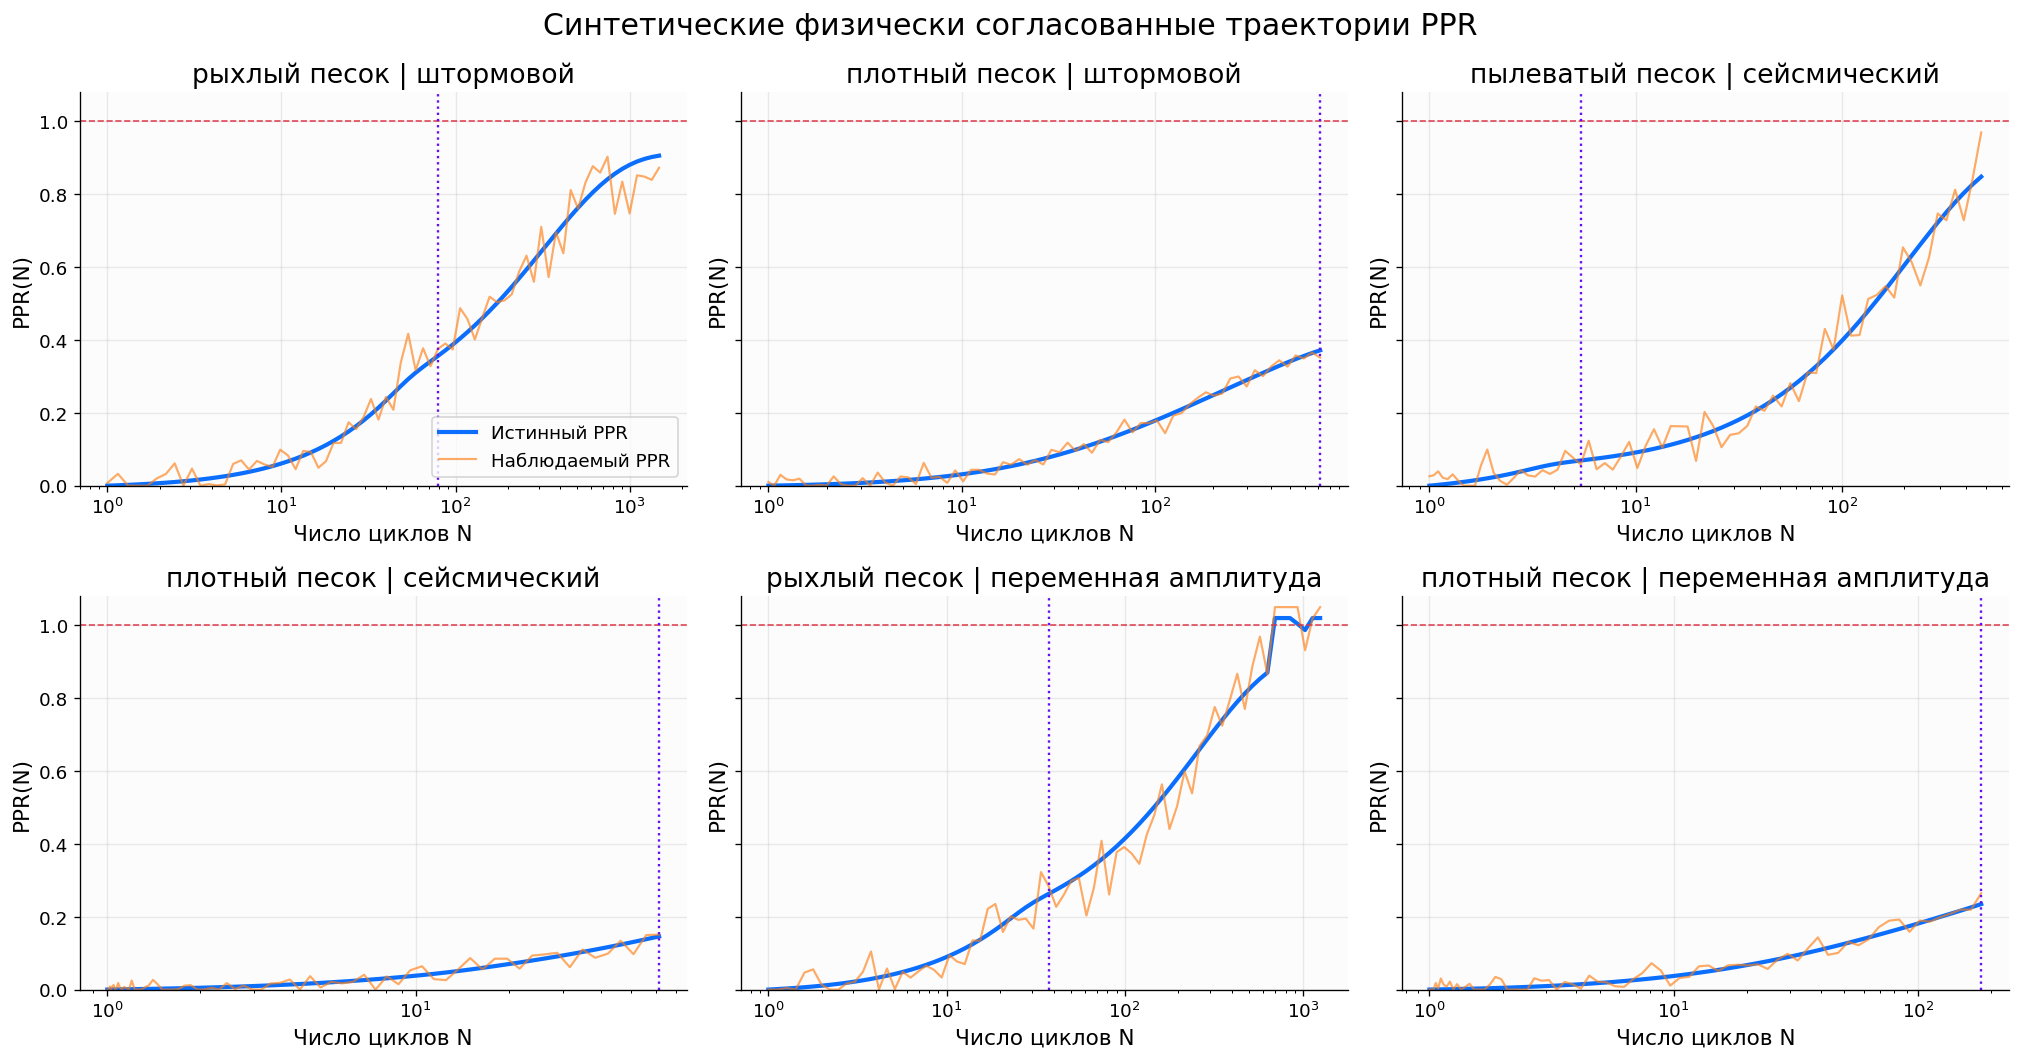

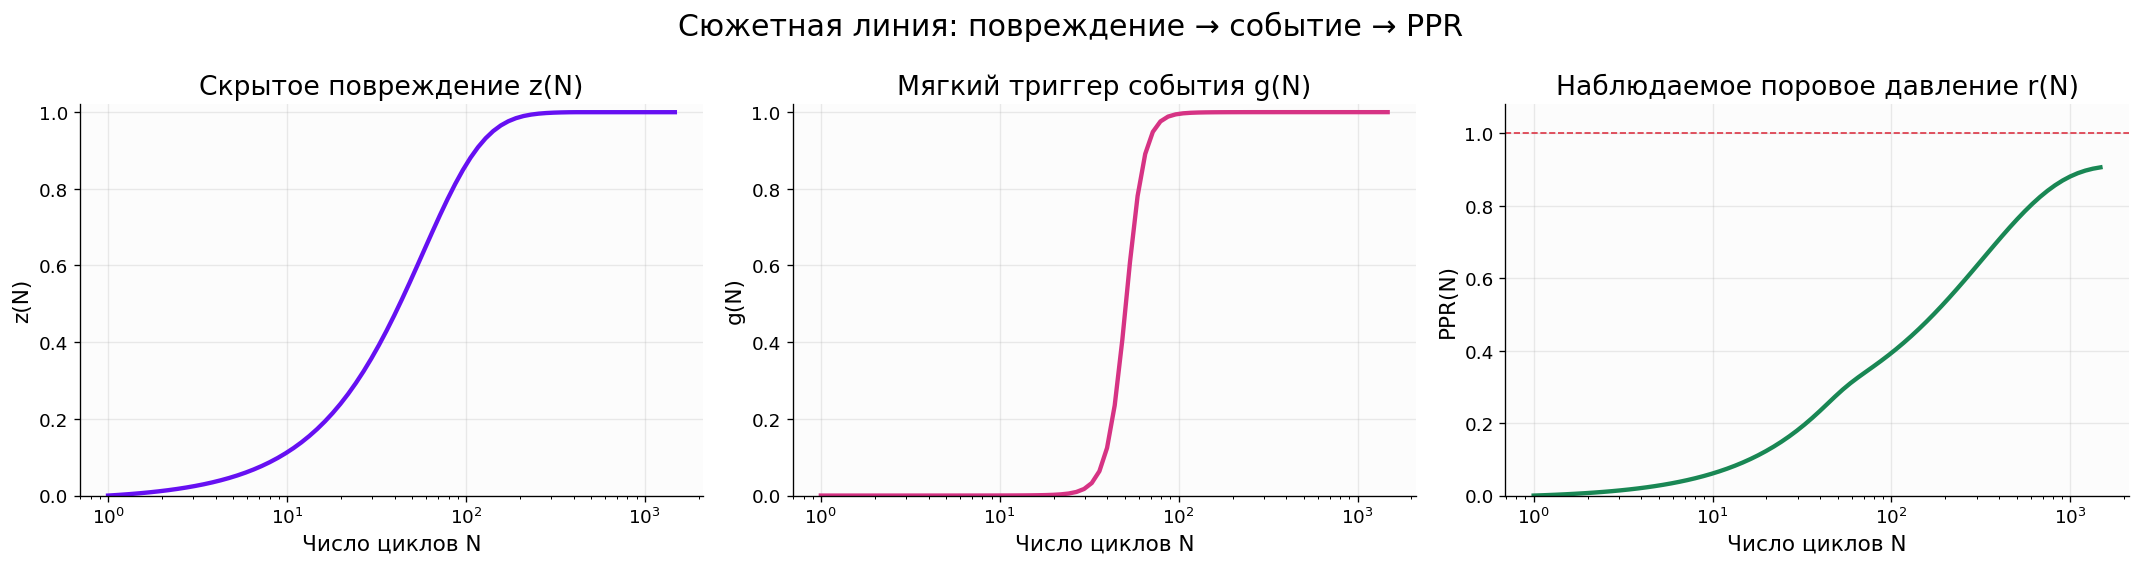

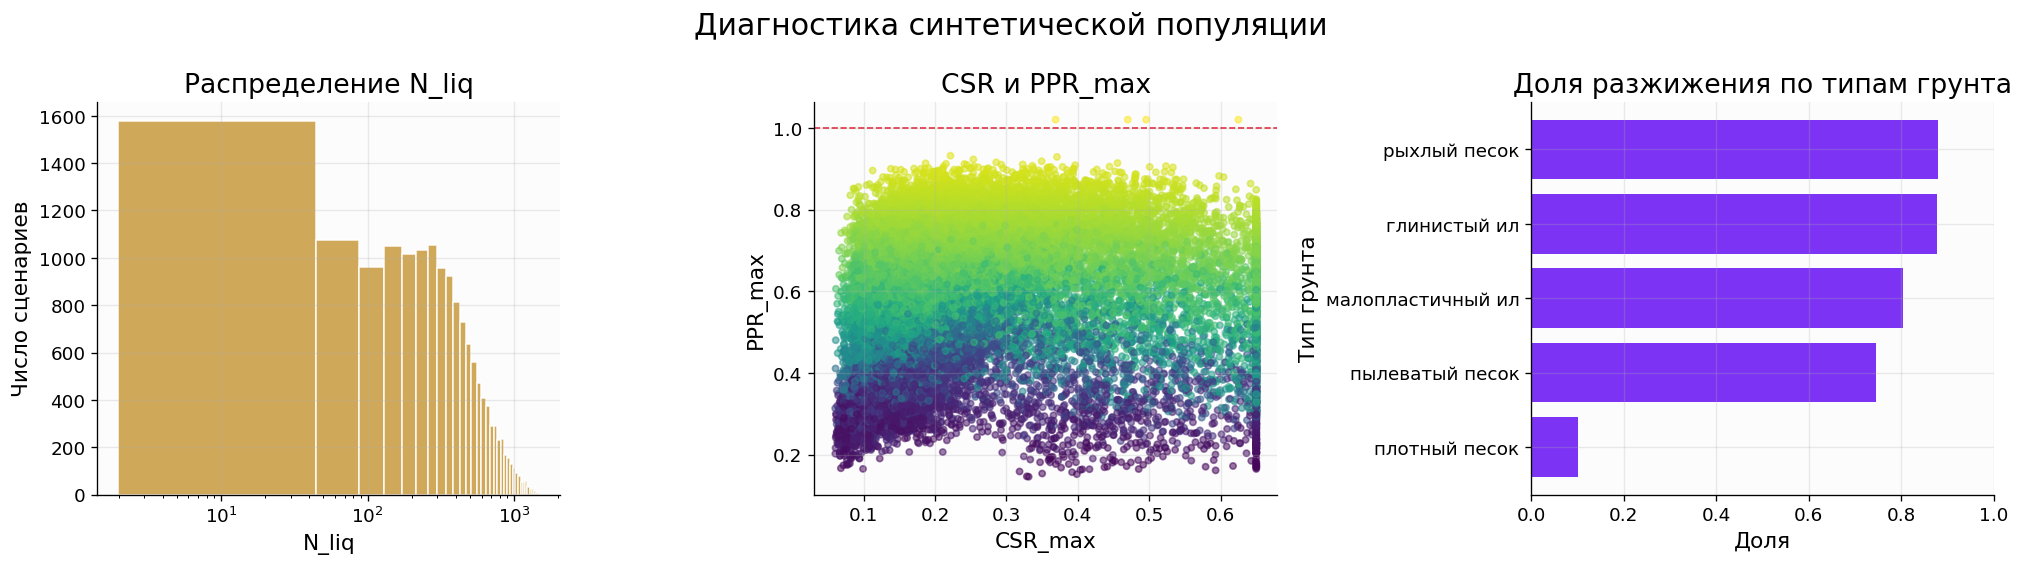

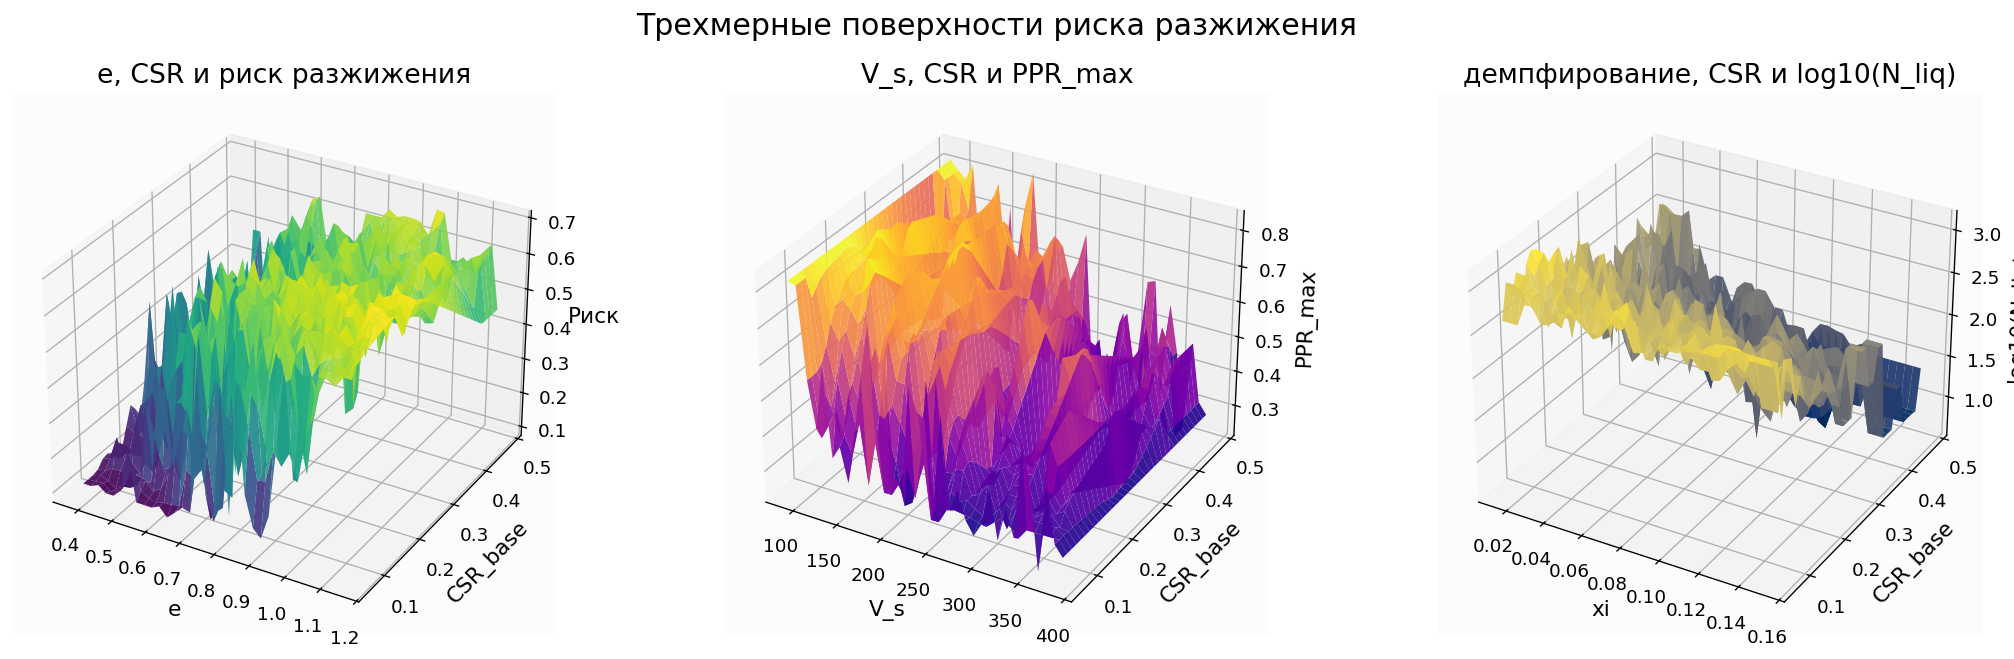

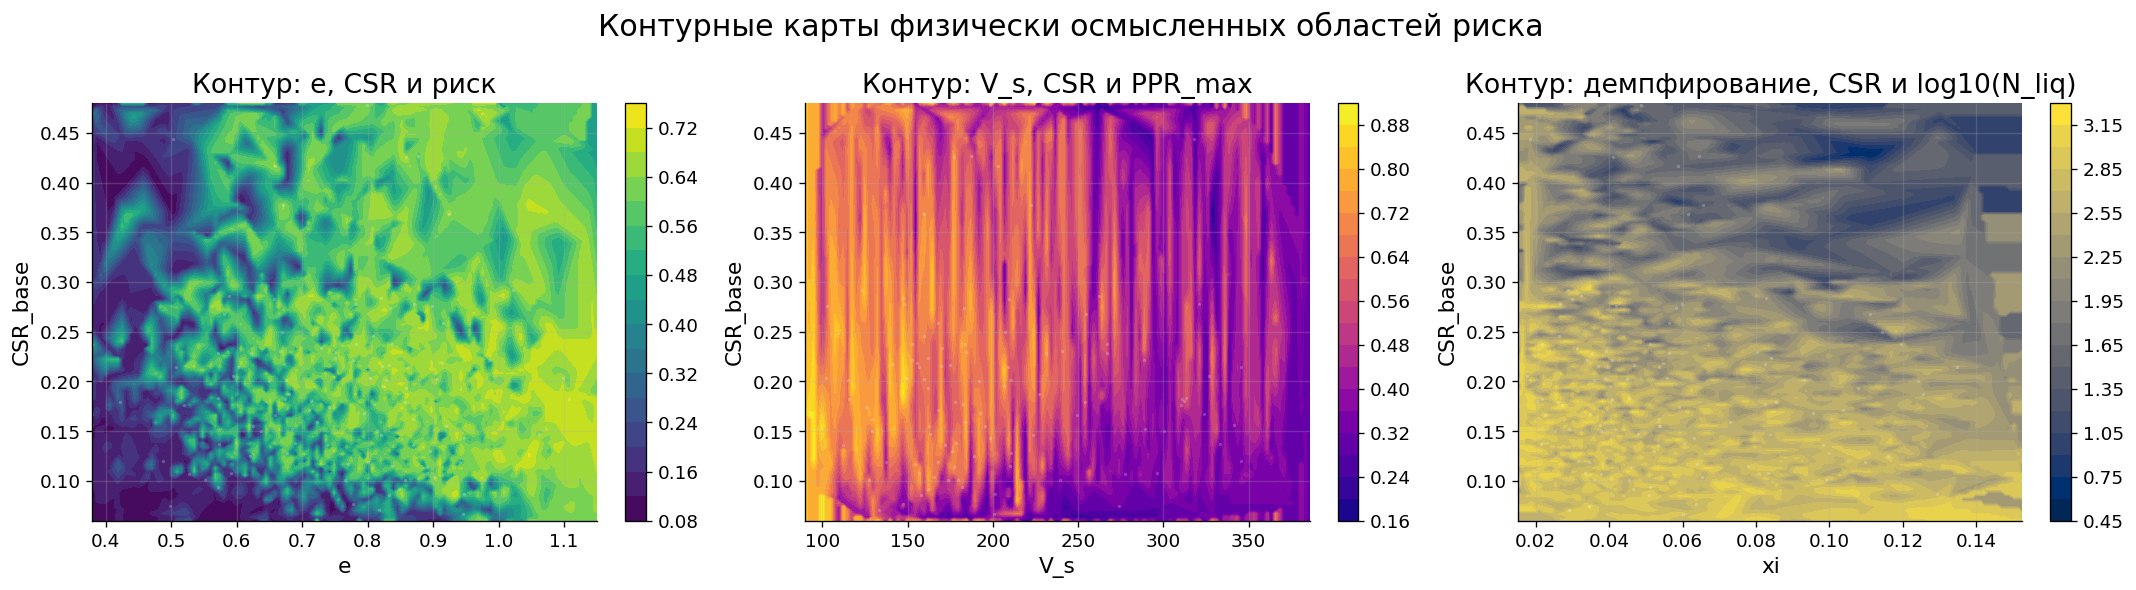

In [16]:
conference_figures: Dict[str, plt.Figure] = {}


def maybe_save_figure(fig: plt.Figure, name: str) -> None:
    if CONFIG.export_figures:
        from pathlib import Path

        target_dir = Path(CONFIG.figure_dir)
        target_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(target_dir / f"{name}.png", dpi=220)



def representative_case_indices(meta_df: pd.DataFrame) -> List[int]:
    picks: List[int] = []
    for mode_name in ["storm", "seismic", "variable_amplitude"]:
        mode_df = meta_df[meta_df["load_mode"] == mode_name]
        if len(mode_df) == 0:
            continue
        liq = mode_df[mode_df["liq_label"] == 1].sort_values("risk_score_true", ascending=False).head(1)
        stable = mode_df[mode_df["liq_label"] == 0].sort_values("risk_score_true", ascending=True).head(1)
        picks.extend(liq.index.tolist())
        picks.extend(stable.index.tolist())
    if len(picks) < 6:
        supplement = meta_df.sort_values("risk_score_true", ascending=False).head(6 - len(picks)).index.tolist()
        picks.extend(supplement)
    return picks[:6]



def setup_axis(ax: plt.Axes, title: str, xlabel: str, ylabel: str, logx: bool = False) -> None:
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if logx:
        ax.set_xscale("log")
    ax.grid(True, alpha=0.25)



def surface_plot(ax, x, y, z, title, xlabel, ylabel, zlabel, cmap="viridis"):
    x_grid = np.linspace(np.min(x), np.max(x), 35)
    y_grid = np.linspace(np.min(y), np.max(y), 35)
    xx, yy = np.meshgrid(x_grid, y_grid)
    zz = griddata((x, y), z, (xx, yy), method="linear")
    if np.isnan(zz).any():
        nearest = griddata((x, y), z, (xx, yy), method="nearest")
        zz = np.where(np.isnan(zz), nearest, zz)
    surf = ax.plot_surface(xx, yy, zz, cmap=cmap, linewidth=0.0, antialiased=True, alpha=0.92)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    return surf



def contour_plot(ax, x, y, z, title, xlabel, ylabel, cmap="viridis"):
    x_grid = np.linspace(np.min(x), np.max(x), 120)
    y_grid = np.linspace(np.min(y), np.max(y), 120)
    xx, yy = np.meshgrid(x_grid, y_grid)
    zz = griddata((x, y), z, (xx, yy), method="linear")
    if np.isnan(zz).any():
        nearest = griddata((x, y), z, (xx, yy), method="nearest")
        zz = np.where(np.isnan(zz), nearest, zz)
    contour = ax.contourf(xx, yy, zz, levels=18, cmap=cmap)
    ax.scatter(x[::30], y[::30], c="white", s=4, alpha=0.22, linewidths=0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return contour


rep_idx = representative_case_indices(meta)

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey=True)
for ax, idx in zip(axes.ravel(), rep_idx):
    ax.plot(population["cycles"][idx], population["r_true"][idx], color=PALETTE["primary"], lw=2.5, label="Истинный PPR")
    ax.plot(population["cycles"][idx], population["r_obs"][idx], color=PALETTE["warning"], lw=1.3, alpha=0.65, label="Наблюдаемый PPR")
    ax.axhline(1.0, color=PALETTE["danger"], ls="--", lw=1.0, alpha=0.9)
    ax.axvline(meta.loc[idx, "N_liq_true"], color=PALETTE["secondary"], ls=":", lw=1.4)
    setup_axis(
        ax,
        f"{SOIL_DISPLAY_NAMES.get(meta.loc[idx, 'soil_type'], meta.loc[idx, 'soil_type'])} | {LOAD_DISPLAY_NAMES.get(meta.loc[idx, 'load_mode'], meta.loc[idx, 'load_mode'])}",
        "Число циклов N",
        "PPR(N)",
        logx=True,
    )
    ax.set_ylim(0.0, 1.08)
axes[0, 0].legend(loc="lower right")
fig.suptitle("Синтетические физически согласованные траектории PPR", fontsize=18)
fig.tight_layout()
conference_figures["synthetic_physics_trajectories"] = fig
maybe_save_figure(fig, "synthetic_physics_trajectories")
plt.show()

story_idx = rep_idx[0]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
axes[0].plot(population["cycles"][story_idx], population["z_true"][story_idx], color=PALETTE["secondary"], lw=2.6)
setup_axis(axes[0], "Скрытое повреждение z(N)", "Число циклов N", "z(N)", logx=True)
axes[0].set_ylim(0.0, 1.02)

axes[1].plot(population["cycles"][story_idx], population["g_true"][story_idx], color=PALETTE["accent"], lw=2.6)
setup_axis(axes[1], "Мягкий триггер события g(N)", "Число циклов N", "g(N)", logx=True)
axes[1].set_ylim(0.0, 1.02)

axes[2].plot(population["cycles"][story_idx], population["r_true"][story_idx], color=PALETTE["success"], lw=2.6)
axes[2].axhline(1.0, color=PALETTE["danger"], ls="--", lw=1.0)
setup_axis(axes[2], "Наблюдаемое поровое давление r(N)", "Число циклов N", "PPR(N)", logx=True)
axes[2].set_ylim(0.0, 1.08)
fig.suptitle("Сюжетная линия: повреждение → событие → PPR", fontsize=18)
fig.tight_layout()
conference_figures["damage_event_ppr_storyline"] = fig
maybe_save_figure(fig, "damage_event_ppr_storyline")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
liq_cycles = meta.loc[meta["liq_label"] == 1, "N_liq_true"]
axes[0].hist(liq_cycles, bins=35, color=PALETTE["sand"], alpha=0.85, edgecolor="white")
axes[0].set_xscale("log")
setup_axis(axes[0], "Распределение N_liq", "N_liq", "Число сценариев", logx=True)

axes[1].scatter(meta["CSR_max"], meta["PPR_max_true"], c=meta["risk_score_true"], cmap="viridis", s=14, alpha=0.55)
setup_axis(axes[1], "CSR и PPR_max", "CSR_max", "PPR_max")
axes[1].axhline(1.0, color=PALETTE["danger"], ls="--", lw=1.0)

soil_rate = meta.groupby("soil_type")["liq_label"].mean().sort_values()
soil_rate.index = [SOIL_DISPLAY_NAMES.get(name, name) for name in soil_rate.index]
axes[2].barh(soil_rate.index, soil_rate.values, color=PALETTE["secondary"], alpha=0.85)
setup_axis(axes[2], "Доля разжижения по типам грунта", "Доля", "Тип грунта")
axes[2].set_xlim(0.0, 1.0)
fig.suptitle("Диагностика синтетической популяции", fontsize=18)
fig.tight_layout()
conference_figures["population_diagnostics"] = fig
maybe_save_figure(fig, "population_diagnostics")
plt.show()

surface_sample = meta.sample(min(3_000, len(meta)), random_state=CONFIG.seed)
fig = plt.figure(figsize=(18, 5.5))
ax1 = fig.add_subplot(131, projection="3d")
ax2 = fig.add_subplot(132, projection="3d")
ax3 = fig.add_subplot(133, projection="3d")

surface_plot(
    ax1,
    surface_sample["e"].to_numpy(),
    surface_sample["CSR_base"].to_numpy(),
    surface_sample["risk_score_true"].to_numpy(),
    "e, CSR и риск разжижения",
    "e",
    "CSR_base",
    "Риск",
)
surface_plot(
    ax2,
    surface_sample["V_s"].to_numpy(),
    surface_sample["CSR_base"].to_numpy(),
    surface_sample["PPR_max_true"].to_numpy(),
    "V_s, CSR и PPR_max",
    "V_s",
    "CSR_base",
    "PPR_max",
    cmap="plasma",
)
surface_plot(
    ax3,
    surface_sample["xi"].to_numpy(),
    surface_sample["CSR_base"].to_numpy(),
    np.log10(surface_sample["N_liq_true"].to_numpy() + 1.0),
    "демпфирование, CSR и log10(N_liq)",
    "xi",
    "CSR_base",
    "log10(N_liq)",
    cmap="cividis",
)
fig.suptitle("Трехмерные поверхности риска разжижения", fontsize=18)
fig.tight_layout()
conference_figures["three_d_risk_surfaces"] = fig
maybe_save_figure(fig, "three_d_risk_surfaces")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cont1 = contour_plot(
    axes[0],
    surface_sample["e"].to_numpy(),
    surface_sample["CSR_base"].to_numpy(),
    surface_sample["risk_score_true"].to_numpy(),
    "Контур: e, CSR и риск",
    "e",
    "CSR_base",
)
cont2 = contour_plot(
    axes[1],
    surface_sample["V_s"].to_numpy(),
    surface_sample["CSR_base"].to_numpy(),
    surface_sample["PPR_max_true"].to_numpy(),
    "Контур: V_s, CSR и PPR_max",
    "V_s",
    "CSR_base",
    cmap="plasma",
)
cont3 = contour_plot(
    axes[2],
    surface_sample["xi"].to_numpy(),
    surface_sample["CSR_base"].to_numpy(),
    np.log10(surface_sample["N_liq_true"].to_numpy() + 1.0),
    "Контур: демпфирование, CSR и log10(N_liq)",
    "xi",
    "CSR_base",
    cmap="cividis",
)
fig.colorbar(cont1, ax=axes[0], fraction=0.046)
fig.colorbar(cont2, ax=axes[1], fraction=0.046)
fig.colorbar(cont3, ax=axes[2], fraction=0.046)
fig.suptitle("Контурные карты физически осмысленных областей риска", fontsize=18)
fig.tight_layout()
conference_figures["contour_maps"] = fig
maybe_save_figure(fig, "contour_maps")
plt.show()

## Подготовка benchmark-данных и базовые модели

Базовые модели сделаны намеренно компактными, чтобы весь notebook оставался исполнимым на обычной машине.

### Входы, доступные всем моделям

- статические дескрипторы грунта и режима нагружения,
- каузальная последовательность нагрузки через `CSR(N)` и признаки цикл-сетки,
- короткий наблюдаемый префикс шумной траектории `PPR`,
- supervision для полной траектории `PPR`, момента события и риска разжижения.

### Базовые модели

- `MLP`: финальный риск и `N_liq` по статическим признакам и сводкам префикса,
- `GRU`: последовательностный baseline с вероятностной головой для траектории,
- `TCN`: каузальный временной сверточный baseline без физического слоя.

Следующая ячейка строит benchmark-тензоры, общие training-утилиты и сами baseline-модели.

In [17]:
def subset_array(arr, idx):
    if isinstance(arr, np.ndarray):
        return arr[idx]
    return arr



def prepare_benchmark_dataset(population_dict: Dict[str, object]) -> Dict[str, object]:
    benchmark_idx = population_dict["benchmark"]["benchmark_idx"]
    bench_meta = population_dict["meta"].iloc[benchmark_idx].reset_index(drop=True)

    static_raw = population_dict["static_features"][benchmark_idx]
    prefix_raw = population_dict["prefix_summary"][benchmark_idx]
    seq_raw = population_dict["seq_inputs"][benchmark_idx]
    cycles = population_dict["cycles"][benchmark_idx]
    delta_cycles = population_dict["delta_cycles"][benchmark_idx]
    csr = population_dict["csr"][benchmark_idx]
    r_obs = population_dict["r_obs"][benchmark_idx]
    r_true = population_dict["r_true"][benchmark_idx]
    z_true = population_dict["z_true"][benchmark_idx]
    g_true = population_dict["g_true"][benchmark_idx]
    valid_mask = population_dict["valid_mask"][benchmark_idx]
    prefix_mask = population_dict["prefix_mask"][benchmark_idx]
    prefix_obs = population_dict["prefix_obs"][benchmark_idx]
    liq_label = population_dict["liq_label"][benchmark_idx]
    risk_score_true = population_dict["risk_score_true"][benchmark_idx]
    n_liq_true = population_dict["n_liq_true"][benchmark_idx]
    uncertainty_proxy = population_dict["uncertainty_proxy"][benchmark_idx]
    crr_mix = population_dict["crr_mix"][benchmark_idx]
    crr_weights = population_dict["crr_weights"][benchmark_idx]

    train_rel = population_dict["benchmark"]["train_rel"]
    val_rel = population_dict["benchmark"]["val_rel"]
    test_rel = population_dict["benchmark"]["test_rel"]

    static_scaler = StandardScaler().fit(static_raw[train_rel])
    prefix_scaler = StandardScaler().fit(prefix_raw[train_rel])
    seq_train = seq_raw[train_rel].reshape(-1, seq_raw.shape[-1])
    seq_mean = seq_train.mean(axis=0)
    seq_std = seq_train.std(axis=0) + 1e-6

    static_scaled = static_scaler.transform(static_raw).astype(np.float32)
    prefix_scaled = prefix_scaler.transform(prefix_raw).astype(np.float32)
    seq_scaled = ((seq_raw - seq_mean[None, None, :]) / seq_std[None, None, :]).astype(np.float32)
    n_liq_norm = (np.log1p(n_liq_true) / np.log1p(CONFIG.max_cycle_reference)).astype(np.float32)
    trigger_zone = (g_true > 0.70).astype(np.float32)

    benchmark_arrays = {
        "static": static_scaled,
        "static_raw": static_raw.astype(np.float32),
        "prefix_summary": prefix_scaled,
        "prefix_summary_raw": prefix_raw.astype(np.float32),
        "seq_in": seq_scaled,
        "seq_in_raw": seq_raw.astype(np.float32),
        "cycles": cycles.astype(np.float32),
        "delta_cycles": delta_cycles.astype(np.float32),
        "csr": csr.astype(np.float32),
        "r_obs": r_obs.astype(np.float32),
        "r_true": r_true.astype(np.float32),
        "z_true": z_true.astype(np.float32),
        "g_true": g_true.astype(np.float32),
        "trigger_zone": trigger_zone,
        "mask": valid_mask.astype(np.float32),
        "prefix_mask": prefix_mask.astype(np.float32),
        "prefix_obs": prefix_obs.astype(np.float32),
        "label": liq_label.astype(np.float32),
        "risk_true": risk_score_true.astype(np.float32),
        "n_liq_true": n_liq_true.astype(np.float32),
        "n_liq_norm": n_liq_norm.astype(np.float32),
        "uncertainty_proxy": uncertainty_proxy.astype(np.float32),
        "crr_mix_true": crr_mix.astype(np.float32),
        "crr_weights_true": crr_weights.astype(np.float32),
    }

    def make_split(rel_idx: np.ndarray) -> Dict[str, object]:
        split = {key: torch.from_numpy(value[rel_idx]) for key, value in benchmark_arrays.items()}
        split["meta"] = bench_meta.iloc[rel_idx].reset_index(drop=True)
        split["indices"] = rel_idx
        return split

    return {
        "train": make_split(train_rel),
        "val": make_split(val_rel),
        "test": make_split(test_rel),
        "meta": bench_meta,
        "scalers": {
            "static": static_scaler,
            "prefix": prefix_scaler,
            "seq_mean": seq_mean.astype(np.float32),
            "seq_std": seq_std.astype(np.float32),
        },
        "feature_names": {
            "static": population_dict["static_feature_names"],
            "prefix": population_dict["prefix_summary_names"],
            "seq": population_dict["seq_feature_names"],
        },
    }


benchmark_data = prepare_benchmark_dataset(population)

for split_name in ["train", "val", "test"]:
    split = benchmark_data[split_name]
    split_name_ru = {"train": "обучение", "val": "валидация", "test": "тест"}[split_name]
    print(
        f"{split_name_ru}: static={tuple(split['static'].shape)}, seq={tuple(split['seq_in'].shape)}, "
        f"доля_разжижения={split['label'].float().mean().item():.3f}"
    )



def iterate_minibatches(split: Dict[str, object], batch_size: int, shuffle: bool = True, seed: int = 42):
    idx = np.arange(split["static"].shape[0])
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)
    tensor_keys = [key for key, value in split.items() if isinstance(value, torch.Tensor)]
    for start in range(0, len(idx), batch_size):
        batch_idx = idx[start : start + batch_size]
        batch = {key: split[key][batch_idx].to(device) for key in tensor_keys}
        batch["meta"] = split["meta"].iloc[batch_idx].reset_index(drop=True)
        yield batch



def masked_mean(values: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    return (values * mask).sum() / torch.clamp(mask.sum(), min=1.0)



def masked_mse(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    return masked_mean((pred - target) ** 2, mask)



def masked_mae(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    return masked_mean(torch.abs(pred - target), mask)



def gaussian_nll(mean: torch.Tensor, logvar: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    logvar = torch.clamp(logvar, min=-6.0, max=3.0)
    inv_var = torch.exp(-logvar)
    return masked_mean(0.5 * (logvar + (target - mean) ** 2 * inv_var), mask)



def clone_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}



def train_model(model: nn.Module, train_split: Dict[str, object], val_split: Dict[str, object], epochs: int, model_name: str) -> Tuple[nn.Module, pd.DataFrame]:
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG.learning_rate, weight_decay=CONFIG.weight_decay)
    best_state = clone_state_dict(model)
    best_val = float("inf")
    history: List[Dict[str, float]] = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch in iterate_minibatches(train_split, CONFIG.batch_size, shuffle=True, seed=CONFIG.seed + epoch):
            optimizer.zero_grad(set_to_none=True)
            loss_dict = model.compute_loss(batch)
            loss_dict["loss"].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(float(loss_dict["loss"].detach().cpu()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in iterate_minibatches(val_split, CONFIG.batch_size, shuffle=False):
                loss_dict = model.compute_loss(batch)
                val_losses.append(float(loss_dict["loss"].detach().cpu()))

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        if val_loss < best_val:
            best_val = val_loss
            best_state = clone_state_dict(model)
        print(f"[{model_name}] эпоха {epoch:02d} | обучение={train_loss:.4f} | валидация={val_loss:.4f}", flush=True)

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


class ResidualMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, depth: int = 3, dropout: float = 0.10):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    nn.GELU(),
                    nn.Dropout(dropout),
                )
                for _ in range(depth)
            ]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = F.gelu(self.input_layer(x))
        for block in self.blocks:
            h = h + block(h)
        return h


class RiskMLP(nn.Module):
    def __init__(self, static_dim: int, prefix_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.backbone = ResidualMLP(static_dim + prefix_dim, hidden_dim=hidden_dim, depth=3)
        self.risk_head = nn.Linear(hidden_dim, 1)
        self.nliq_head = nn.Linear(hidden_dim, 1)
        self.uncertainty_head = nn.Linear(hidden_dim, 1)

    def forward_batch(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        x = torch.cat([batch["static"], batch["prefix_summary"]], dim=-1)
        h = self.backbone(x)
        risk_logit = self.risk_head(h).squeeze(-1)
        nliq_pred = torch.sigmoid(self.nliq_head(h).squeeze(-1))
        uncertainty = F.softplus(self.uncertainty_head(h).squeeze(-1)) + 1e-3
        return {
            "risk_logit": risk_logit,
            "risk_prob": torch.sigmoid(risk_logit),
            "nliq_pred": nliq_pred,
            "uncertainty": uncertainty,
        }

    def compute_loss(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        outputs = self.forward_batch(batch)
        risk_loss = F.binary_cross_entropy_with_logits(outputs["risk_logit"], batch["label"])
        nliq_loss = F.smooth_l1_loss(outputs["nliq_pred"], batch["n_liq_norm"])
        calibration_loss = F.mse_loss(outputs["risk_prob"], batch["risk_true"])
        uncertainty_penalty = F.mse_loss(outputs["uncertainty"], batch["uncertainty_proxy"])
        loss = risk_loss + 0.45 * nliq_loss + 0.20 * calibration_loss + 0.05 * uncertainty_penalty
        outputs["loss"] = loss
        return outputs


class GRUBaseline(nn.Module):
    def __init__(self, static_dim: int, seq_dim: int, hidden_dim: int = 96):
        super().__init__()
        self.static_proj = nn.Sequential(nn.Linear(static_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, hidden_dim))
        self.gru = nn.GRU(input_size=seq_dim + hidden_dim, hidden_size=hidden_dim, batch_first=True, num_layers=2, dropout=0.10)
        self.mean_head = nn.Linear(hidden_dim, 1)
        self.logvar_head = nn.Linear(hidden_dim, 1)
        self.risk_head = nn.Linear(hidden_dim, 1)
        self.nliq_head = nn.Linear(hidden_dim, 1)

    def forward_batch(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        static_embed = self.static_proj(batch["static"]).unsqueeze(1).expand(-1, batch["seq_in"].shape[1], -1)
        x = torch.cat([batch["seq_in"], static_embed], dim=-1)
        h, _ = self.gru(x)
        mean = torch.sigmoid(self.mean_head(h).squeeze(-1))
        logvar = torch.clamp(self.logvar_head(h).squeeze(-1), min=-6.0, max=2.0)
        pooled = h[:, -1]
        risk_logit = self.risk_head(pooled).squeeze(-1)
        nliq_pred = torch.sigmoid(self.nliq_head(pooled).squeeze(-1))
        return {
            "traj_mean": mean,
            "traj_logvar": logvar,
            "risk_logit": risk_logit,
            "risk_prob": torch.sigmoid(risk_logit),
            "nliq_pred": nliq_pred,
        }

    def compute_loss(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        outputs = self.forward_batch(batch)
        traj_loss = gaussian_nll(outputs["traj_mean"], outputs["traj_logvar"], batch["r_obs"], batch["mask"])
        risk_loss = F.binary_cross_entropy_with_logits(outputs["risk_logit"], batch["label"])
        nliq_loss = F.smooth_l1_loss(outputs["nliq_pred"], batch["n_liq_norm"])
        smoothness = masked_mean(torch.abs(outputs["traj_mean"][:, 1:] - outputs["traj_mean"][:, :-1]), batch["mask"][:, 1:])
        loss = traj_loss + 0.35 * risk_loss + 0.25 * nliq_loss + 0.02 * smoothness
        outputs["loss"] = loss
        return outputs


class CausalTemporalBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, dilation: int, dropout: float = 0.10):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation)
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def chomp(self, x: torch.Tensor) -> torch.Tensor:
        return x[:, :, :-self.padding] if self.padding > 0 else x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.chomp(self.conv1(x))
        out = F.gelu(out)
        out = self.dropout(out)
        out = self.chomp(self.conv2(out))
        out = F.gelu(out)
        out = self.dropout(out)
        residual = self.downsample(x)
        if self.padding > 0:
            residual = residual[:, :, : out.shape[2]]
        return F.gelu(out + residual)


class TCNBaseline(nn.Module):
    def __init__(self, static_dim: int, seq_dim: int, hidden_dim: int = 96):
        super().__init__()
        self.static_proj = nn.Sequential(nn.Linear(static_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, hidden_dim))
        in_channels = seq_dim + hidden_dim
        self.blocks = nn.Sequential(
            CausalTemporalBlock(in_channels, hidden_dim, kernel_size=3, dilation=1),
            CausalTemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=2),
            CausalTemporalBlock(hidden_dim, hidden_dim, kernel_size=3, dilation=4),
        )
        self.mean_head = nn.Conv1d(hidden_dim, 1, kernel_size=1)
        self.logvar_head = nn.Conv1d(hidden_dim, 1, kernel_size=1)
        self.risk_head = nn.Linear(hidden_dim, 1)
        self.nliq_head = nn.Linear(hidden_dim, 1)

    def forward_batch(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        static_embed = self.static_proj(batch["static"]).unsqueeze(1).expand(-1, batch["seq_in"].shape[1], -1)
        x = torch.cat([batch["seq_in"], static_embed], dim=-1).transpose(1, 2)
        h = self.blocks(x)
        mean = torch.sigmoid(self.mean_head(h).squeeze(1))
        logvar = torch.clamp(self.logvar_head(h).squeeze(1), min=-6.0, max=2.0)
        pooled = h[:, :, -1]
        risk_logit = self.risk_head(pooled).squeeze(-1)
        nliq_pred = torch.sigmoid(self.nliq_head(pooled).squeeze(-1))
        return {
            "traj_mean": mean,
            "traj_logvar": logvar,
            "risk_logit": risk_logit,
            "risk_prob": torch.sigmoid(risk_logit),
            "nliq_pred": nliq_pred,
        }

    def compute_loss(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        outputs = self.forward_batch(batch)
        traj_loss = gaussian_nll(outputs["traj_mean"], outputs["traj_logvar"], batch["r_obs"], batch["mask"])
        risk_loss = F.binary_cross_entropy_with_logits(outputs["risk_logit"], batch["label"])
        nliq_loss = F.smooth_l1_loss(outputs["nliq_pred"], batch["n_liq_norm"])
        smoothness = masked_mean(torch.abs(outputs["traj_mean"][:, 1:] - outputs["traj_mean"][:, :-1]), batch["mask"][:, 1:])
        loss = traj_loss + 0.35 * risk_loss + 0.25 * nliq_loss + 0.02 * smoothness
        outputs["loss"] = loss
        return outputs

обучение: static=(5600, 22), seq=(5600, 72, 5), доля_разжижения=0.654
валидация: static=(1199, 22), seq=(1199, 72, 5), доля_разжижения=0.652
тест: static=(1201, 22), seq=(1201, 72, 5), доля_разжижения=0.656


[MLP_risk] эпоха 01 | обучение=0.2966 | валидация=0.1813
[MLP_risk] эпоха 02 | обучение=0.1466 | валидация=0.1440
[MLP_risk] эпоха 03 | обучение=0.1179 | валидация=0.1322
[MLP_risk] эпоха 04 | обучение=0.1026 | валидация=0.1270
[GRU] эпоха 01 | обучение=-1.1045 | валидация=-1.7858
[GRU] эпоха 02 | обучение=-2.3486 | валидация=-2.6828
[GRU] эпоха 03 | обучение=-2.6716 | валидация=-2.7380
[GRU] эпоха 04 | обучение=-2.7454 | валидация=-2.7833
[TCN] эпоха 01 | обучение=-1.1156 | валидация=-2.2868
[TCN] эпоха 02 | обучение=-2.5151 | валидация=-2.6629
[TCN] эпоха 03 | обучение=-2.6861 | валидация=-2.7264
[TCN] эпоха 04 | обучение=-2.7105 | валидация=-2.6914


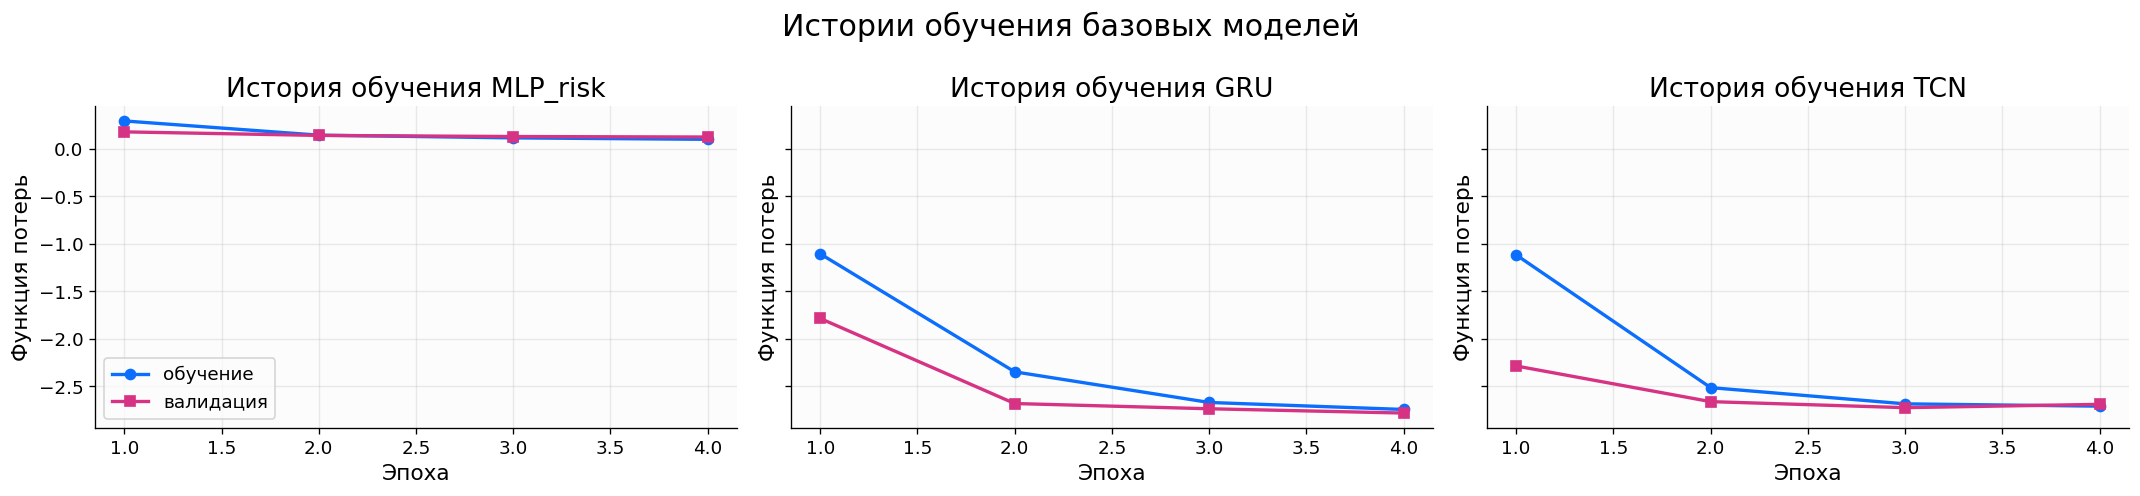

In [18]:
baseline_models: Dict[str, nn.Module] = {}
baseline_histories: Dict[str, pd.DataFrame] = {}

static_dim = benchmark_data["train"]["static"].shape[1]
prefix_dim = benchmark_data["train"]["prefix_summary"].shape[1]
seq_dim = benchmark_data["train"]["seq_in"].shape[-1]

risk_mlp = RiskMLP(static_dim=static_dim, prefix_dim=prefix_dim, hidden_dim=128).to(device)
risk_mlp, baseline_histories["MLP_risk"] = train_model(
    risk_mlp,
    benchmark_data["train"],
    benchmark_data["val"],
    epochs=CONFIG.baseline_epochs,
    model_name="MLP_risk",
)
baseline_models["MLP_risk"] = risk_mlp

gru_baseline = GRUBaseline(static_dim=static_dim, seq_dim=seq_dim, hidden_dim=96).to(device)
gru_baseline, baseline_histories["GRU"] = train_model(
    gru_baseline,
    benchmark_data["train"],
    benchmark_data["val"],
    epochs=CONFIG.baseline_epochs,
    model_name="GRU",
)
baseline_models["GRU"] = gru_baseline

tcn_baseline = TCNBaseline(static_dim=static_dim, seq_dim=seq_dim, hidden_dim=96).to(device)
tcn_baseline, baseline_histories["TCN"] = train_model(
    tcn_baseline,
    benchmark_data["train"],
    benchmark_data["val"],
    epochs=CONFIG.baseline_epochs,
    model_name="TCN",
)
baseline_models["TCN"] = tcn_baseline

fig, axes = plt.subplots(1, 3, figsize=(18, 4.2), sharey=True)
for ax, (name, hist) in zip(axes, baseline_histories.items()):
    ax.plot(hist["epoch"], hist["train_loss"], marker="o", lw=2.0, color=PALETTE["primary"], label="обучение")
    ax.plot(hist["epoch"], hist["val_loss"], marker="s", lw=2.0, color=PALETTE["accent"], label="валидация")
    ax.set_title(f"История обучения {name}")
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Функция потерь")
    ax.grid(True, alpha=0.25)
axes[0].legend()
fig.suptitle("Истории обучения базовых моделей", fontsize=18)
fig.tight_layout()
conference_figures["baseline_histories"] = fig
maybe_save_figure(fig, "baseline_histories")
plt.show()

## DPI-Flow

`DPI-Flow` реализован как вероятностная физически-структурированная архитектура.

### Ключевая идея

Сеть **не** выдает `PPR(N)` напрямую как black-box последовательность. Вместо этого она:

1. кодирует дескрипторы грунта, параметры режима нагружения и короткий префикс `PPR`,
2. предсказывает распределение по физическим `ODE`-параметрам,
3. преобразует это латентное распределение через легкий `flow-like` аффинный трансформ,
4. пропускает полученные параметры через аналитический `ODE`-слой,
5. при необходимости уточняет параметры через дифференцируемый внутренний шаг калибровки по префиксу.

Именно такой workflow дифференцируемого вывода параметров и был предложен в `AI.docx`, а здесь он привязан к `ODE`-переформулировкам моделей из приложенных статей по разжижению и росту порового давления.

In [19]:
class ConditionalAffineFlow(nn.Module):
    def __init__(self, latent_dim: int, context_dim: int):
        super().__init__()
        self.scale_1 = nn.Linear(context_dim, latent_dim)
        self.shift_1 = nn.Linear(context_dim, latent_dim)
        self.scale_2 = nn.Linear(context_dim, latent_dim)
        self.shift_2 = nn.Linear(context_dim, latent_dim)

    def forward(self, z: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        s1 = 0.35 * torch.tanh(self.scale_1(context))
        h = z * torch.exp(s1) + self.shift_1(context)
        s2 = 0.35 * torch.tanh(self.scale_2(context))
        h = h * torch.exp(s2) + self.shift_2(context)
        return h


class AnalyticalLiquefactionLayer(nn.Module):
    def __init__(self, seq_len: int):
        super().__init__()
        self.seq_len = seq_len

    def unpack_theta(self, theta: torch.Tensor) -> Dict[str, torch.Tensor]:
        weights = torch.softmax(theta[:, 0:4], dim=-1)
        amp = 0.03 + 0.28 * torch.sigmoid(theta[:, 4:8])
        rate = 0.05 + 1.20 * torch.sigmoid(theta[:, 8:12])
        tail = 0.005 + 0.18 * torch.sigmoid(theta[:, 12:16])
        lambda_damage = 0.0001 + 0.0050 * torch.sigmoid(theta[:, 16])
        exponent_m = 1.0 + 2.5 * torch.sigmoid(theta[:, 17])
        exponent_nu = 1.0 + 1.8 * torch.sigmoid(theta[:, 18])
        alpha = 0.0004 + 0.0060 * torch.sigmoid(theta[:, 19])
        beta = 0.01 + 0.18 * torch.sigmoid(theta[:, 20])
        gamma = 0.00005 + 0.0020 * torch.sigmoid(theta[:, 21])
        exponent_p = 0.95 + 1.9 * torch.sigmoid(theta[:, 22])
        tau = 3.0 + 42.0 * torch.sigmoid(theta[:, 23])
        alpha_post = 0.0004 + 0.0080 * torch.sigmoid(theta[:, 24])
        beta_post = 0.01 + 0.16 * torch.sigmoid(theta[:, 25])
        gamma_post = 0.00005 + 0.0024 * torch.sigmoid(theta[:, 26])
        exponent_p_post = 0.85 + 1.4 * torch.sigmoid(theta[:, 27])
        kappa = 6.0 + 20.0 * torch.sigmoid(theta[:, 28])
        z0 = 0.35 + 0.50 * torch.sigmoid(theta[:, 29])
        noise = 0.01 + 0.08 * torch.sigmoid(theta[:, 30])
        return {
            "weights": weights,
            "amp": amp,
            "rate": rate,
            "tail": tail,
            "lambda_damage": lambda_damage,
            "m": exponent_m,
            "nu": exponent_nu,
            "alpha": alpha,
            "beta": beta,
            "gamma": gamma,
            "p": exponent_p,
            "tau": tau,
            "alpha_post": alpha_post,
            "beta_post": beta_post,
            "gamma_post": gamma_post,
            "p_post": exponent_p_post,
            "kappa": kappa,
            "z0": z0,
            "noise": noise,
        }

    def compute_crr(self, params: Dict[str, torch.Tensor], cycles: torch.Tensor) -> torch.Tensor:
        n_rel = cycles / 100.0
        crr_h = params["tail"][:, 0:1] + params["amp"][:, 0:1] / (1.0 + params["rate"][:, 0:1] * n_rel)
        crr_p = params["tail"][:, 1:2] + params["amp"][:, 1:2] * torch.pow(1.0 + n_rel, -(0.15 + params["rate"][:, 1:2]))
        crr_e = params["tail"][:, 2:3] + params["amp"][:, 2:3] * torch.exp(-params["rate"][:, 2:3] * n_rel)
        crr_l = params["tail"][:, 3:4] + params["amp"][:, 3:4] / (1.0 + params["rate"][:, 3:4] * torch.log1p(4.0 * n_rel))
        crr = (
            params["weights"][:, 0:1] * crr_h
            + params["weights"][:, 1:2] * crr_p
            + params["weights"][:, 2:3] * crr_e
            + params["weights"][:, 3:4] * crr_l
        )
        return torch.clamp(crr, min=1e-4)

    def soft_first_hitting(self, r: torch.Tensor, g: torch.Tensor, cycles: torch.Tensor) -> torch.Tensor:
        event_prob = torch.maximum(torch.sigmoid(12.0 * (r - 0.985)), g)
        shifted_survival = torch.cumprod(
            torch.cat([torch.ones_like(event_prob[:, :1]), torch.clamp(1.0 - event_prob[:, :-1], min=1e-4)], dim=1),
            dim=1,
        )
        event_mass = event_prob * shifted_survival
        residual_mass = torch.clamp(1.0 - event_mass.sum(dim=1), min=0.0, max=1.0)
        nliq = (event_mass * cycles).sum(dim=1) + residual_mass * cycles[:, -1]
        return nliq

    def simulate(self, theta: torch.Tensor, cycles: torch.Tensor, delta_cycles: torch.Tensor, csr: torch.Tensor) -> Dict[str, torch.Tensor]:
        params = self.unpack_theta(theta)
        crr = self.compute_crr(params, cycles)
        batch_size, seq_len = cycles.shape
        eps = 1e-6

        z_states = [torch.zeros(batch_size, device=cycles.device)]
        r_states = [torch.zeros(batch_size, device=cycles.device)]
        g_states = []

        for step in range(seq_len):
            z_curr = z_states[-1]
            r_curr = r_states[-1]
            g_curr = torch.sigmoid(params["kappa"] * (z_curr - params["z0"]))
            g_states.append(g_curr)
            if step == seq_len - 1:
                break

            ratio = csr[:, step] / (crr[:, step] + eps)
            phi = F.softplus(6.0 * (ratio - 0.90)) / 6.0
            dz = params["lambda_damage"] * torch.pow(torch.clamp(ratio, min=eps), params["m"]) * torch.pow(torch.clamp(1.0 - z_curr, min=eps), params["nu"])
            pre_event = (
                params["alpha"] * phi * torch.pow(torch.clamp(1.0 - r_curr, min=eps), params["p"])
                + params["beta"] / (cycles[:, step] + params["tau"])
                - params["gamma"] * r_curr
            )
            post_event = (
                params["alpha_post"] * torch.pow(torch.clamp(1.0 - r_curr, min=eps), params["p_post"])
                + params["beta_post"] / (cycles[:, step] + 0.70 * params["tau"])
                - params["gamma_post"] * r_curr
            )
            dr = (1.0 - g_curr) * pre_event + g_curr * post_event

            z_next = torch.clamp(z_curr + delta_cycles[:, step + 1] * dz, min=0.0, max=0.999)
            r_next = torch.clamp(r_curr + delta_cycles[:, step + 1] * dr, min=0.0, max=1.02)
            z_states.append(z_next)
            r_states.append(r_next)

        z = torch.stack(z_states, dim=1)
        r = torch.stack(r_states, dim=1)
        g = torch.stack(g_states, dim=1)
        nliq = self.soft_first_hitting(r, g, cycles)
        logvar = 2.0 * torch.log(params["noise"].unsqueeze(1).expand_as(r))
        return {
            "traj_mean": r,
            "traj_logvar": logvar,
            "z": z,
            "g": g,
            "crr": crr,
            "nliq": nliq,
            "nliq_norm": torch.log1p(nliq) / math.log1p(CONFIG.max_cycle_reference),
            "theta_params": params,
        }


class DPIFlow(nn.Module):
    def __init__(
        self,
        static_dim: int,
        prefix_dim: int,
        seq_len: int,
        theta_dim: int = 31,
        hidden_dim: int = 160,
        probabilistic: bool = True,
        calibration_steps: int = 2,
        calibration_lr: float = 0.10,
        use_analytical_layer: bool = True,
    ):
        super().__init__()
        self.theta_dim = theta_dim
        self.seq_len = seq_len
        self.probabilistic = probabilistic
        self.calibration_steps = calibration_steps
        self.calibration_lr = calibration_lr
        self.use_analytical_layer = use_analytical_layer
        self.prefix_len = CONFIG.prefix_len

        context_dim = static_dim + prefix_dim + 2 * self.prefix_len
        self.context_encoder = ResidualMLP(context_dim, hidden_dim=hidden_dim, depth=3, dropout=0.10)
        self.mu_head = nn.Linear(hidden_dim, theta_dim)
        self.logvar_head = nn.Linear(hidden_dim, theta_dim)
        self.flow = ConditionalAffineFlow(theta_dim, hidden_dim)
        self.ode_layer = AnalyticalLiquefactionLayer(seq_len=seq_len)

        self.direct_decoder = ResidualMLP(context_dim, hidden_dim=hidden_dim, depth=3, dropout=0.10)
        self.direct_traj_head = nn.Linear(hidden_dim, seq_len)
        self.direct_logvar_head = nn.Linear(hidden_dim, seq_len)
        self.direct_risk_head = nn.Linear(hidden_dim, 1)
        self.direct_nliq_head = nn.Linear(hidden_dim, 1)

    def build_context(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        prefix_values = batch["prefix_obs"][:, : self.prefix_len]
        prefix_mask = batch["prefix_mask"][:, : self.prefix_len]
        return torch.cat([batch["static"], batch["prefix_summary"], prefix_values, prefix_mask], dim=-1)

    def sample_theta(self, encoded_context: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu = self.mu_head(encoded_context)
        raw_logvar = torch.clamp(self.logvar_head(encoded_context), min=-5.0, max=3.0)
        if self.probabilistic:
            eps = torch.randn_like(mu) if self.training else torch.zeros_like(mu)
            latent = mu + torch.exp(0.5 * raw_logvar) * eps
        else:
            latent = mu
            raw_logvar = torch.zeros_like(mu)
        theta = self.flow(latent, encoded_context)
        return theta, mu, raw_logvar

    def calibrate_theta(self, theta: torch.Tensor, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        if self.calibration_steps <= 0 or not self.use_analytical_layer:
            return theta

        theta_anchor = theta
        theta_work = theta.detach().clone()
        for _ in range(self.calibration_steps):
            theta_work = theta_work.detach().requires_grad_(True)
            with torch.enable_grad():
                sim = self.ode_layer.simulate(theta_work, batch["cycles"], batch["delta_cycles"], batch["csr"])
                prefix_loss = masked_mse(sim["traj_mean"], batch["prefix_obs"], batch["prefix_mask"])
            grad = torch.autograd.grad(prefix_loss, theta_work, create_graph=False, retain_graph=False)[0]
            theta_work = theta_work - self.calibration_lr * grad

        return theta_anchor + (theta_work.detach() - theta_anchor.detach())

    def forward_batch(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        context = self.build_context(batch)
        encoded = self.context_encoder(context)
        theta, mu, raw_logvar = self.sample_theta(encoded)
        theta = self.calibrate_theta(theta, batch)

        if self.use_analytical_layer:
            outputs = self.ode_layer.simulate(theta, batch["cycles"], batch["delta_cycles"], batch["csr"])
            risk_logit = 6.0 * (
                0.50 * outputs["traj_mean"].amax(dim=1)
                + 0.25 * outputs["g"].amax(dim=1)
                + 0.25 * outputs["z"].amax(dim=1)
                - 0.75
            )
            outputs.update(
                {
                    "risk_logit": risk_logit,
                    "risk_prob": torch.sigmoid(risk_logit),
                    "kl": 0.5 * (torch.exp(raw_logvar) + mu.pow(2) - 1.0 - raw_logvar).mean(dim=1),
                    "theta_raw": theta,
                    "mu": mu,
                    "raw_logvar": raw_logvar,
                }
            )
            return outputs

        decoded = self.direct_decoder(context)
        traj_mean = torch.sigmoid(self.direct_traj_head(decoded))
        traj_logvar = torch.clamp(self.direct_logvar_head(decoded), min=-6.0, max=2.0)
        risk_logit = self.direct_risk_head(decoded).squeeze(-1)
        nliq_norm = torch.sigmoid(self.direct_nliq_head(decoded).squeeze(-1))
        return {
            "traj_mean": traj_mean,
            "traj_logvar": traj_logvar,
            "risk_logit": risk_logit,
            "risk_prob": torch.sigmoid(risk_logit),
            "nliq_norm": nliq_norm,
            "nliq": torch.expm1(nliq_norm * math.log1p(CONFIG.max_cycle_reference)),
            "g": torch.sigmoid(traj_mean * 8.0 - 4.0),
            "z": torch.sigmoid(traj_mean * 6.0 - 2.5),
            "crr": torch.ones_like(traj_mean) * 0.20,
            "kl": 0.5 * (torch.exp(raw_logvar) + mu.pow(2) - 1.0 - raw_logvar).mean(dim=1),
            "theta_raw": theta,
            "mu": mu,
            "raw_logvar": raw_logvar,
        }

    def compute_loss(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        outputs = self.forward_batch(batch)
        traj_loss = gaussian_nll(outputs["traj_mean"], outputs["traj_logvar"], batch["r_obs"], batch["mask"])
        nliq_loss = F.smooth_l1_loss(outputs["nliq_norm"], batch["n_liq_norm"])
        risk_loss = F.binary_cross_entropy_with_logits(outputs["risk_logit"], batch["label"])
        monotonicity = torch.relu(outputs["crr"][:, 1:] - outputs["crr"][:, :-1]).mean()
        boundedness = (torch.relu(outputs["traj_mean"] - 1.02) + torch.relu(-outputs["traj_mean"])).mean()
        smoothness = torch.abs(outputs["traj_mean"][:, 2:] - 2.0 * outputs["traj_mean"][:, 1:-1] + outputs["traj_mean"][:, :-2]).mean()
        kl_loss = outputs["kl"].mean() if self.probabilistic else torch.zeros(1, device=outputs["traj_mean"].device).squeeze()
        loss = traj_loss + 0.35 * risk_loss + 0.25 * nliq_loss + 0.03 * monotonicity + 0.03 * boundedness + 0.01 * smoothness + 0.02 * kl_loss
        outputs["loss"] = loss
        return outputs

[DPI-Flow] эпоха 01 | обучение=-2.4394 | валидация=-2.6669
[DPI-Flow] эпоха 02 | обучение=-2.6947 | валидация=-2.7288
[DPI-Flow] эпоха 03 | обучение=-2.7258 | валидация=-2.7218
[DPI-Flow] эпоха 04 | обучение=-2.7321 | валидация=-2.7448
[DPI-Flow] эпоха 05 | обучение=-2.7435 | валидация=-2.7448


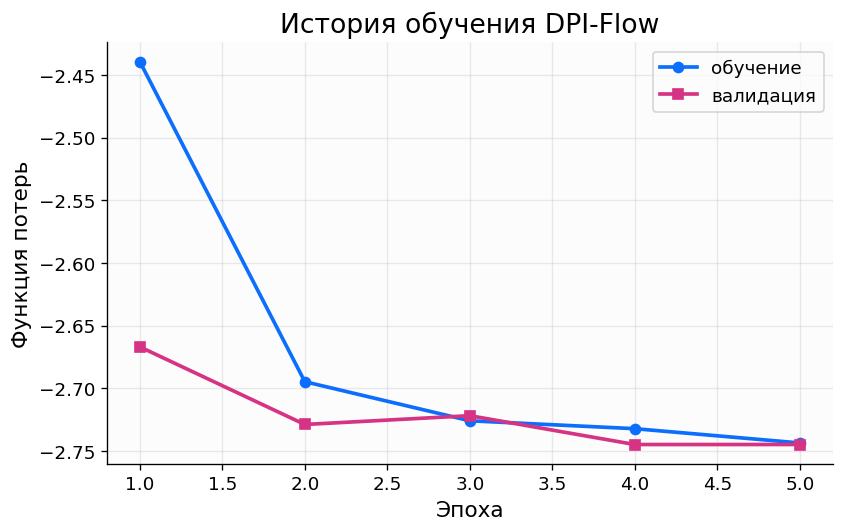

In [20]:
dpi_models: Dict[str, DPIFlow] = {}
dpi_histories: Dict[str, pd.DataFrame] = {}

dpi_flow = DPIFlow(
    static_dim=static_dim,
    prefix_dim=prefix_dim,
    seq_len=CONFIG.seq_len,
    theta_dim=31,
    hidden_dim=160,
    probabilistic=True,
    calibration_steps=2,
    calibration_lr=0.10,
    use_analytical_layer=True,
).to(device)

dpi_flow, dpi_histories["DPI-Flow"] = train_model(
    dpi_flow,
    benchmark_data["train"],
    benchmark_data["val"],
    epochs=CONFIG.physics_epochs,
    model_name="DPI-Flow",
)
dpi_models["DPI-Flow"] = dpi_flow

fig, ax = plt.subplots(figsize=(7.2, 4.6))
hist = dpi_histories["DPI-Flow"]
ax.plot(hist["epoch"], hist["train_loss"], marker="o", color=PALETTE["primary"], lw=2.2, label="обучение")
ax.plot(hist["epoch"], hist["val_loss"], marker="s", color=PALETTE["accent"], lw=2.2, label="валидация")
ax.set_title("История обучения DPI-Flow")
ax.set_xlabel("Эпоха")
ax.set_ylabel("Функция потерь")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
conference_figures["dpi_flow_history"] = fig
maybe_save_figure(fig, "dpi_flow_history")
plt.show()

## EVT-NeuralSSM

`EVT-NeuralSSM` реализован как событийно-активируемая нейронная модель пространства состояний.

### Скрытое состояние

Модель эволюционирует структурированное скрытое состояние

- `h_t = [z_t, r_t, c_t]`

где:

- `z_t` — скрытое состояние повреждения / склонности к разжижению,
- `r_t` — коэффициент порового давления,
- `c_t` — компактная вспомогательная структурная память.

### Событийно-зависимое переключение

Предсобытийная и постсобытийная динамики смешиваются через

- `g_t = sigmoid(kappa * (z_t - z0))`

Это дает дифференцируемый механизм переключения вместо хрупкого порога. Обновление состояния остается каузальным и физически-доминантным: логика `CRR/CSR` управляет `z_t`, а рост и диссипация `PPR` управляют `r_t`. Небольшая нейронная поправка действует только через вспомогательное состояние `c_t`.

In [21]:
class EVTNeuralSSM(nn.Module):
    def __init__(
        self,
        static_dim: int,
        prefix_dim: int,
        seq_dim: int,
        seq_len: int,
        hidden_dim: int = 144,
        use_trigger_head: bool = True,
        structured_post_event: bool = True,
        use_crr_damage: bool = True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.use_trigger_head = use_trigger_head
        self.structured_post_event = structured_post_event
        self.use_crr_damage = use_crr_damage
        self.prefix_len = CONFIG.prefix_len

        context_dim = static_dim + prefix_dim + 2 * self.prefix_len
        self.context_encoder = ResidualMLP(context_dim, hidden_dim=hidden_dim, depth=3, dropout=0.10)
        self.param_head = nn.Linear(hidden_dim, 33)
        self.correction_net = nn.Sequential(
            nn.Linear(hidden_dim + seq_dim + 4, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 3),
        )

    def build_context(self, batch: Dict[str, torch.Tensor]) -> torch.Tensor:
        return torch.cat(
            [
                batch["static"],
                batch["prefix_summary"],
                batch["prefix_obs"][:, : self.prefix_len],
                batch["prefix_mask"][:, : self.prefix_len],
            ],
            dim=-1,
        )

    def unpack_params(self, theta: torch.Tensor) -> Dict[str, torch.Tensor]:
        weights = torch.softmax(theta[:, 0:4], dim=-1)
        amp = 0.03 + 0.28 * torch.sigmoid(theta[:, 4:8])
        rate = 0.05 + 1.15 * torch.sigmoid(theta[:, 8:12])
        tail = 0.005 + 0.18 * torch.sigmoid(theta[:, 12:16])
        lambda_pre = 0.0001 + 0.0050 * torch.sigmoid(theta[:, 16])
        exponent_m = 1.0 + 2.4 * torch.sigmoid(theta[:, 17])
        exponent_nu = 1.0 + 1.8 * torch.sigmoid(theta[:, 18])
        alpha_pre = 0.0004 + 0.0065 * torch.sigmoid(theta[:, 19])
        beta_pre = 0.01 + 0.18 * torch.sigmoid(theta[:, 20])
        gamma_pre = 0.00005 + 0.0020 * torch.sigmoid(theta[:, 21])
        exponent_p_pre = 0.95 + 1.8 * torch.sigmoid(theta[:, 22])
        tau_pre = 3.0 + 42.0 * torch.sigmoid(theta[:, 23])
        lambda_post = 0.0002 + 0.0075 * torch.sigmoid(theta[:, 24])
        alpha_post = 0.0004 + 0.0080 * torch.sigmoid(theta[:, 25])
        beta_post = 0.01 + 0.16 * torch.sigmoid(theta[:, 26])
        gamma_post = 0.00005 + 0.0024 * torch.sigmoid(theta[:, 27])
        exponent_p_post = 0.80 + 1.6 * torch.sigmoid(theta[:, 28])
        kappa = 6.0 + 20.0 * torch.sigmoid(theta[:, 29])
        z0 = 0.35 + 0.50 * torch.sigmoid(theta[:, 30])
        c_decay = 0.50 + 0.45 * torch.sigmoid(theta[:, 31])
        noise = 0.01 + 0.08 * torch.sigmoid(theta[:, 32])
        return {
            "weights": weights,
            "amp": amp,
            "rate": rate,
            "tail": tail,
            "lambda_pre": lambda_pre,
            "m": exponent_m,
            "nu": exponent_nu,
            "alpha_pre": alpha_pre,
            "beta_pre": beta_pre,
            "gamma_pre": gamma_pre,
            "p_pre": exponent_p_pre,
            "tau_pre": tau_pre,
            "lambda_post": lambda_post,
            "alpha_post": alpha_post,
            "beta_post": beta_post,
            "gamma_post": gamma_post,
            "p_post": exponent_p_post,
            "kappa": kappa,
            "z0": z0,
            "c_decay": c_decay,
            "noise": noise,
        }

    def compute_crr(self, params: Dict[str, torch.Tensor], cycles: torch.Tensor) -> torch.Tensor:
        n_rel = cycles / 100.0
        crr_h = params["tail"][:, 0:1] + params["amp"][:, 0:1] / (1.0 + params["rate"][:, 0:1] * n_rel)
        crr_p = params["tail"][:, 1:2] + params["amp"][:, 1:2] * torch.pow(1.0 + n_rel, -(0.15 + params["rate"][:, 1:2]))
        crr_e = params["tail"][:, 2:3] + params["amp"][:, 2:3] * torch.exp(-params["rate"][:, 2:3] * n_rel)
        crr_l = params["tail"][:, 3:4] + params["amp"][:, 3:4] / (1.0 + params["rate"][:, 3:4] * torch.log1p(4.0 * n_rel))
        crr = (
            params["weights"][:, 0:1] * crr_h
            + params["weights"][:, 1:2] * crr_p
            + params["weights"][:, 2:3] * crr_e
            + params["weights"][:, 3:4] * crr_l
        )
        return torch.clamp(crr, min=1e-4)

    def soft_first_hitting(self, r: torch.Tensor, g: torch.Tensor, cycles: torch.Tensor) -> torch.Tensor:
        event_prob = torch.maximum(torch.sigmoid(12.0 * (r - 0.985)), g)
        shifted_survival = torch.cumprod(
            torch.cat([torch.ones_like(event_prob[:, :1]), torch.clamp(1.0 - event_prob[:, :-1], min=1e-4)], dim=1),
            dim=1,
        )
        event_mass = event_prob * shifted_survival
        residual_mass = torch.clamp(1.0 - event_mass.sum(dim=1), min=0.0, max=1.0)
        return (event_mass * cycles).sum(dim=1) + residual_mass * cycles[:, -1]

    def forward_batch(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        context = self.build_context(batch)
        encoded = self.context_encoder(context)
        params = self.unpack_params(self.param_head(encoded))
        crr = self.compute_crr(params, batch["cycles"])

        batch_size, seq_len = batch["cycles"].shape
        eps = 1e-6
        z_states = [torch.zeros(batch_size, device=batch["cycles"].device)]
        r_states = [batch["prefix_obs"][:, 0]]
        c_states = [torch.zeros(batch_size, device=batch["cycles"].device)]
        g_states = []

        for step in range(seq_len):
            z_curr = z_states[-1]
            r_curr = r_states[-1]
            c_curr = c_states[-1]
            g_step = torch.sigmoid(params["kappa"] * (z_curr - params["z0"])) if self.use_trigger_head else torch.zeros_like(z_curr)
            g_states.append(g_step)
            if step == seq_len - 1:
                break

            ratio = batch["csr"][:, step] / (crr[:, step] + eps)
            phi = F.softplus(6.0 * (ratio - 0.90)) / 6.0

            correction_input = torch.cat(
                [
                    encoded,
                    batch["seq_in"][:, step, :],
                    z_curr[:, None],
                    r_curr[:, None],
                    c_curr[:, None],
                    g_step[:, None],
                ],
                dim=-1,
            )
            correction = 0.05 * torch.tanh(self.correction_net(correction_input))
            dz_corr, dr_corr, dc_corr = correction.unbind(dim=-1)

            if self.use_crr_damage:
                dz_pre = params["lambda_pre"] * torch.pow(torch.clamp(ratio, min=eps), params["m"]) * torch.pow(torch.clamp(1.0 - z_curr, min=eps), params["nu"]) + dz_corr
            else:
                dz_pre = 0.10 * torch.tanh(dz_corr) + 0.02 * phi

            dr_pre = (
                params["alpha_pre"] * phi * torch.pow(torch.clamp(1.0 - r_curr, min=eps), params["p_pre"])
                + params["beta_pre"] / (batch["cycles"][:, step] + params["tau_pre"])
                - params["gamma_pre"] * r_curr
                + dr_corr
            )

            if self.structured_post_event:
                dz_post = params["lambda_post"] * torch.clamp(1.0 - z_curr, min=eps) + 0.5 * dz_corr
                dr_post = (
                    params["alpha_post"] * torch.pow(torch.clamp(1.0 - r_curr, min=eps), params["p_post"])
                    + params["beta_post"] / (batch["cycles"][:, step] + 0.70 * params["tau_pre"])
                    - params["gamma_post"] * r_curr
                    + 0.5 * dr_corr
                )
            else:
                dz_post = dz_pre
                dr_post = dr_pre

            dz = (1.0 - g_step) * dz_pre + g_step * dz_post
            dr = (1.0 - g_step) * dr_pre + g_step * dr_post
            z_next = torch.clamp(z_curr + batch["delta_cycles"][:, step + 1] * dz, min=0.0, max=0.999)
            r_next = torch.clamp(r_curr + batch["delta_cycles"][:, step + 1] * dr, min=0.0, max=1.02)
            c_next = torch.tanh(params["c_decay"] * c_curr + dc_corr)
            z_states.append(z_next)
            r_states.append(r_next)
            c_states.append(c_next)

        z = torch.stack(z_states, dim=1)
        r = torch.stack(r_states, dim=1)
        c = torch.stack(c_states, dim=1)
        g = torch.stack(g_states, dim=1)
        nliq = self.soft_first_hitting(r, g, batch["cycles"])
        nliq_norm = torch.log1p(nliq) / math.log1p(CONFIG.max_cycle_reference)
        risk_logit = 6.0 * (0.50 * r.amax(dim=1) + 0.25 * g.amax(dim=1) + 0.25 * z.amax(dim=1) - 0.75)
        traj_logvar = 2.0 * torch.log(params["noise"].unsqueeze(1).expand_as(r))
        return {
            "traj_mean": r,
            "traj_logvar": traj_logvar,
            "risk_logit": risk_logit,
            "risk_prob": torch.sigmoid(risk_logit),
            "nliq": nliq,
            "nliq_norm": nliq_norm,
            "z": z,
            "g": g,
            "c": c,
            "crr": crr,
        }

    def compute_loss(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        outputs = self.forward_batch(batch)
        traj_loss = gaussian_nll(outputs["traj_mean"], outputs["traj_logvar"], batch["r_obs"], batch["mask"])
        trigger_loss = F.binary_cross_entropy(outputs["g"], batch["trigger_zone"])
        risk_loss = F.binary_cross_entropy_with_logits(outputs["risk_logit"], batch["label"])
        nliq_loss = F.smooth_l1_loss(outputs["nliq_norm"], batch["n_liq_norm"])
        switch_reg = torch.abs(outputs["g"][:, 1:] - outputs["g"][:, :-1]).mean()
        state_smoothness = (
            torch.abs(outputs["traj_mean"][:, 2:] - 2.0 * outputs["traj_mean"][:, 1:-1] + outputs["traj_mean"][:, :-2]).mean()
            + torch.abs(outputs["z"][:, 2:] - 2.0 * outputs["z"][:, 1:-1] + outputs["z"][:, :-2]).mean()
        )
        boundedness = (torch.relu(outputs["traj_mean"] - 1.02) + torch.relu(-outputs["traj_mean"]) + torch.relu(outputs["z"] - 1.0) + torch.relu(-outputs["z"])).mean()
        loss = traj_loss + 0.30 * trigger_loss + 0.30 * risk_loss + 0.25 * nliq_loss + 0.02 * switch_reg + 0.01 * state_smoothness + 0.03 * boundedness
        outputs["loss"] = loss
        return outputs

[EVT-NeuralSSM] эпоха 01 | обучение=0.0322 | валидация=-0.8521
[EVT-NeuralSSM] эпоха 02 | обучение=-1.1350 | валидация=-1.3893
[EVT-NeuralSSM] эпоха 03 | обучение=-1.4181 | валидация=-1.3783
[EVT-NeuralSSM] эпоха 04 | обучение=-1.4293 | валидация=-0.9612
[EVT-NeuralSSM] эпоха 05 | обучение=-1.3114 | валидация=-1.2245


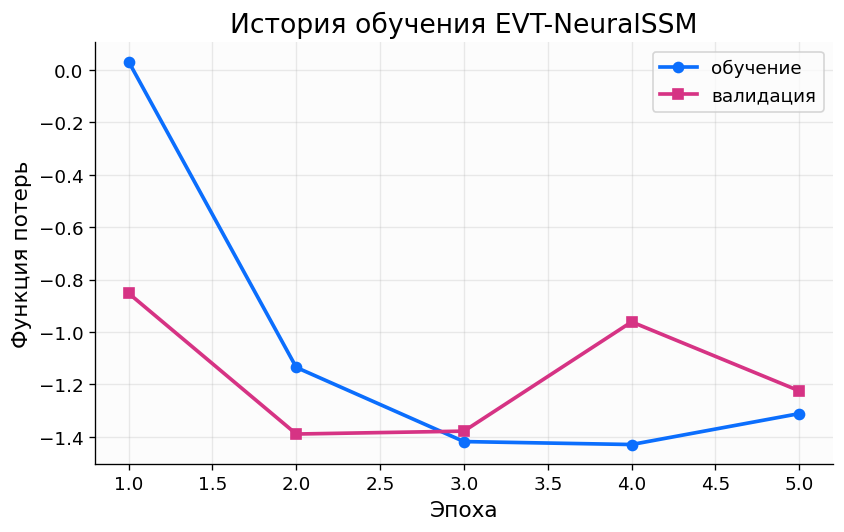

In [22]:
evt_models: Dict[str, EVTNeuralSSM] = {}
evt_histories: Dict[str, pd.DataFrame] = {}

evt_neural_ssm = EVTNeuralSSM(
    static_dim=static_dim,
    prefix_dim=prefix_dim,
    seq_dim=seq_dim,
    seq_len=CONFIG.seq_len,
    hidden_dim=144,
    use_trigger_head=True,
    structured_post_event=True,
    use_crr_damage=True,
).to(device)

evt_neural_ssm, evt_histories["EVT-NeuralSSM"] = train_model(
    evt_neural_ssm,
    benchmark_data["train"],
    benchmark_data["val"],
    epochs=CONFIG.physics_epochs,
    model_name="EVT-NeuralSSM",
)
evt_models["EVT-NeuralSSM"] = evt_neural_ssm

fig, ax = plt.subplots(figsize=(7.2, 4.6))
hist = evt_histories["EVT-NeuralSSM"]
ax.plot(hist["epoch"], hist["train_loss"], marker="o", color=PALETTE["primary"], lw=2.2, label="обучение")
ax.plot(hist["epoch"], hist["val_loss"], marker="s", color=PALETTE["accent"], lw=2.2, label="валидация")
ax.set_title("История обучения EVT-NeuralSSM")
ax.set_xlabel("Эпоха")
ax.set_ylabel("Функция потерь")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
conference_figures["evt_history"] = fig
maybe_save_figure(fig, "evt_history")
plt.show()

## Метрики, абляции и out-of-distribution тесты

Блок оценки теперь сравнивает black-box baseline-модели со структурированными архитектурами.

### Отчитываемые метрики

- траекторные `MSE`, `MAE`, `RMSE`,
- абсолютная ошибка `N_liq`,
- `AUROC`, `AUPRC`, `Brier`,
- покрытие неопределенности и средняя ширина интервала,
- качество калибровки,
- качество по типам грунта и по режимам нагружения.

### Абляции, требуемые планом

1. `DPI-Flow` без неявной калибровки.
2. `DPI-Flow` без вероятностной головы.
3. `DPI-Flow` без аналитического `ODE`-слоя.
4. `EVT-NeuralSSM` без trigger-head.
5. `EVT-NeuralSSM` без структурированной постсобытийной динамики.
6. `EVT-NeuralSSM` без `CRR`-основанного уравнения скрытого повреждения.
7. Сравнение baseline `TCN` со структурированными моделями.
8. Обучение на коротком горизонте и тест на более длинном горизонте в пределах `1500` циклов.
9. Тесты на удержанном регионе грунтов и на невидимом режиме нагружения.

,модель,MAE по N_liq,AUROC,AUPRC,Brier,ECE,MSE траектории,MAE траектории,RMSE траектории,покрытие_90,ширина_интервала_90
3,DPI-Flow,90.7080,0.9985,0.9992,0.0834,0.2273,0.0001,0.0061,0.0104,0.9312,0.0369
1,GRU,274.3971,0.9963,0.9981,0.0267,0.0392,0.0004,0.0109,0.0188,0.9980,0.1804
2,TCN,333.9554,0.9943,0.9970,0.0307,0.0301,0.0006,0.0154,0.0249,0.9962,0.1762
4,EVT-NeuralSSM,377.1299,0.8913,0.9347,0.1307,0.1148,0.0106,0.0648,0.1029,0.8736,0.2951
0,MLP риск,102.1224,0.9961,0.9980,0.0240,0.0125,NaN,NaN,NaN,NaN,NaN


Метрики по типам грунта для DPI-Flow


,тип_грунта,число_образцов,доля_разжижения,средний_предсказанный_риск,средняя_абс_ошибка_N_liq,средний_RMSE_траектории,средняя_ширина_интервала,AUROC
2,плотный песок,293,0.1024,0.1159,24.682800,0.0076,0.0362,0.9968
4,рыхлый песок,279,0.8674,0.5978,112.327103,0.0078,0.0370,0.9979
0,глинистый ил,219,0.8767,0.6033,84.510300,0.0098,0.0385,0.9986
1,малопластичный ил,209,0.8182,0.5669,126.635002,0.0083,0.0365,0.9932
3,пылеватый песок,201,0.7612,0.5316,126.340797,0.0080,0.0366,0.9985


Метрики по режимам нагружения для DPI-Flow


,режим_нагружения,число_образцов,доля_разжижения,средний_предсказанный_риск,средняя_абс_ошибка_N_liq,средний_RMSE_траектории,средняя_ширина_интервала,AUROC
4,штормовой,317,0.7287,0.5281,131.924103,0.0072,0.0374,0.9994
0,переменная амплитуда,262,0.7290,0.5330,98.262604,0.0088,0.0366,0.9997
2,стационарно-циклический,225,0.6311,0.4422,107.622902,0.0097,0.0366,0.9998
1,сейсмический,214,0.7103,0.4494,28.946501,0.0073,0.0364,0.9961
3,техногенный,183,0.3934,0.3033,59.922600,0.0086,0.0375,0.9970


...

,модель,MAE по N_liq,AUROC,AUPRC,Brier,ECE,MSE траектории,MAE траектории,RMSE траектории,покрытие_90,ширина_интервала_90
0,DPI-Flow без калибровки,84.9452,0.9942,0.9969,0.0937,0.2175,0.0002,0.0081,0.0155,0.8531,0.0337
1,DPI-Flow без вероятностной головы,273.9271,0.9888,0.9941,0.1138,0.2371,0.0003,0.0091,0.0183,0.8347,0.0330
2,DPI-Flow без ODE-слоя,190.5869,0.9659,0.9814,0.0800,0.0715,0.0016,0.0233,0.0399,0.9921,0.1992
3,EVT-NeuralSSM без trigger-head,255.4069,0.7395,0.7756,0.2742,0.2988,0.0066,0.0547,0.0814,0.9279,0.2948
4,EVT-NeuralSSM без постсобытийной динамики,223.8706,0.9279,0.9572,0.2715,0.3444,0.0207,0.0874,0.1440,0.8014,0.2951
5,EVT-NeuralSSM без CRR-уравнения повреждения,198.0111,0.9156,0.9316,0.4587,0.5149,0.0217,0.0884,0.1472,0.8013,0.2952


[TCN: короткий->длинный] эпоха 01 | обучение=-0.6663 | валидация=-2.0945
[TCN: короткий->длинный] эпоха 02 | обучение=-2.2921 | валидация=-2.5542
[DPI-Flow: короткий->длинный] эпоха 01 | обучение=-2.4805 | валидация=-2.6747
[DPI-Flow: короткий->длинный] эпоха 02 | обучение=-2.6928 | валидация=-2.7055
[EVT-NeuralSSM: короткий->длинный] эпоха 01 | обучение=-0.7992 | валидация=-1.4796
[EVT-NeuralSSM: короткий->длинный] эпоха 02 | обучение=-1.6633 | валидация=-1.8246


,модель,MAE по N_liq,AUROC,AUPRC,Brier,ECE,MSE траектории,MAE траектории,RMSE траектории,покрытие_90,ширина_интервала_90
1,DPI-Flow: короткий→длинный,256.4055,0.9939,0.9982,0.0856,0.2313,0.0008,0.0130,0.0277,0.8234,0.0357
0,TCN: короткий→длинный,622.9830,0.9927,0.9977,0.0433,0.0690,0.0041,0.0354,0.0644,0.9700,0.2231
2,EVT-NeuralSSM: короткий→длинный,381.6526,0.9307,0.9521,0.0749,0.1690,0.0107,0.0639,0.1033,0.8882,0.2950


[TCN: удержанный набор] эпоха 01 | обучение=-0.7941 | валидация=-2.2756
[TCN: удержанный набор] эпоха 02 | обучение=-2.3767 | валидация=-2.5671
[DPI-Flow: удержанный набор] эпоха 01 | обучение=-2.4328 | валидация=-2.6552
[DPI-Flow: удержанный набор] эпоха 02 | обучение=-2.7062 | валидация=-2.7395
[EVT-NeuralSSM: удержанный набор] эпоха 01 | обучение=-0.3929 | валидация=-0.6602
[EVT-NeuralSSM: удержанный набор] эпоха 02 | обучение=-0.8239 | валидация=-0.7303


,модель,MAE по N_liq,AUROC,AUPRC,Brier,ECE,MSE траектории,MAE траектории,RMSE траектории,покрытие_90,ширина_интервала_90
2,DPI-Flow: удержанный набор | удержанный_регион,88.7887,0.9875,0.9989,0.1178,0.3152,0.0004,0.0111,0.0208,0.8134,0.0356
3,DPI-Flow: удержанный набор | невидимый_режим,63.9134,0.9958,0.9985,0.1118,0.2641,0.0004,0.0110,0.0206,0.8369,0.0360
4,EVT-NeuralSSM: удержанный набор | удержанный_р...,170.4316,0.7167,0.9689,0.6972,0.7933,0.0307,0.1047,0.1753,0.7656,0.2952
5,EVT-NeuralSSM: удержанный набор | невидимый_режим,274.4412,0.7569,0.8322,0.5536,0.6159,0.0236,0.0902,0.1538,0.8063,0.2951
0,TCN: удержанный набор | удержанный_регион,174.1506,0.9763,0.9981,0.0365,0.0728,0.0027,0.0296,0.0518,0.9859,0.2364
1,TCN: удержанный набор | невидимый_режим,305.5778,0.9823,0.9936,0.0566,0.0736,0.0055,0.0497,0.0740,0.9551,0.2917


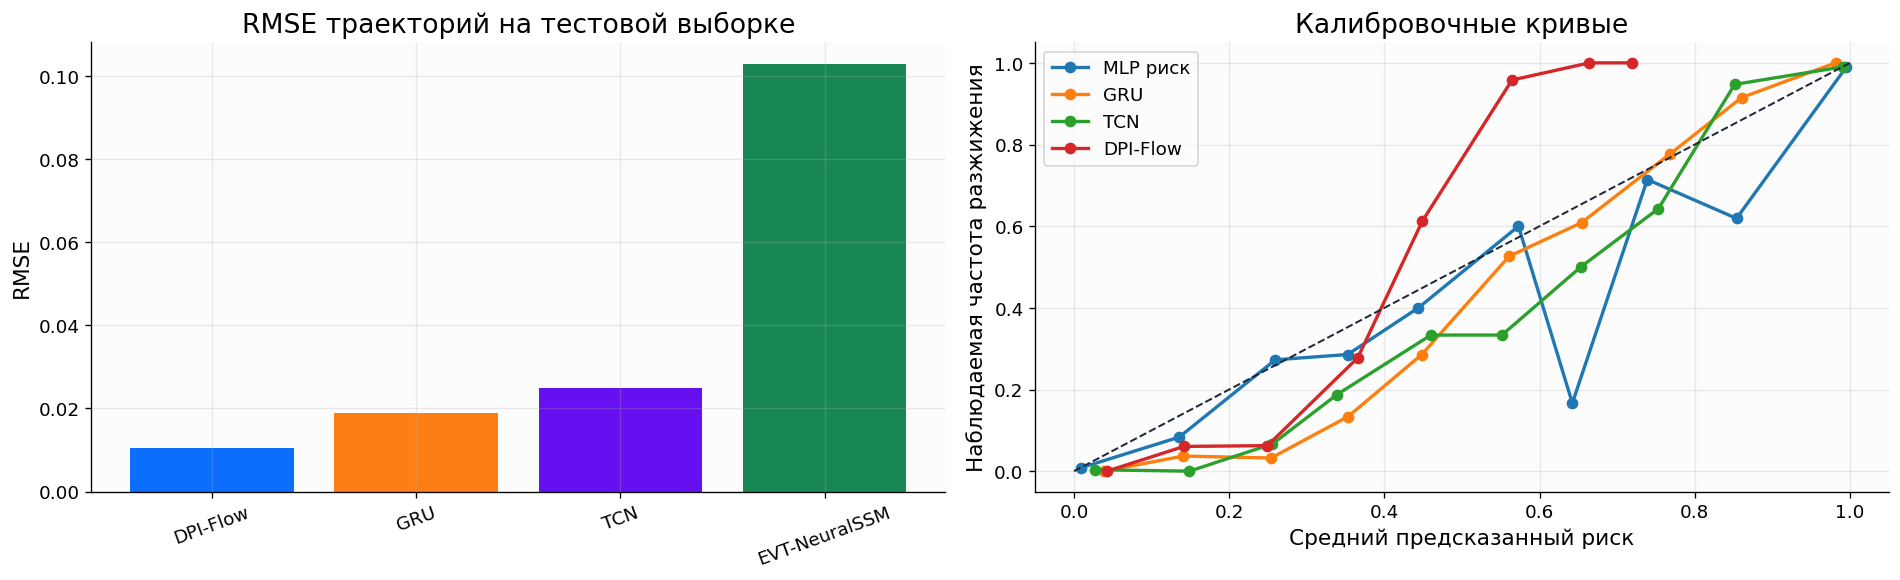

In [23]:
def collect_outputs(model: nn.Module, split: Dict[str, object]) -> Dict[str, np.ndarray]:
    model.eval()
    collected: Dict[str, List[torch.Tensor]] = {}
    with torch.no_grad():
        for batch in iterate_minibatches(split, CONFIG.batch_size, shuffle=False):
            outputs = model.forward_batch(batch)
            for key, value in outputs.items():
                if torch.is_tensor(value):
                    collected.setdefault(key, []).append(value.detach().cpu())
    return {key: torch.cat(value, dim=0).numpy() for key, value in collected.items()}



def resolve_nliq_prediction(outputs: Dict[str, np.ndarray]) -> np.ndarray:
    if "nliq" in outputs:
        return outputs["nliq"]
    if "nliq_pred" in outputs:
        return np.expm1(outputs["nliq_pred"] * math.log1p(CONFIG.max_cycle_reference))
    if "nliq_norm" in outputs:
        return np.expm1(outputs["nliq_norm"] * math.log1p(CONFIG.max_cycle_reference))
    raise KeyError("В outputs не найдено предсказание для N_liq.")



def expected_calibration_error(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi if hi < 1.0 else y_prob <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += np.abs(acc - conf) * (mask.sum() / len(y_true))
    return float(ece)



def safe_binary_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> Tuple[float, float, float]:
    auroc = roc_auc_score(y_true, y_prob) if np.unique(y_true).size > 1 else float("nan")
    auprc = average_precision_score(y_true, y_prob) if np.unique(y_true).size > 1 else float("nan")
    brier = brier_score_loss(y_true, y_prob)
    return float(auroc), float(auprc), float(brier)



def compute_metrics(model_name: str, outputs: Dict[str, np.ndarray], split: Dict[str, object]) -> Tuple[Dict[str, float], pd.DataFrame]:
    meta_df = split["meta"].copy().reset_index(drop=True)
    y_true = split["label"].cpu().numpy()
    y_prob = outputs["risk_prob"]
    nliq_pred = resolve_nliq_prediction(outputs)
    nliq_true = split["n_liq_true"].cpu().numpy()

    sample_df = localize_meta_frame(meta_df.copy()).reset_index(drop=True)
    sample_df["risk_prob_pred"] = y_prob
    sample_df["liq_label"] = y_true
    sample_df["nliq_pred"] = nliq_pred
    sample_df["nliq_abs_err"] = np.abs(nliq_pred - nliq_true)

    metrics = {
        "model": model_name,
        "N_liq_MAE": float(np.mean(np.abs(nliq_pred - nliq_true))),
    }

    auroc, auprc, brier = safe_binary_metrics(y_true, y_prob)
    metrics["AUROC"] = auroc
    metrics["AUPRC"] = auprc
    metrics["Brier"] = brier
    metrics["ECE"] = expected_calibration_error(y_true, y_prob)

    if "traj_mean" in outputs:
        pred = outputs["traj_mean"]
        true = split["r_true"].cpu().numpy()
        mask = split["mask"].cpu().numpy()
        mse = float(np.sum(((pred - true) ** 2) * mask) / np.maximum(mask.sum(), 1.0))
        mae = float(np.sum(np.abs(pred - true) * mask) / np.maximum(mask.sum(), 1.0))
        rmse = float(np.sqrt(mse))
        metrics["Traj_MSE"] = mse
        metrics["Traj_MAE"] = mae
        metrics["Traj_RMSE"] = rmse

        sample_mask_count = np.maximum(mask.sum(axis=1), 1.0)
        sample_df["traj_rmse"] = np.sqrt(np.sum(((pred - true) ** 2) * mask, axis=1) / sample_mask_count)

        if "traj_logvar" in outputs:
            std = np.sqrt(np.exp(outputs["traj_logvar"]))
            lower = pred - 1.64 * std
            upper = pred + 1.64 * std
            coverage = float(np.sum(((true >= lower) & (true <= upper)) * mask) / np.maximum(mask.sum(), 1.0))
            width = float(np.sum((upper - lower) * mask) / np.maximum(mask.sum(), 1.0))
            metrics["Coverage_90"] = coverage
            metrics["Interval_Width_90"] = width
            sample_df["interval_width"] = np.sum((upper - lower) * mask, axis=1) / sample_mask_count
        else:
            metrics["Coverage_90"] = float("nan")
            metrics["Interval_Width_90"] = float("nan")
            sample_df["interval_width"] = np.nan
    else:
        metrics["Traj_MSE"] = float("nan")
        metrics["Traj_MAE"] = float("nan")
        metrics["Traj_RMSE"] = float("nan")
        metrics["Coverage_90"] = float("nan")
        metrics["Interval_Width_90"] = float("nan")
        sample_df["traj_rmse"] = np.nan
        sample_df["interval_width"] = np.nan

    return metrics, sample_df



def grouped_metrics(sample_df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    def safe_group_auc(df: pd.DataFrame) -> float:
        return roc_auc_score(df["liq_label"], df["risk_prob_pred"]) if df["liq_label"].nunique() > 1 else float("nan")

    grouped = (
        sample_df.groupby(group_col)
        .agg(
            samples=("liq_label", "size"),
            liquefaction_rate=("liq_label", "mean"),
            mean_risk_pred=("risk_prob_pred", "mean"),
            mean_nliq_abs_err=("nliq_abs_err", "mean"),
            mean_traj_rmse=("traj_rmse", "mean"),
            mean_interval_width=("interval_width", "mean"),
        )
        .reset_index()
    )
    grouped["AUROC"] = sample_df.groupby(group_col).apply(safe_group_auc).values
    return grouped.sort_values("samples", ascending=False)



def subsample_split(split: Dict[str, object], max_size: int, seed: int) -> Dict[str, object]:
    current_size = split["static"].shape[0]
    if current_size <= max_size:
        return split
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(current_size, size=max_size, replace=False))
    new_split = {}
    for key, value in split.items():
        if isinstance(value, torch.Tensor):
            new_split[key] = value[idx]
        elif key == "meta":
            new_split[key] = value.iloc[idx].reset_index(drop=True)
        else:
            new_split[key] = value
    return new_split



def filter_split(split: Dict[str, object], mask: np.ndarray) -> Dict[str, object]:
    idx = np.where(mask)[0]
    filtered = {}
    for key, value in split.items():
        if isinstance(value, torch.Tensor):
            filtered[key] = value[idx]
        elif key == "meta":
            filtered[key] = value.iloc[idx].reset_index(drop=True)
        else:
            filtered[key] = value
    return filtered



def run_quick_experiment(model_name: str, model: nn.Module, train_split: Dict[str, object], val_split: Dict[str, object], test_split: Dict[str, object], epochs: int) -> Dict[str, float]:
    model = model.to(device)
    model, _ = train_model(model, train_split, val_split, epochs=epochs, model_name=model_name)
    outputs = collect_outputs(model, test_split)
    metrics, _ = compute_metrics(model_name, outputs, test_split)
    return metrics


MODEL_DISPLAY_NAMES = {
    "MLP_risk": "MLP риск",
    "GRU": "GRU",
    "TCN": "TCN",
    "DPI-Flow": "DPI-Flow",
    "EVT-NeuralSSM": "EVT-NeuralSSM",
    "DPI-Flow без калибровки": "DPI-Flow без калибровки",
    "DPI-Flow без вероятностной головы": "DPI-Flow без вероятностной головы",
    "DPI-Flow без ODE-слоя": "DPI-Flow без ODE-слоя",
    "EVT-NeuralSSM без trigger-head": "EVT-NeuralSSM без trigger-head",
    "EVT-NeuralSSM без постсобытийной динамики": "EVT-NeuralSSM без постсобытийной динамики",
    "EVT-NeuralSSM без CRR-уравнения повреждения": "EVT-NeuralSSM без CRR-уравнения повреждения",
    "TCN: короткий->длинный": "TCN: короткий→длинный",
    "DPI-Flow: короткий->длинный": "DPI-Flow: короткий→длинный",
    "EVT-NeuralSSM: короткий->длинный": "EVT-NeuralSSM: короткий→длинный",
    "TCN: holdout": "TCN: удержанный набор",
    "DPI-Flow: holdout": "DPI-Flow: удержанный набор",
    "EVT-NeuralSSM: holdout": "EVT-NeuralSSM: удержанный набор",
    "TCN: удержанный набор": "TCN: удержанный набор",
    "DPI-Flow: удержанный набор": "DPI-Flow: удержанный набор",
    "EVT-NeuralSSM: удержанный набор": "EVT-NeuralSSM: удержанный набор", 
}

METRIC_COLUMN_TRANSLATIONS = {
    "model": "модель",
    "N_liq_MAE": "MAE по N_liq",
    "AUROC": "AUROC",
    "AUPRC": "AUPRC",
    "Brier": "Brier",
    "ECE": "ECE",
    "Traj_MSE": "MSE траектории",
    "Traj_MAE": "MAE траектории",
    "Traj_RMSE": "RMSE траектории",
    "Coverage_90": "покрытие_90",
    "Interval_Width_90": "ширина_интервала_90",
    "samples": "число_образцов",
    "liquefaction_rate": "доля_разжижения",
    "mean_risk_pred": "средний_предсказанный_риск",
    "mean_nliq_abs_err": "средняя_абс_ошибка_N_liq",
    "mean_traj_rmse": "средний_RMSE_траектории",
    "mean_interval_width": "средняя_ширина_интервала",
}


def localize_model_names_in_df(df: pd.DataFrame) -> pd.DataFrame:
    localized = df.copy()
    if "model" in localized.columns:
        localized["model"] = localized["model"].map(MODEL_DISPLAY_NAMES).fillna(localized["model"])
        localized["model"] = localized["model"].str.replace(": holdout", ": удержанный набор", regex=False)
        localized["model"] = localized["model"].str.replace(" | region", " | удержанный_регион", regex=False)
        localized["model"] = localized["model"].str.replace(" | unseen_regime", " | невидимый_режим", regex=False)
    return localized



def localize_metric_table(df: pd.DataFrame) -> pd.DataFrame:
    localized = localize_model_names_in_df(df)
    rename_map = {key: value for key, value in METRIC_COLUMN_TRANSLATIONS.items() if key in localized.columns}
    return localized.rename(columns=rename_map)


main_models: Dict[str, nn.Module] = {
    "MLP_risk": baseline_models["MLP_risk"],
    "GRU": baseline_models["GRU"],
    "TCN": baseline_models["TCN"],
    "DPI-Flow": dpi_models["DPI-Flow"],
    "EVT-NeuralSSM": evt_models["EVT-NeuralSSM"],
}

main_predictions: Dict[str, Dict[str, np.ndarray]] = {}
main_metrics_rows: List[Dict[str, float]] = []
main_sample_tables: Dict[str, pd.DataFrame] = {}

for name, model in main_models.items():
    outputs = collect_outputs(model, benchmark_data["test"])
    metrics, sample_df = compute_metrics(name, outputs, benchmark_data["test"])
    main_predictions[name] = outputs
    main_metrics_rows.append(metrics)
    main_sample_tables[name] = sample_df

leaderboard_df = pd.DataFrame(main_metrics_rows).sort_values(["Traj_RMSE", "Brier"], na_position="last")
display(localize_metric_table(leaderboard_df).round(4))

soil_type_metrics = grouped_metrics(main_sample_tables["DPI-Flow"], "soil_type_ru").rename(columns={"soil_type_ru": "тип_грунта"})
loading_metrics = grouped_metrics(main_sample_tables["DPI-Flow"], "load_mode_ru").rename(columns={"load_mode_ru": "режим_нагружения"})
print("Метрики по типам грунта для DPI-Flow")
display(localize_metric_table(soil_type_metrics).round(4))
print("Метрики по режимам нагружения для DPI-Flow")
display(localize_metric_table(loading_metrics).round(4))

ablation_train = subsample_split(benchmark_data["train"], max_size=int(CONFIG.ablation_subset * 0.70), seed=CONFIG.seed)
ablation_val = subsample_split(benchmark_data["val"], max_size=int(CONFIG.ablation_subset * 0.15), seed=CONFIG.seed + 1)
ablation_test = subsample_split(benchmark_data["test"], max_size=int(CONFIG.ablation_subset * 0.15), seed=CONFIG.seed + 2)

ablation_specs = [
    (
        "DPI-Flow без калибровки",
        DPIFlow(static_dim, prefix_dim, CONFIG.seq_len, probabilistic=True, calibration_steps=0, use_analytical_layer=True),
    ),
    (
        "DPI-Flow без вероятностной головы",
        DPIFlow(static_dim, prefix_dim, CONFIG.seq_len, probabilistic=False, calibration_steps=2, use_analytical_layer=True),
    ),
    (
        "DPI-Flow без ODE-слоя",
        DPIFlow(static_dim, prefix_dim, CONFIG.seq_len, probabilistic=True, calibration_steps=0, use_analytical_layer=False),
    ),
    (
        "EVT-NeuralSSM без trigger-head",
        EVTNeuralSSM(static_dim, prefix_dim, seq_dim, CONFIG.seq_len, use_trigger_head=False, structured_post_event=True, use_crr_damage=True),
    ),
    (
        "EVT-NeuralSSM без постсобытийной динамики",
        EVTNeuralSSM(static_dim, prefix_dim, seq_dim, CONFIG.seq_len, use_trigger_head=True, structured_post_event=False, use_crr_damage=True),
    ),
    (
        "EVT-NeuralSSM без CRR-уравнения повреждения",
        EVTNeuralSSM(static_dim, prefix_dim, seq_dim, CONFIG.seq_len, use_trigger_head=True, structured_post_event=True, use_crr_damage=False),
    ),
]

ablation_rows: List[Dict[str, float]] = []
for ablation_name, ablation_model in ablation_specs:
    metrics = run_quick_experiment(
        ablation_name,
        ablation_model,
        ablation_train,
        ablation_val,
        ablation_test,
        epochs=CONFIG.ablation_epochs,
    )
    ablation_rows.append(metrics)

ablation_df = pd.DataFrame(ablation_rows).sort_values(["Traj_RMSE", "Brier"], na_position="last")
display(localize_metric_table(ablation_df).round(4))

train_meta = benchmark_data["train"]["meta"]
val_meta = benchmark_data["val"]["meta"]
test_meta = benchmark_data["test"]["meta"]
short_threshold = float(train_meta["N_max"].quantile(0.60))
long_threshold = float(test_meta["N_max"].quantile(0.80))

short_train = filter_split(benchmark_data["train"], (train_meta["N_max"].to_numpy() <= short_threshold))
short_val = filter_split(benchmark_data["val"], (val_meta["N_max"].to_numpy() <= short_threshold))
long_test = filter_split(benchmark_data["test"], (test_meta["N_max"].to_numpy() >= long_threshold))

short_long_specs = [
    ("TCN: короткий->длинный", TCNBaseline(static_dim, seq_dim, hidden_dim=96)),
    ("DPI-Flow: короткий->длинный", DPIFlow(static_dim, prefix_dim, CONFIG.seq_len, probabilistic=True, calibration_steps=2, use_analytical_layer=True)),
    ("EVT-NeuralSSM: короткий->длинный", EVTNeuralSSM(static_dim, prefix_dim, seq_dim, CONFIG.seq_len, use_trigger_head=True, structured_post_event=True, use_crr_damage=True)),
]
short_long_rows: List[Dict[str, float]] = []
for experiment_name, experiment_model in short_long_specs:
    short_long_rows.append(
        run_quick_experiment(
            experiment_name,
            experiment_model,
            short_train,
            short_val,
            long_test,
            epochs=CONFIG.ablation_epochs,
        )
    )
short_long_df = pd.DataFrame(short_long_rows).sort_values(["Traj_RMSE", "Brier"], na_position="last")
display(localize_metric_table(short_long_df).round(4))

region_e_threshold = float(benchmark_data["meta"]["e"].quantile(0.75))
region_vs_threshold = float(benchmark_data["meta"]["V_s"].quantile(0.25))

def is_holdout_region(meta_df: pd.DataFrame) -> np.ndarray:
    return ((meta_df["e"].to_numpy() >= region_e_threshold) & (meta_df["V_s"].to_numpy() <= region_vs_threshold))

holdout_train_mask = (~is_holdout_region(train_meta)) & (train_meta["load_mode"].to_numpy() != "variable_amplitude")
holdout_val_mask = (~is_holdout_region(val_meta)) & (val_meta["load_mode"].to_numpy() != "variable_amplitude")
region_test_mask = is_holdout_region(test_meta)
unseen_regime_mask = test_meta["load_mode"].to_numpy() == "variable_amplitude"

holdout_train = filter_split(benchmark_data["train"], holdout_train_mask)
holdout_val = filter_split(benchmark_data["val"], holdout_val_mask)
region_test = filter_split(benchmark_data["test"], region_test_mask)
unseen_regime_test = filter_split(benchmark_data["test"], unseen_regime_mask)

ood_specs = [
    ("TCN: удержанный набор", TCNBaseline(static_dim, seq_dim, hidden_dim=96)),
    ("DPI-Flow: удержанный набор", DPIFlow(static_dim, prefix_dim, CONFIG.seq_len, probabilistic=True, calibration_steps=2, use_analytical_layer=True)),
    ("EVT-NeuralSSM: удержанный набор", EVTNeuralSSM(static_dim, prefix_dim, seq_dim, CONFIG.seq_len, use_trigger_head=True, structured_post_event=True, use_crr_damage=True)),
]

holdout_rows: List[Dict[str, float]] = []
for experiment_name, experiment_model in ood_specs:
    trained_model = experiment_model.to(device)
    trained_model, _ = train_model(trained_model, holdout_train, holdout_val, epochs=CONFIG.ablation_epochs, model_name=experiment_name)
    region_outputs = collect_outputs(trained_model, region_test)
    unseen_outputs = collect_outputs(trained_model, unseen_regime_test)
    region_metrics, _ = compute_metrics(experiment_name + " | region", region_outputs, region_test)
    unseen_metrics, _ = compute_metrics(experiment_name + " | unseen_regime", unseen_outputs, unseen_regime_test)
    holdout_rows.extend([region_metrics, unseen_metrics])

holdout_df = pd.DataFrame(holdout_rows).sort_values(["model"])
display(localize_metric_table(holdout_df).round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_df = localize_model_names_in_df(leaderboard_df.dropna(subset=["Traj_RMSE"]).copy().sort_values("Traj_RMSE"))
axes[0].bar(plot_df["model"], plot_df["Traj_RMSE"], color=[PALETTE["primary"], PALETTE["warning"], PALETTE["secondary"], PALETTE["success"]][: len(plot_df)])
axes[0].set_title("RMSE траекторий на тестовой выборке")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

calibration_models = leaderboard_df.sort_values("Brier")["model"].head(4).tolist()
for name in calibration_models:
    frac_pos, mean_pred = calibration_curve(main_sample_tables[name]["liq_label"], main_sample_tables[name]["risk_prob_pred"], n_bins=10)
    axes[1].plot(mean_pred, frac_pos, marker="o", lw=2.0, label=MODEL_DISPLAY_NAMES.get(name, name))
axes[1].plot([0, 1], [0, 1], color=PALETTE["dark"], ls="--", lw=1.2)
axes[1].set_title("Калибровочные кривые")
axes[1].set_xlabel("Средний предсказанный риск")
axes[1].set_ylabel("Наблюдаемая частота разжижения")
axes[1].legend()
fig.tight_layout()
conference_figures["benchmark_and_calibration"] = fig
maybe_save_figure(fig, "benchmark_and_calibration")
plt.show()

## Рисунки, готовые для конференции

Этот раздел собирает наиболее презентационные графики для конференционного доклада.

Цель состоит не только в том, чтобы показать качество аппроксимации траекторий, но и в том, чтобы выстроить цельную научную историю:

- синтетические траектории физически правдоподобны,
- `DPI-Flow` явно показывает неопределенность и структуру параметров,
- `EVT-NeuralSSM` захватывает переход от накопления повреждения к активации события,
- структурированные модели обобщают более устойчиво, чем black-box последовательностные baseline-модели,
- narrative о скрытом состоянии достаточно интерпретируем, чтобы объяснять его прямо на слайде.

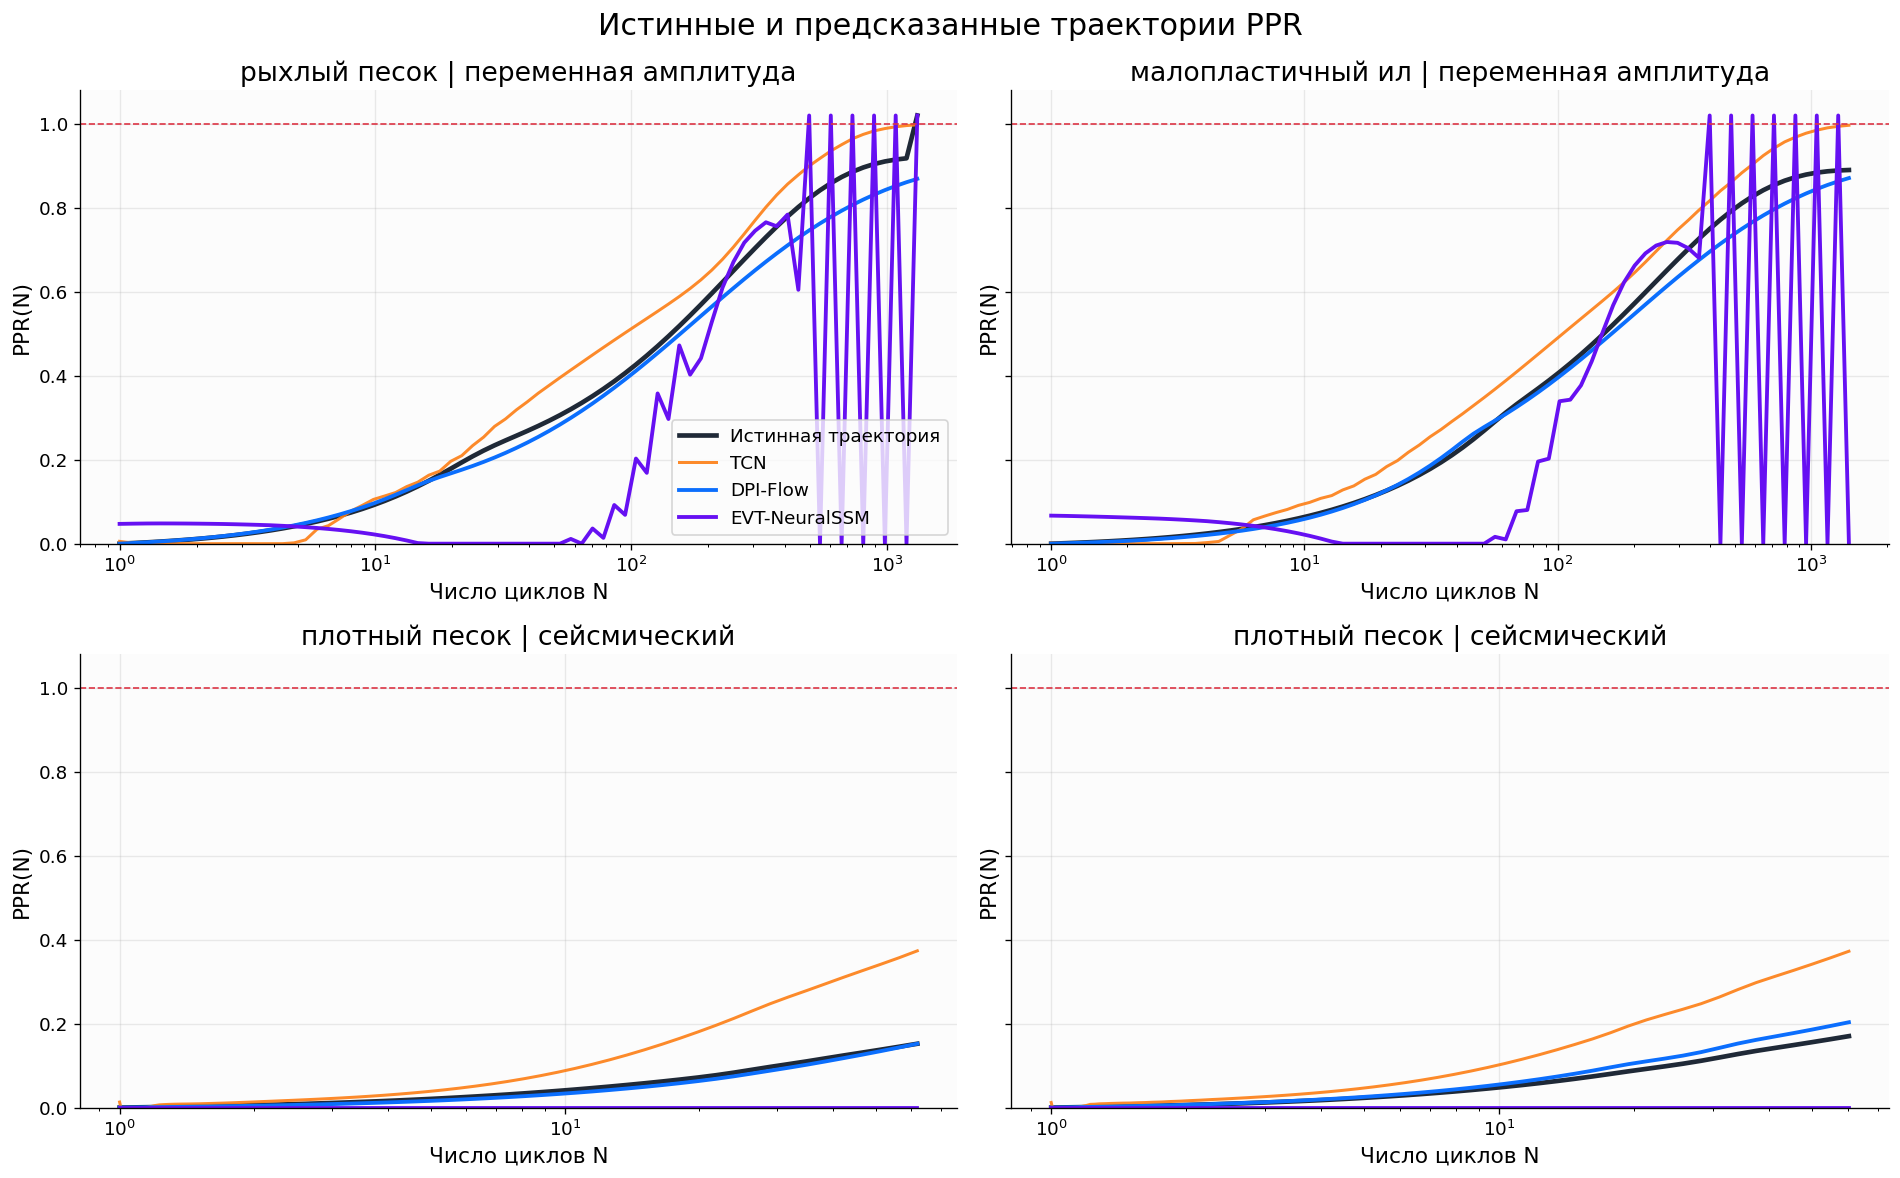

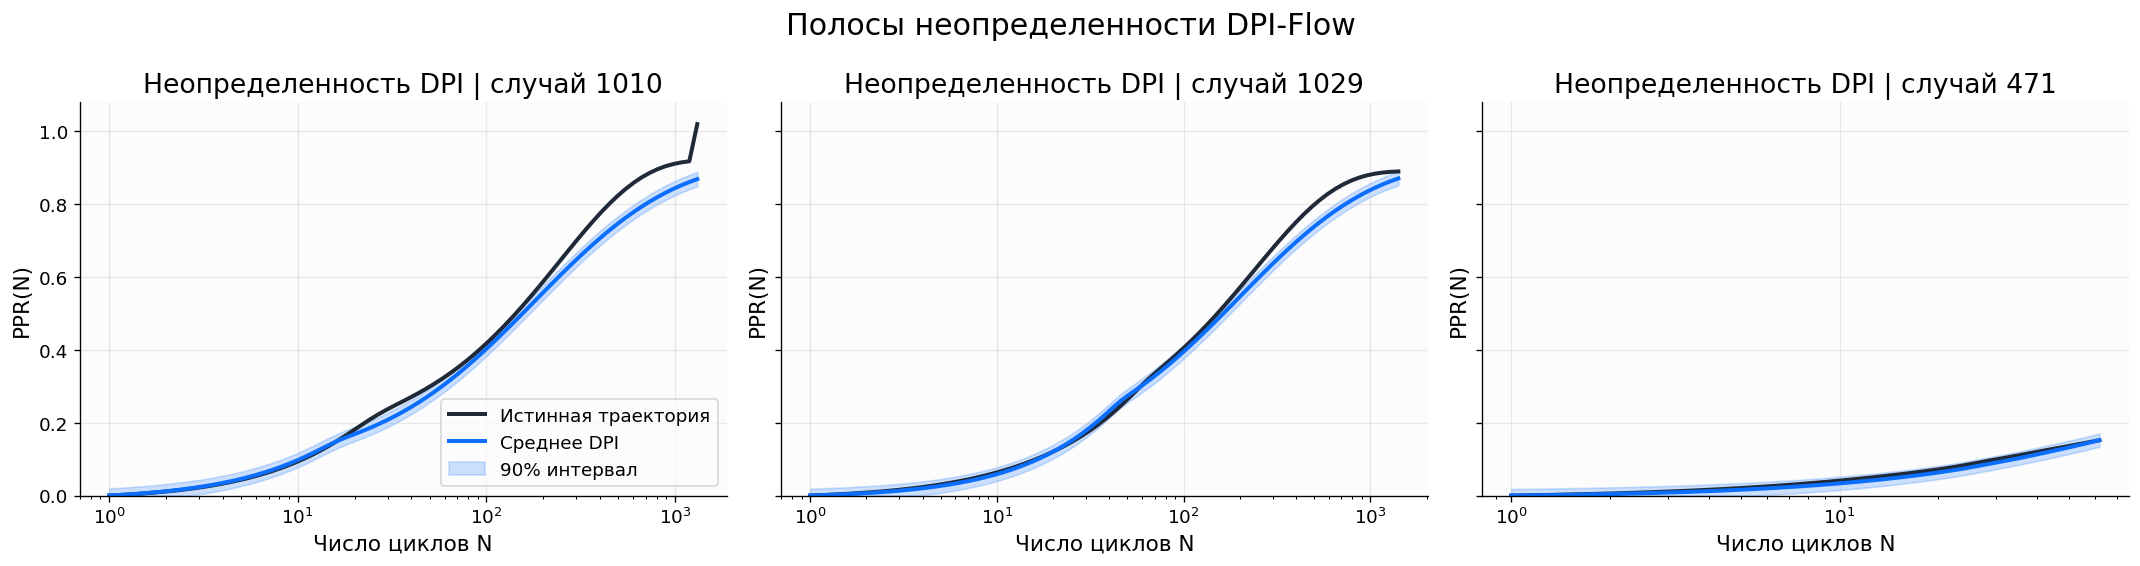

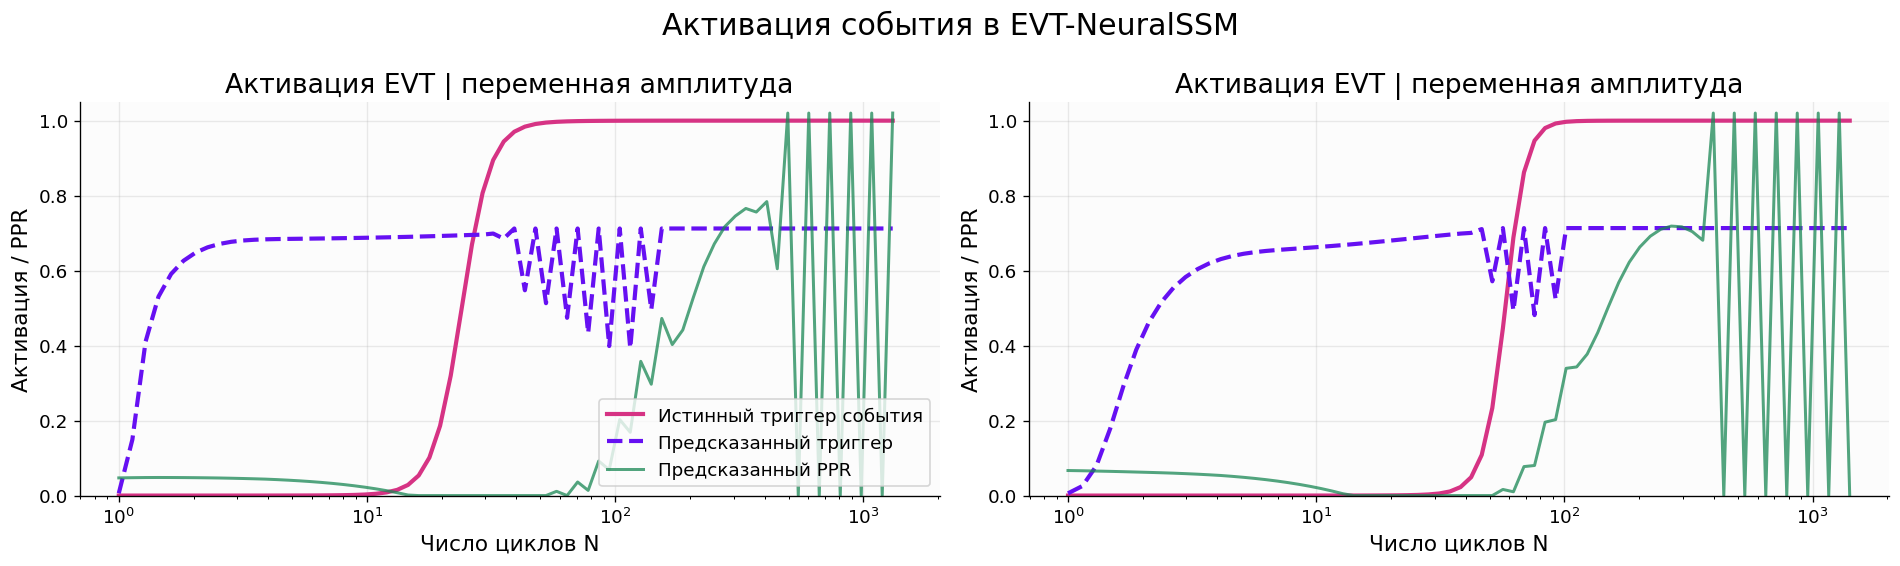

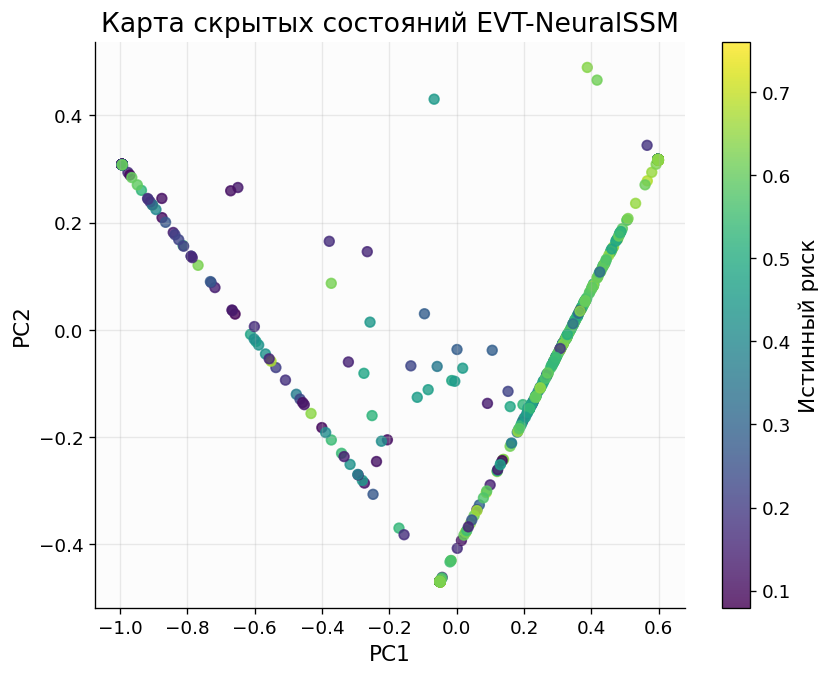

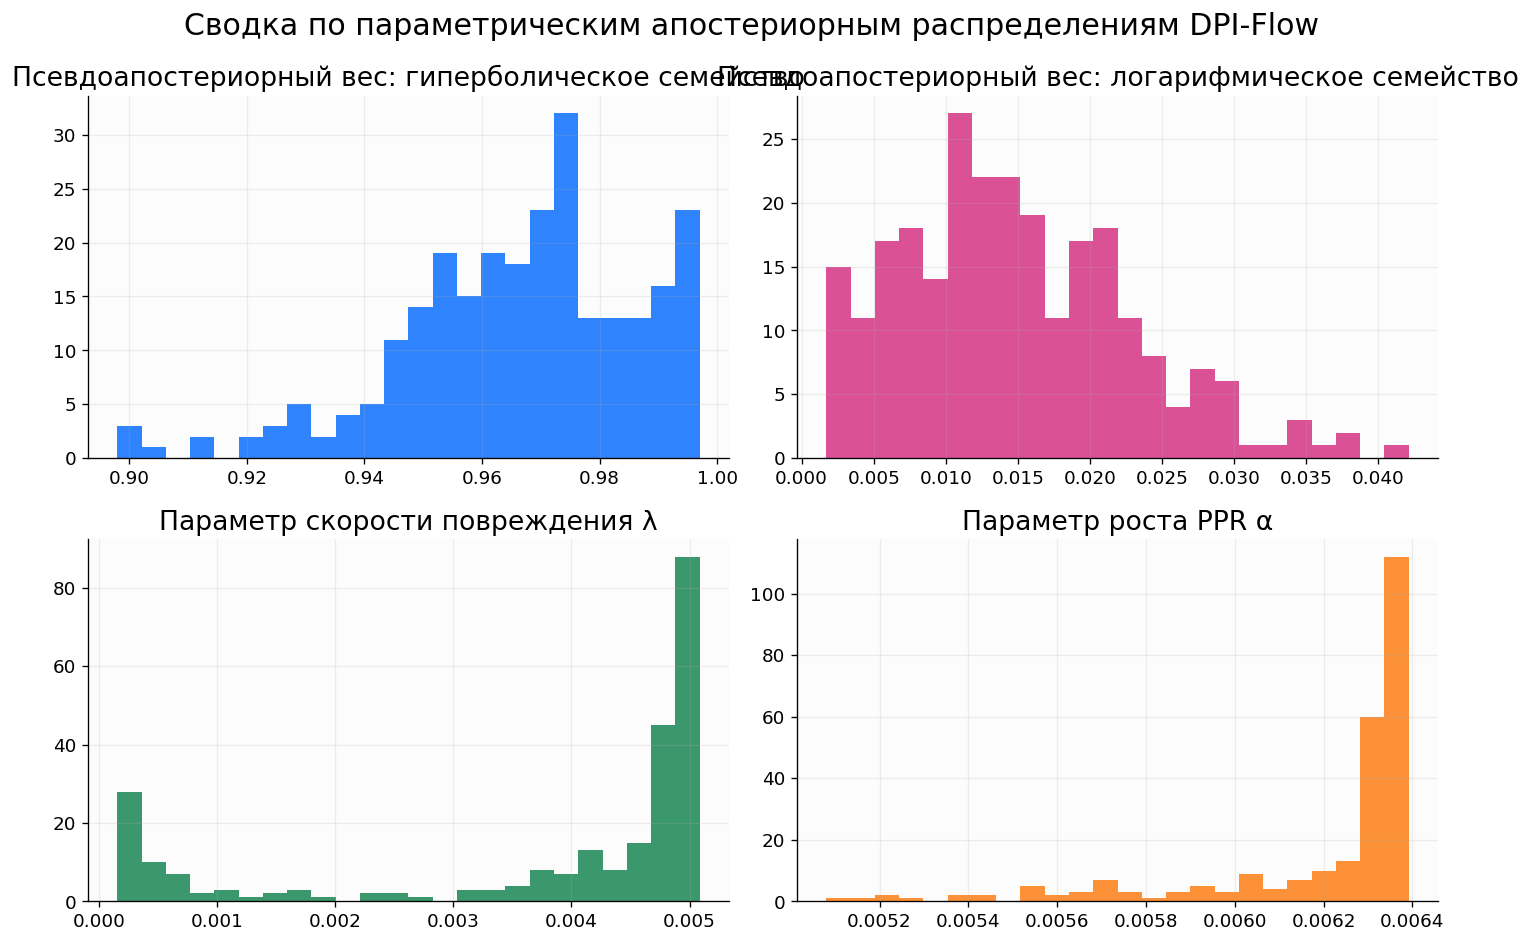

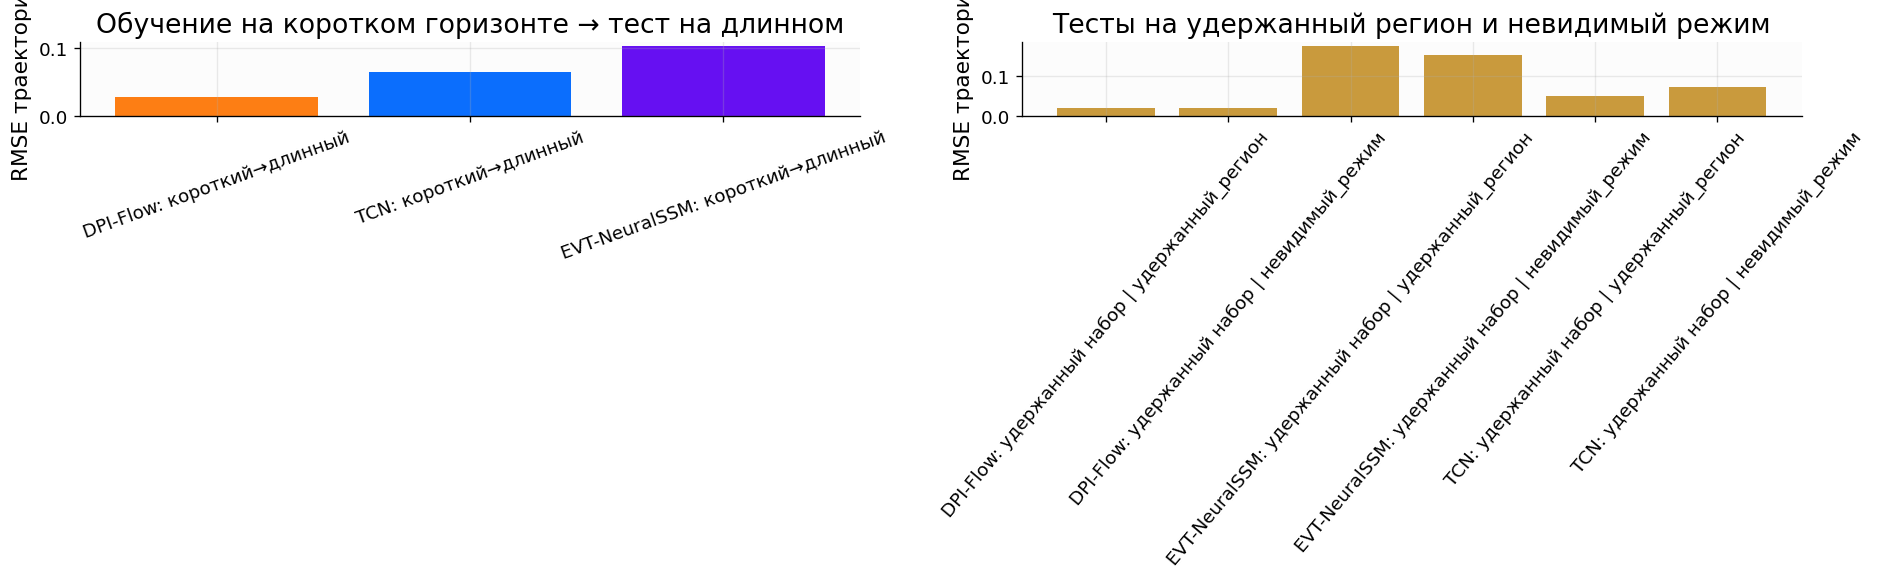

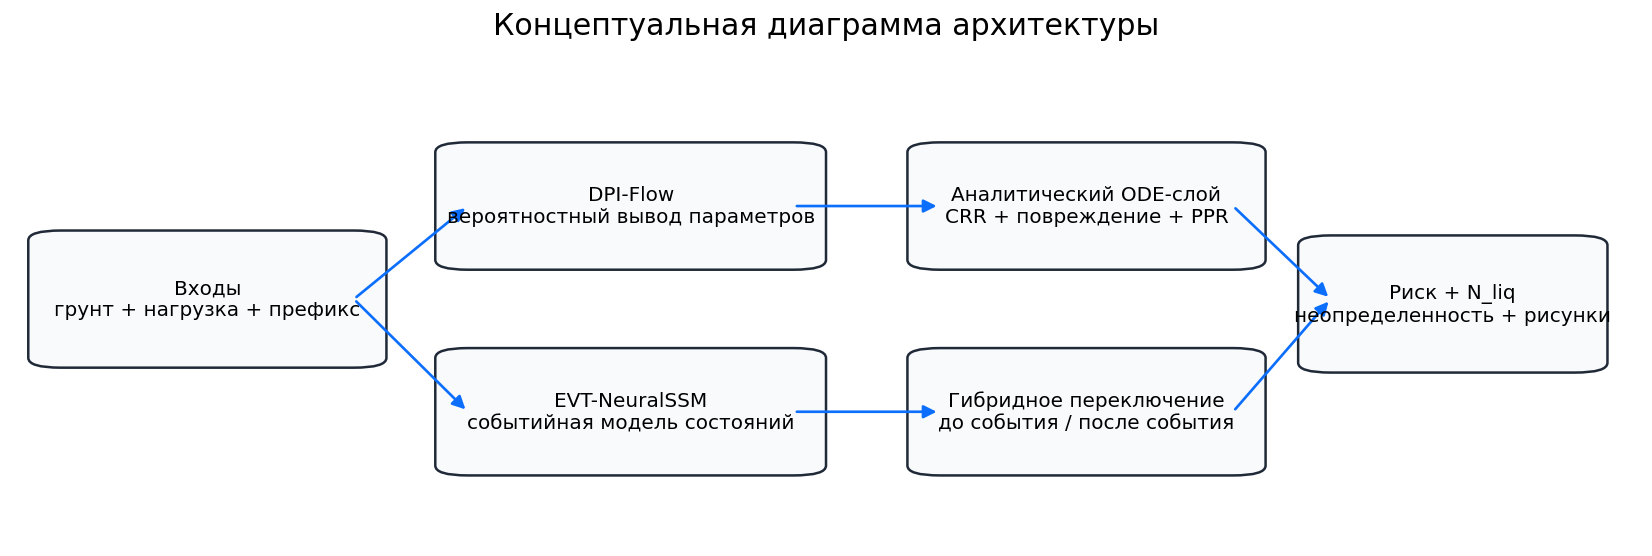

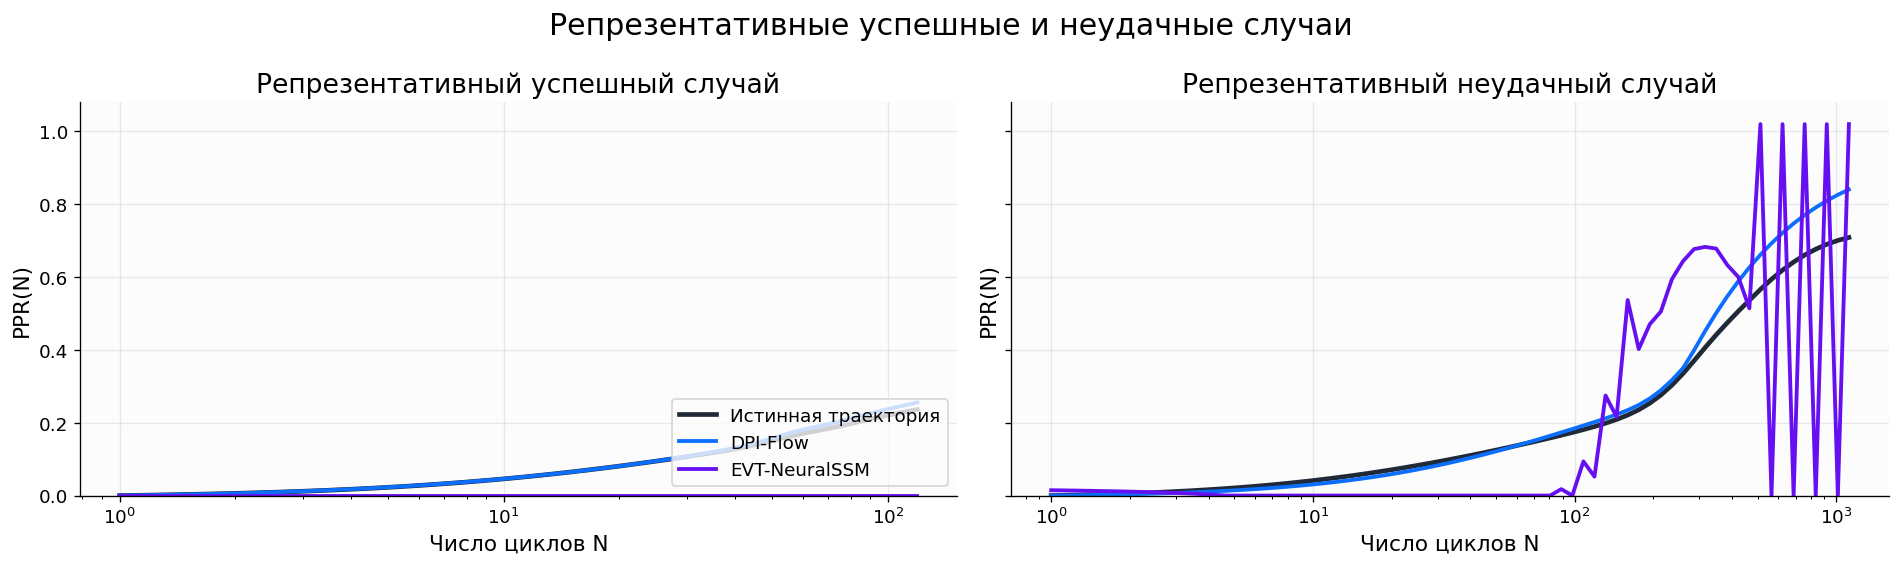

In [24]:
test_split = benchmark_data["test"]
test_meta = test_split["meta"].copy().reset_index(drop=True)
test_meta["dpi_rmse"] = main_sample_tables["DPI-Flow"]["traj_rmse"].values
test_meta["evt_rmse"] = main_sample_tables["EVT-NeuralSSM"]["traj_rmse"].values

selected_cases: List[int] = []
for idx in test_meta[test_meta["liq_label"] == 1].sort_values("risk_score_true", ascending=False).head(2).index.tolist():
    if idx not in selected_cases:
        selected_cases.append(idx)
for idx in test_meta[test_meta["liq_label"] == 0].sort_values("risk_score_true", ascending=True).head(2).index.tolist():
    if idx not in selected_cases:
        selected_cases.append(idx)
for idx in test_meta.sort_values("dpi_rmse", ascending=False).head(2).index.tolist():
    if idx not in selected_cases:
        selected_cases.append(idx)
selected_cases = selected_cases[:4]

cycles_test = test_split["cycles"].cpu().numpy()
r_true_test = test_split["r_true"].cpu().numpy()
g_true_test = test_split["g_true"].cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
for ax, idx in zip(axes.ravel(), selected_cases):
    ax.plot(cycles_test[idx], r_true_test[idx], color=PALETTE["dark"], lw=2.8, label="Истинная траектория")
    ax.plot(cycles_test[idx], main_predictions["TCN"]["traj_mean"][idx], color=PALETTE["warning"], lw=1.8, alpha=0.9, label="TCN")
    ax.plot(cycles_test[idx], main_predictions["DPI-Flow"]["traj_mean"][idx], color=PALETTE["primary"], lw=2.3, label="DPI-Flow")
    ax.plot(cycles_test[idx], main_predictions["EVT-NeuralSSM"]["traj_mean"][idx], color=PALETTE["secondary"], lw=2.3, label="EVT-NeuralSSM")
    ax.axhline(1.0, color=PALETTE["danger"], ls="--", lw=1.0)
    ax.set_xscale("log")
    ax.set_title(f"{SOIL_DISPLAY_NAMES.get(test_meta.loc[idx, 'soil_type'], test_meta.loc[idx, 'soil_type'])} | {LOAD_DISPLAY_NAMES.get(test_meta.loc[idx, 'load_mode'], test_meta.loc[idx, 'load_mode'])}")
    ax.set_xlabel("Число циклов N")
    ax.set_ylabel("PPR(N)")
    ax.set_ylim(0.0, 1.08)
axes[0, 0].legend(loc="lower right")
fig.suptitle("Истинные и предсказанные траектории PPR", fontsize=18)
fig.tight_layout()
conference_figures["true_vs_predicted_ppr"] = fig
maybe_save_figure(fig, "true_vs_predicted_ppr")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
for ax, idx in zip(axes, selected_cases[:3]):
    mean = main_predictions["DPI-Flow"]["traj_mean"][idx]
    std = np.sqrt(np.exp(main_predictions["DPI-Flow"]["traj_logvar"][idx]))
    lower = np.clip(mean - 1.64 * std, 0.0, 1.05)
    upper = np.clip(mean + 1.64 * std, 0.0, 1.05)
    ax.plot(cycles_test[idx], r_true_test[idx], color=PALETTE["dark"], lw=2.4, label="Истинная траектория")
    ax.plot(cycles_test[idx], mean, color=PALETTE["primary"], lw=2.4, label="Среднее DPI")
    ax.fill_between(cycles_test[idx], lower, upper, color=PALETTE["primary"], alpha=0.20, label="90% интервал")
    ax.set_xscale("log")
    ax.set_title(f"Неопределенность DPI | случай {idx}")
    ax.set_xlabel("Число циклов N")
    ax.set_ylabel("PPR(N)")
    ax.set_ylim(0.0, 1.08)
axes[0].legend(loc="lower right")
fig.suptitle("Полосы неопределенности DPI-Flow", fontsize=18)
fig.tight_layout()
conference_figures["dpi_uncertainty_bands"] = fig
maybe_save_figure(fig, "dpi_uncertainty_bands")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharex=True)
for ax, idx in zip(axes, selected_cases[:2]):
    ax.plot(cycles_test[idx], g_true_test[idx], color=PALETTE["accent"], lw=2.5, label="Истинный триггер события")
    ax.plot(cycles_test[idx], main_predictions["EVT-NeuralSSM"]["g"][idx], color=PALETTE["secondary"], lw=2.5, ls="--", label="Предсказанный триггер")
    ax.plot(cycles_test[idx], main_predictions["EVT-NeuralSSM"]["traj_mean"][idx], color=PALETTE["success"], lw=1.8, alpha=0.75, label="Предсказанный PPR")
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.05)
    ax.set_title(f"Активация EVT | {LOAD_DISPLAY_NAMES.get(test_meta.loc[idx, 'load_mode'], test_meta.loc[idx, 'load_mode'])}")
    ax.set_xlabel("Число циклов N")
    ax.set_ylabel("Активация / PPR")
axes[0].legend(loc="lower right")
fig.suptitle("Активация события в EVT-NeuralSSM", fontsize=18)
fig.tight_layout()
conference_figures["evt_event_activation"] = fig
maybe_save_figure(fig, "evt_event_activation")
plt.show()

state_features = np.column_stack(
    [
        main_predictions["EVT-NeuralSSM"]["z"][:, -1],
        main_predictions["EVT-NeuralSSM"]["traj_mean"][:, -1],
        main_predictions["EVT-NeuralSSM"]["c"][:, -1],
        main_predictions["EVT-NeuralSSM"]["g"][:, -1],
    ]
)
state_map = PCA(n_components=2, random_state=CONFIG.seed).fit_transform(state_features)
fig, ax = plt.subplots(figsize=(7.2, 5.8))
scatter = ax.scatter(state_map[:, 0], state_map[:, 1], c=test_meta["risk_score_true"], cmap="viridis", s=34, alpha=0.80)
ax.set_title("Карта скрытых состояний EVT-NeuralSSM")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
fig.colorbar(scatter, ax=ax, label="Истинный риск" )
fig.tight_layout()
conference_figures["latent_state_map"] = fig
maybe_save_figure(fig, "latent_state_map")
plt.show()

with torch.no_grad():
    detail_batch = next(iterate_minibatches(test_split, batch_size=256, shuffle=False))
    dpi_detail_outputs = dpi_models["DPI-Flow"].forward_batch(detail_batch)
    theta_params = {key: value.detach().cpu().numpy() for key, value in dpi_detail_outputs["theta_params"].items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(theta_params["weights"][:, 0], bins=24, color=PALETTE["primary"], alpha=0.85)
axes[0, 0].set_title("Псевдоапостериорный вес: гиперболическое семейство")
axes[0, 1].hist(theta_params["weights"][:, 3], bins=24, color=PALETTE["accent"], alpha=0.85)
axes[0, 1].set_title("Псевдоапостериорный вес: логарифмическое семейство")
axes[1, 0].hist(theta_params["lambda_damage"], bins=24, color=PALETTE["success"], alpha=0.85)
axes[1, 0].set_title("Параметр скорости повреждения λ")
axes[1, 1].hist(theta_params["alpha"], bins=24, color=PALETTE["warning"], alpha=0.85)
axes[1, 1].set_title("Параметр роста PPR α")
for ax in axes.ravel():
    ax.grid(True, alpha=0.20)
fig.suptitle("Сводка по параметрическим апостериорным распределениям DPI-Flow", fontsize=18)
fig.tight_layout()
conference_figures["dpi_parameter_posteriors"] = fig
maybe_save_figure(fig, "dpi_parameter_posteriors")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
short_long_plot = localize_model_names_in_df(short_long_df.sort_values("Traj_RMSE"))
axes[0].bar(short_long_plot["model"], short_long_plot["Traj_RMSE"], color=[PALETTE["warning"], PALETTE["primary"], PALETTE["secondary"]])
axes[0].set_title("Обучение на коротком горизонте → тест на длинном")
axes[0].set_ylabel("RMSE траектории")
axes[0].tick_params(axis="x", rotation=20)

holdout_plot = localize_model_names_in_df(holdout_df.copy())
axes[1].bar(holdout_plot["model"], holdout_plot["Traj_RMSE"], color=PALETTE["sand"])
axes[1].set_title("Тесты на удержанный регион и невидимый режим")
axes[1].set_ylabel("RMSE траектории")
axes[1].tick_params(axis="x", rotation=50)
fig.tight_layout()
conference_figures["extrapolation_and_holdout"] = fig
maybe_save_figure(fig, "extrapolation_and_holdout")
plt.show()

fig, ax = plt.subplots(figsize=(14, 4.8))
ax.axis("off")
boxes = [
    (0.03, 0.38, 0.18, 0.24, "Входы\nгрунт + нагрузка + префикс"),
    (0.28, 0.58, 0.20, 0.22, "DPI-Flow\nвероятностный вывод параметров"),
    (0.28, 0.16, 0.20, 0.22, "EVT-NeuralSSM\nсобытийная модель состояний"),
    (0.57, 0.58, 0.18, 0.22, "Аналитический ODE-слой\nCRR + повреждение + PPR"),
    (0.57, 0.16, 0.18, 0.22, "Гибридное переключение\nдо события / после события"),
    (0.81, 0.37, 0.15, 0.24, "Риск + N_liq\nнеопределенность + рисунки"),
]
for x, y, w, h, text in boxes:
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", fc="#f8fafc", ec=PALETTE["dark"], lw=1.5)
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=12)
arrow_specs = [
    ((0.21, 0.50), (0.28, 0.69)),
    ((0.21, 0.50), (0.28, 0.27)),
    ((0.48, 0.69), (0.57, 0.69)),
    ((0.48, 0.27), (0.57, 0.27)),
    ((0.75, 0.69), (0.81, 0.50)),
    ((0.75, 0.27), (0.81, 0.50)),
]
for start, end in arrow_specs:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=16, lw=1.6, color=PALETTE["primary"]))
ax.set_title("Концептуальная диаграмма архитектуры", fontsize=18, pad=12)
fig.tight_layout()
conference_figures["conceptual_architecture_diagram"] = fig
maybe_save_figure(fig, "conceptual_architecture_diagram")
plt.show()

best_case = int(test_meta.sort_values("dpi_rmse", ascending=True).index[0])
worst_case = int(test_meta.sort_values("dpi_rmse", ascending=False).index[0])
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True)
for ax, idx, title in zip(axes, [best_case, worst_case], ["Репрезентативный успешный случай", "Репрезентативный неудачный случай"]):
    ax.plot(cycles_test[idx], r_true_test[idx], color=PALETTE["dark"], lw=2.8, label="Истинная траектория")
    ax.plot(cycles_test[idx], main_predictions["DPI-Flow"]["traj_mean"][idx], color=PALETTE["primary"], lw=2.3, label="DPI-Flow")
    ax.plot(cycles_test[idx], main_predictions["EVT-NeuralSSM"]["traj_mean"][idx], color=PALETTE["secondary"], lw=2.3, label="EVT-NeuralSSM")
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("Число циклов N")
    ax.set_ylabel("PPR(N)")
    ax.set_ylim(0.0, 1.08)
axes[0].legend(loc="lower right")
fig.suptitle("Репрезентативные успешные и неудачные случаи", fontsize=18)
fig.tight_layout()
conference_figures["success_and_failure_cases"] = fig
maybe_save_figure(fig, "success_and_failure_cases")
plt.show()

## Научная интерпретация

### Почему ODE-переформулировка усиливает научную ценность

Исходные статьи изначально были сформулированы как эмпирические или полуэмпирические законы разжижения и роста порового давления. Их переписывание в виде дифференцируемых `ODE` повышает научную ценность для машинного обучения по трем причинам:

1. уравнения становятся частью вычислительного графа, а не внешней аппроксимационной кривой post factum,
2. поведение при экстраполяции определяется интерпретируемой динамикой, а не неограниченной последовательностной экстраполяцией,
3. скрытые состояния и момент события можно выводить совместно с неопределенностью.

### Почему полезно скрытое состояние повреждения `z`

Граница разжижения и наблюдаемая траектория `PPR` связаны, но не совпадают. Скрытое состояние `z` выступает как физически осмысленный аккумулятор структурной деградации. Поэтому оно особенно полезно, когда:

- `PPR` еще ниже 1, но система уже явно движется к границе разжижения,
- два сценария имеют похожие наблюдаемые префиксы `PPR`, но разную скрытую близость к разрушению,
- модели нужно рассуждать о моменте события до того, как оно полностью проявится в наблюдениях.

### Почему `PPR` нужно моделировать отдельно от границы разжижения

Исходные документы убедительно показывают, что граница сопротивления и рост порового давления подчиняются разным семействам поведения. Одна только `CRR`-граница не может описать:

- накопление с длинным хвостом,
- постепенное насыщение,
- диссипацию или частичную стабилизацию,
- переходные эффекты, зависящие от режима нагружения, например при штормовых, сейсмических или техногенных воздействиях.

Именно поэтому в notebook `CRR_theta(N, s)` и `PPR(N)` сохраняются как раздельные, но связанные динамические объекты.

### Почему мягкий триггер — естественный механизм перехода

На практике разжижение часто интерпретируют через пороги вроде `PPR ≈ 1`, однако реальные экспериментальные переходы шумные и постепенные. Мягкий триггер

- `g(N) = sigmoid(kappa * (z(N) - z0))`

дает более реалистичное описание переходной зоны. Он сохраняет каузальность, остается дифференцируемым и дает модели явную переменную события, которую можно визуализировать и обучать по supervision.

### Почему вероятностный вывод параметров полезен

`DPI-Flow` предсказывает распределение по физическим параметрам вместо одной black-box траектории. Это дает несколько преимуществ:

- интервалы неопределенности возникают напрямую из неопределенности параметров,
- выведенные веса смеси `CRR` и скоростные параметры остаются интерпретируемыми,
- калибровка по наблюдаемому префиксу превращается в дифференцируемую идентификацию системы, а не в ad hoc подгонку кривой.

### Почему гибридные структурированные модели выигрывают у чистых black-box последовательностных моделей

Чистые последовательностные модели могут хорошо интерполировать внутри обучающего manifold, но часто испытывают трудности, когда задача требует физически осмысленной экстраполяции, корректного момента события или устойчивости к частичной наблюдаемости. Гибридные модели в этом notebook сильнее, потому что объединяют:

- гибкость data-driven подхода,
- явную физику, зависящую от числа циклов,
- событийно-зависимую динамику,
- интерпретируемые скрытые состояния,
- калиброванную неопределенность.

## Ключевые тезисы для конференционной презентации

1. Синтетический набор данных здесь не является toy-бенчмарком: в него явно встроены семейства `CRR`, накопление скрытого повреждения, рост порового давления, событийная активация, шум, выбросы и переменные горизонты.
2. Статья по потенциалу разжижения естественно переводится в скрытое `ODE` повреждения, управляемое отношением `CSR / CRR_theta`.
3. Статья по росту порового давления естественно переводится в отдельное `ODE` для `PPR` с длинным хвостом роста и членами диссипации.
4. Скрытое состояние `z(N)` является мощным мостом между эмпирическими границами разжижения и наблюдаемыми траекториями `PPR(N)`.
5. Мягкий триггер `g(N)` дает дифференцируемое и интерпретируемое представление момента активации события вместо хрупкого порогового `if`.
6. `DPI-Flow` превращает вывод физических параметров в end-to-end вероятностную задачу обучения.
7. Внутренний шаг калибровки важен потому, что позволяет модели адаптировать физические параметры по короткому наблюдаемому префиксу.
8. `EVT-NeuralSSM` особенно полезен там, где главная трудность связана с переключением режимов, а не только с неопределенностью параметров.
9. Структурированные модели дают более содержательную неопределенность, чем black-box baseline-модели, потому что неопределенность живет в интерпретируемых физических параметрах и событийной динамике.
10. Поведение на горизонте до `1500` циклов — именно та область, где physics-aware структура особенно важна, прежде всего при штормовых и переменно-амплитудных режимах нагружения.
11. Сводные benchmark-таблицы и абляции показывают, что удаление калибровки, вероятностного вывода, триггерной логики или `CRR`-основанного уравнения повреждения ухудшает качество или интерпретируемость.
12. Общий narrative состоит в том, что гибридное physics-informed последовательностное моделирование может одновременно давать и конференционные визуализации, и инженерно осмысленную интерпретируемость.

## Финальное замечание

Этот notebook спроектирован как исследовательский прототип: он достаточно силен, чтобы рассказывать цельную научную историю, достаточно легок, чтобы исполняться на обычной машине, и явно показывает, где уравнения из статей были переформулированы в `ODE`-вид для дифференцируемого вывода.